In [1]:
# Standard libraries
from math import sqrt, log
from scipy import stats

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.pyplot import table

#Linear models
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet

# Scikit-learn: Preprocessing and Feature Selection
from sklearn.preprocessing import scale, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Scikit-learn: Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc, log_loss
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Scikit-learn: Linear Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
)
import statsmodels.api as sm

# Scikit-learn: Support Vector Machines
from sklearn.svm import SVC, SVR

# Scikit-learn: Tree Models
from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor

# Scikit-learn: Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor
)

# XGBoost
from xgboost import XGBClassifier

# Scikit-learn: Neural Networks
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Data Exploration

## 1. Data and variable's types

We therefore begin exploring our data by understanding the variables and their types.

In [2]:
# Lecture des données
# Charger les données
hsd_raw=pd.read_csv("healthcare_synthetic_data.csv",sep=",",header=0)
# Vérification de la forme des données
hsd_raw.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


Our first step is to check the types of every variables to be sure it is well adapted with the data the variable represent.

In [3]:
hsd_raw.dtypes

Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

We can see that qualitative variables are treated as character strings or integers. We create two sub-lists of qualitative and quantitative variables so that we can process them separately. As we discuss in class, we take Sleep_Hours and Stress_Level as quantitative variables because our models will be lighter to run (because a quantitative variable needs only one estimator, while a qualitative variable with k modalities needs k-1 estimators). The proportion of quantitative variables will be greater than the qualitative ones and we believe that it will be worth for the accuracy of models also.

In [4]:
qualitative_var = ["Gender", "Smoking_Status", "Alcohol_Consumption", "Physical_Activity_Level", 
                   "Family_History","Heart_Disease_Risk"]

quantitative_var = ["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP", "Cholesterol_Total",
                    "Cholesterol_LDL","Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours"]

hsd = hsd_raw.copy()

for i in qualitative_var:
    hsd[i]=pd.Categorical(hsd[i])



In [5]:
hsd.dtypes


Patient_ID                      str
Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level                  int64
Sleep_Hours                   int64
Heart_Disease_Risk         category
dtype: object

In [6]:
print(f"The proportion of quantitative variables is {round(len(quantitative_var)/hsd.shape[1] *100, 2)}%.")
print(f"The proportion of qualitative variables is {round(len(qualitative_var)/hsd.shape[1] *100, 2)}%.")

The proportion of quantitative variables is 63.16%.
The proportion of qualitative variables is 31.58%.


## 2. Analyse unidimensionnelle

### 1. Qualitative variables


--- Résumé pour la variable : Gender ---
Gender
0    7622
1    7378
Name: count, dtype: int64

Pourcentages :
Gender
0    50.813333
1    49.186667
Name: proportion, dtype: float64

--- Résumé pour la variable : Smoking_Status ---
Smoking_Status
0    10495
1     4505
Name: count, dtype: int64

Pourcentages :
Smoking_Status
0    69.966667
1    30.033333
Name: proportion, dtype: float64

--- Résumé pour la variable : Alcohol_Consumption ---
Alcohol_Consumption
0    7502
1    5939
2    1559
Name: count, dtype: int64

Pourcentages :
Alcohol_Consumption
0    50.013333
1    39.593333
2    10.393333
Name: proportion, dtype: float64

--- Résumé pour la variable : Physical_Activity_Level ---
Physical_Activity_Level
0    3020
1    6009
2    4453
3    1518
Name: count, dtype: int64

Pourcentages :
Physical_Activity_Level
0    20.133333
1    40.060000
2    29.686667
3    10.120000
Name: proportion, dtype: float64

--- Résumé pour la variable : Family_History ---
Family_History
0    12757
1     224

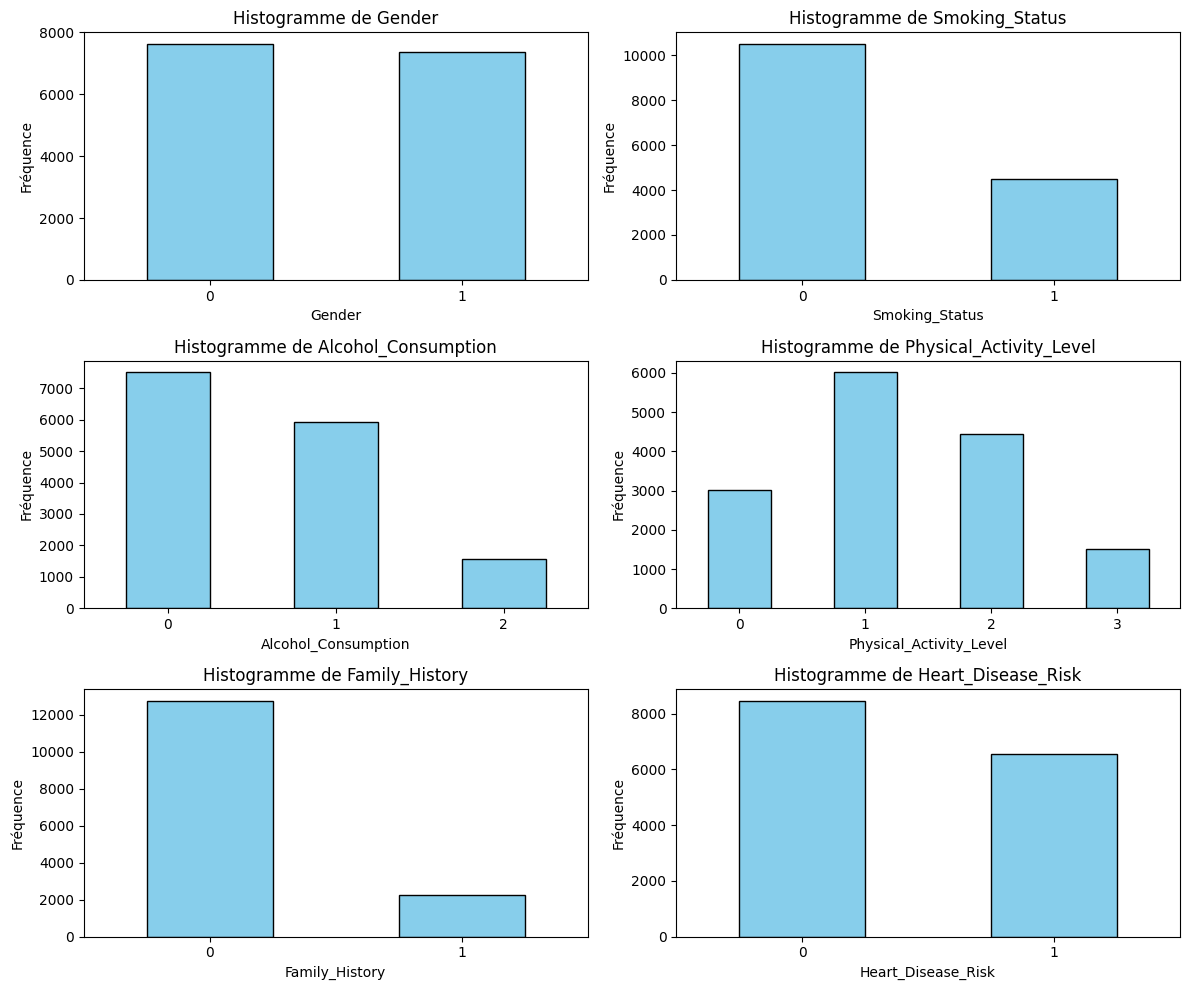

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for idx, var in enumerate(qualitative_var):
    print(f"\n--- Résumé pour la variable : {var} ---")
    print(hsd[var].value_counts(dropna=False).sort_index())
    print("\nPourcentages :")
    print(hsd[var].value_counts(dropna=False, normalize=True).sort_index() * 100)
    
    # Plot on the corresponding subplot
    hsd[var].value_counts().sort_index().plot(
        kind='bar', 
        ax=axes[idx], 
        title=f"Histogramme de {var}",
        color='skyblue',
        edgecolor='black'
    )
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("Fréquence")
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Qualitative variables seem well represented with a good repartition between individuals. We know can take attention at the quantitatives variables.

### 2. Quantitative variables

In [8]:
hsd.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


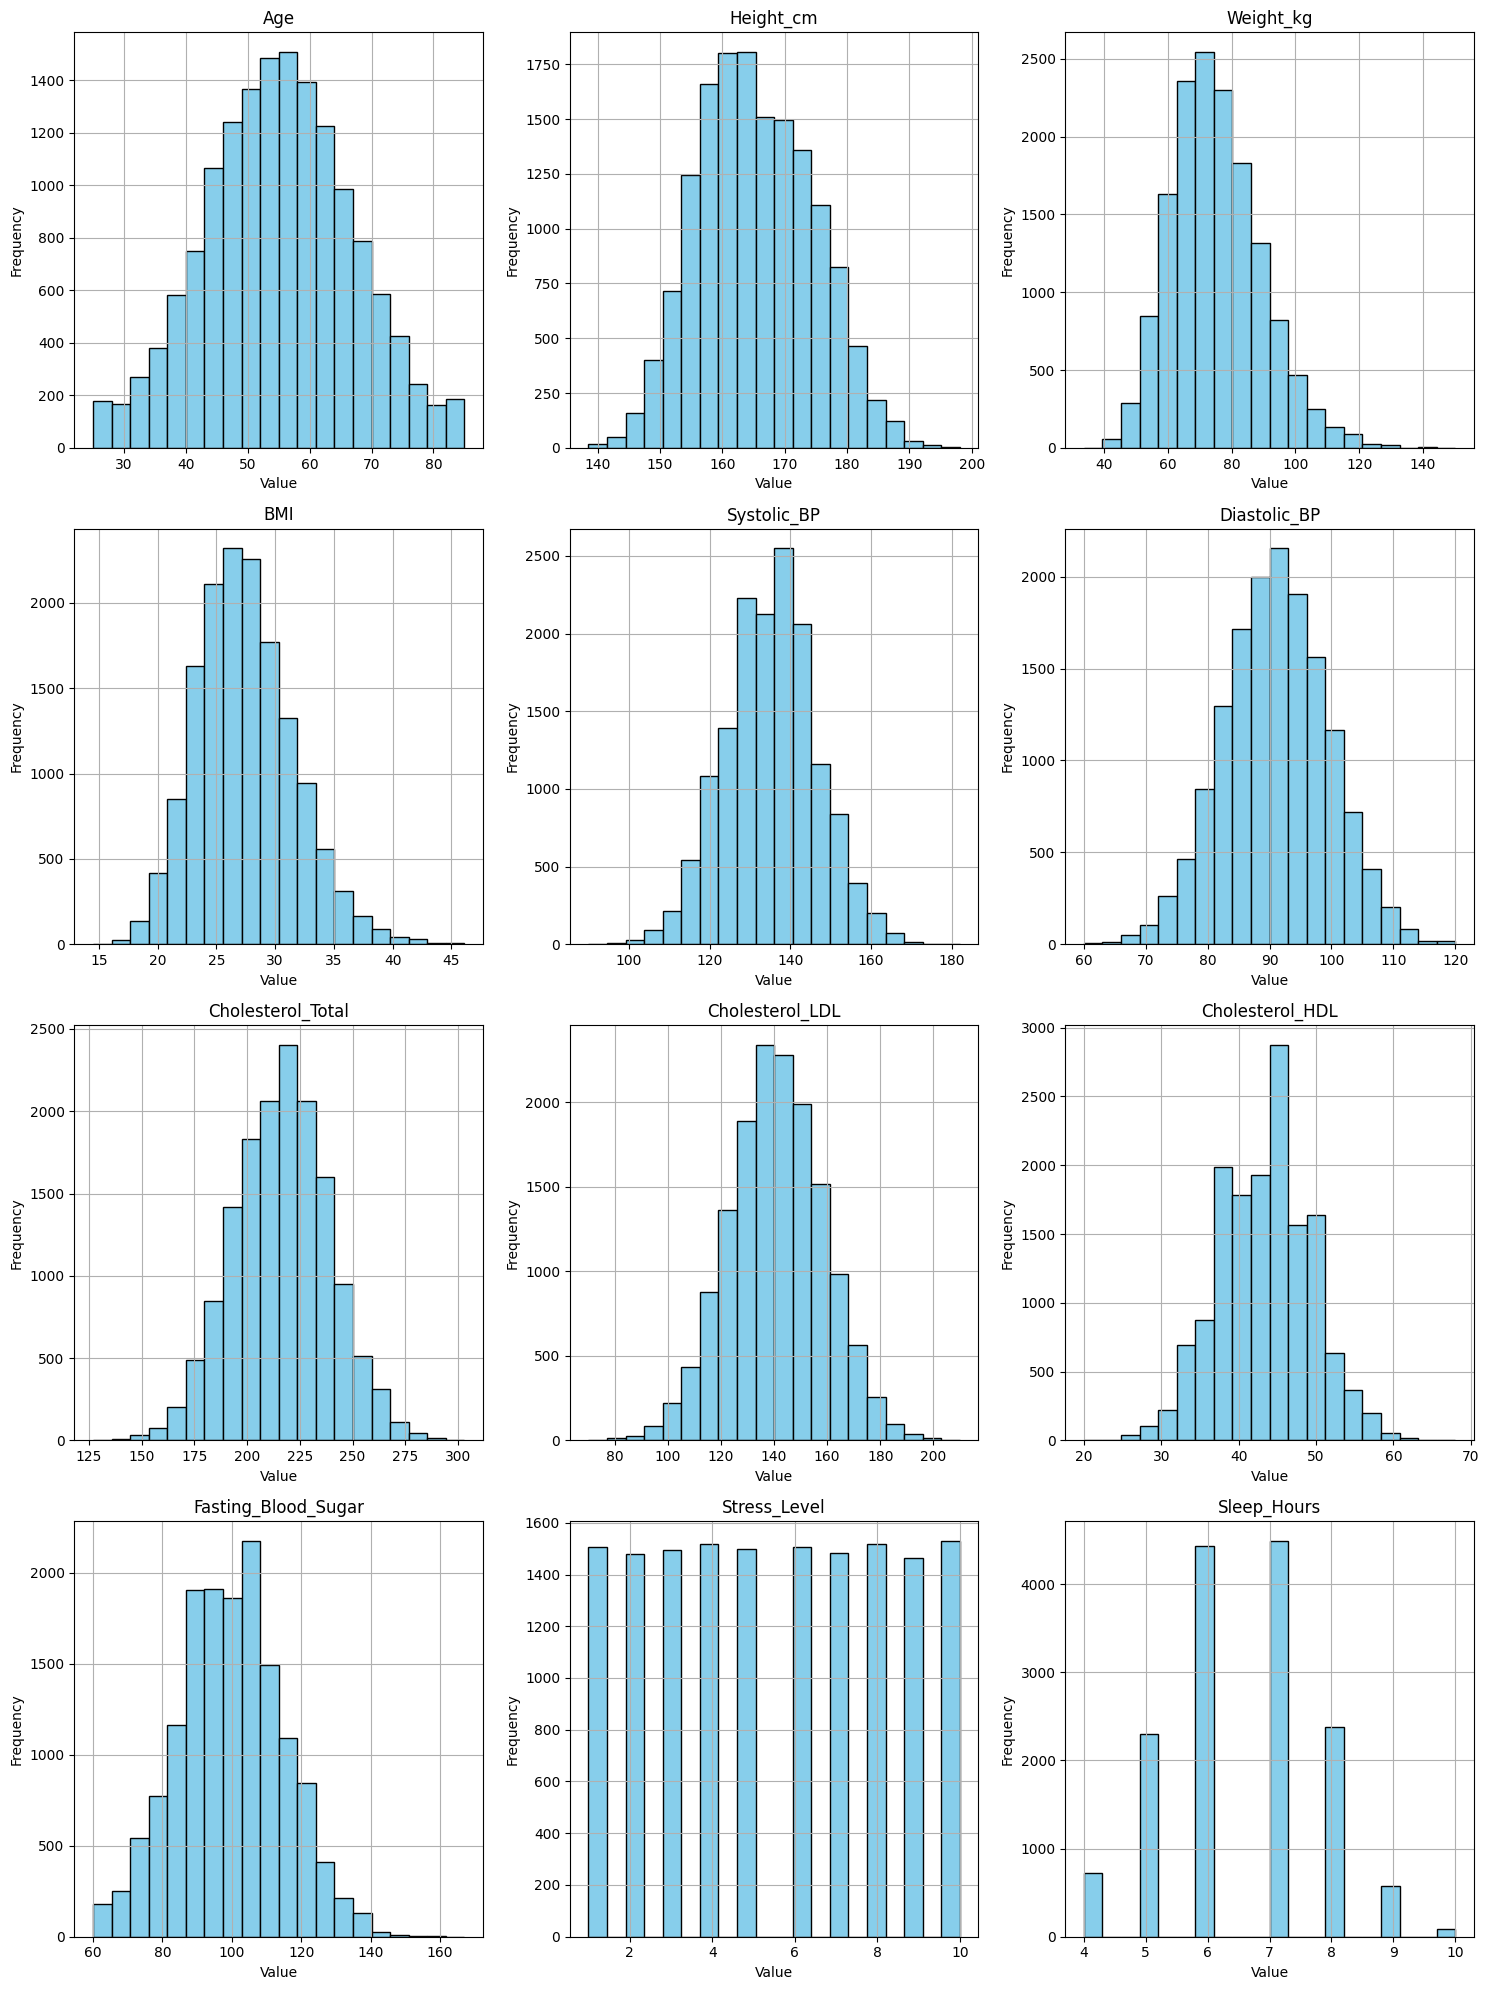

In [9]:
# histograms for quantitative variables
num_vars = len(quantitative_var)
num_cols = 3  # Number of columns in the subplot grid
num_rows = (num_vars + num_cols - 1) // num_cols  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, var in enumerate(quantitative_var):
    ax = axes[i]
    hsd[var].hist(ax=ax, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Our aim now is to have all variables Gaussian shaped. We can observe 5 variables who are not distributed as gaussian : BMI, Weight_kg, Height_cm, Fasting_Blood_Sugar and Cholesterol_HDL. Let's try 2 different transformations (sqrt and log) to see if it can improve their shape.



In [10]:
hsd["LBMI"]=hsd["BMI"].map(lambda x: log(x))
hsd["SBMI"]=hsd["BMI"].map(lambda x: sqrt(x))

hsd["LFBS"]=hsd["Fasting_Blood_Sugar"].map(lambda x: log(x))
hsd["SFBS"]=hsd["Fasting_Blood_Sugar"].map(lambda x: sqrt(x))

hsd["L_Weight_kg"]=hsd["Weight_kg"].map(lambda x: log(x))
hsd["S_Weight_kg"]=hsd["Weight_kg"].map(lambda x: sqrt(x))

hsd["L_Cholesterol_HDL"]=hsd["Cholesterol_HDL"].map(lambda x: log(x))
hsd["S_Cholesterol_HDL"]=hsd["Cholesterol_HDL"].map(lambda x: sqrt(x))

hsd["L_Height_cm"]=hsd["Height_cm"].map(lambda x: log(x))
hsd["S_Height_cm"]=hsd["Height_cm"].map(lambda x: sqrt(x))


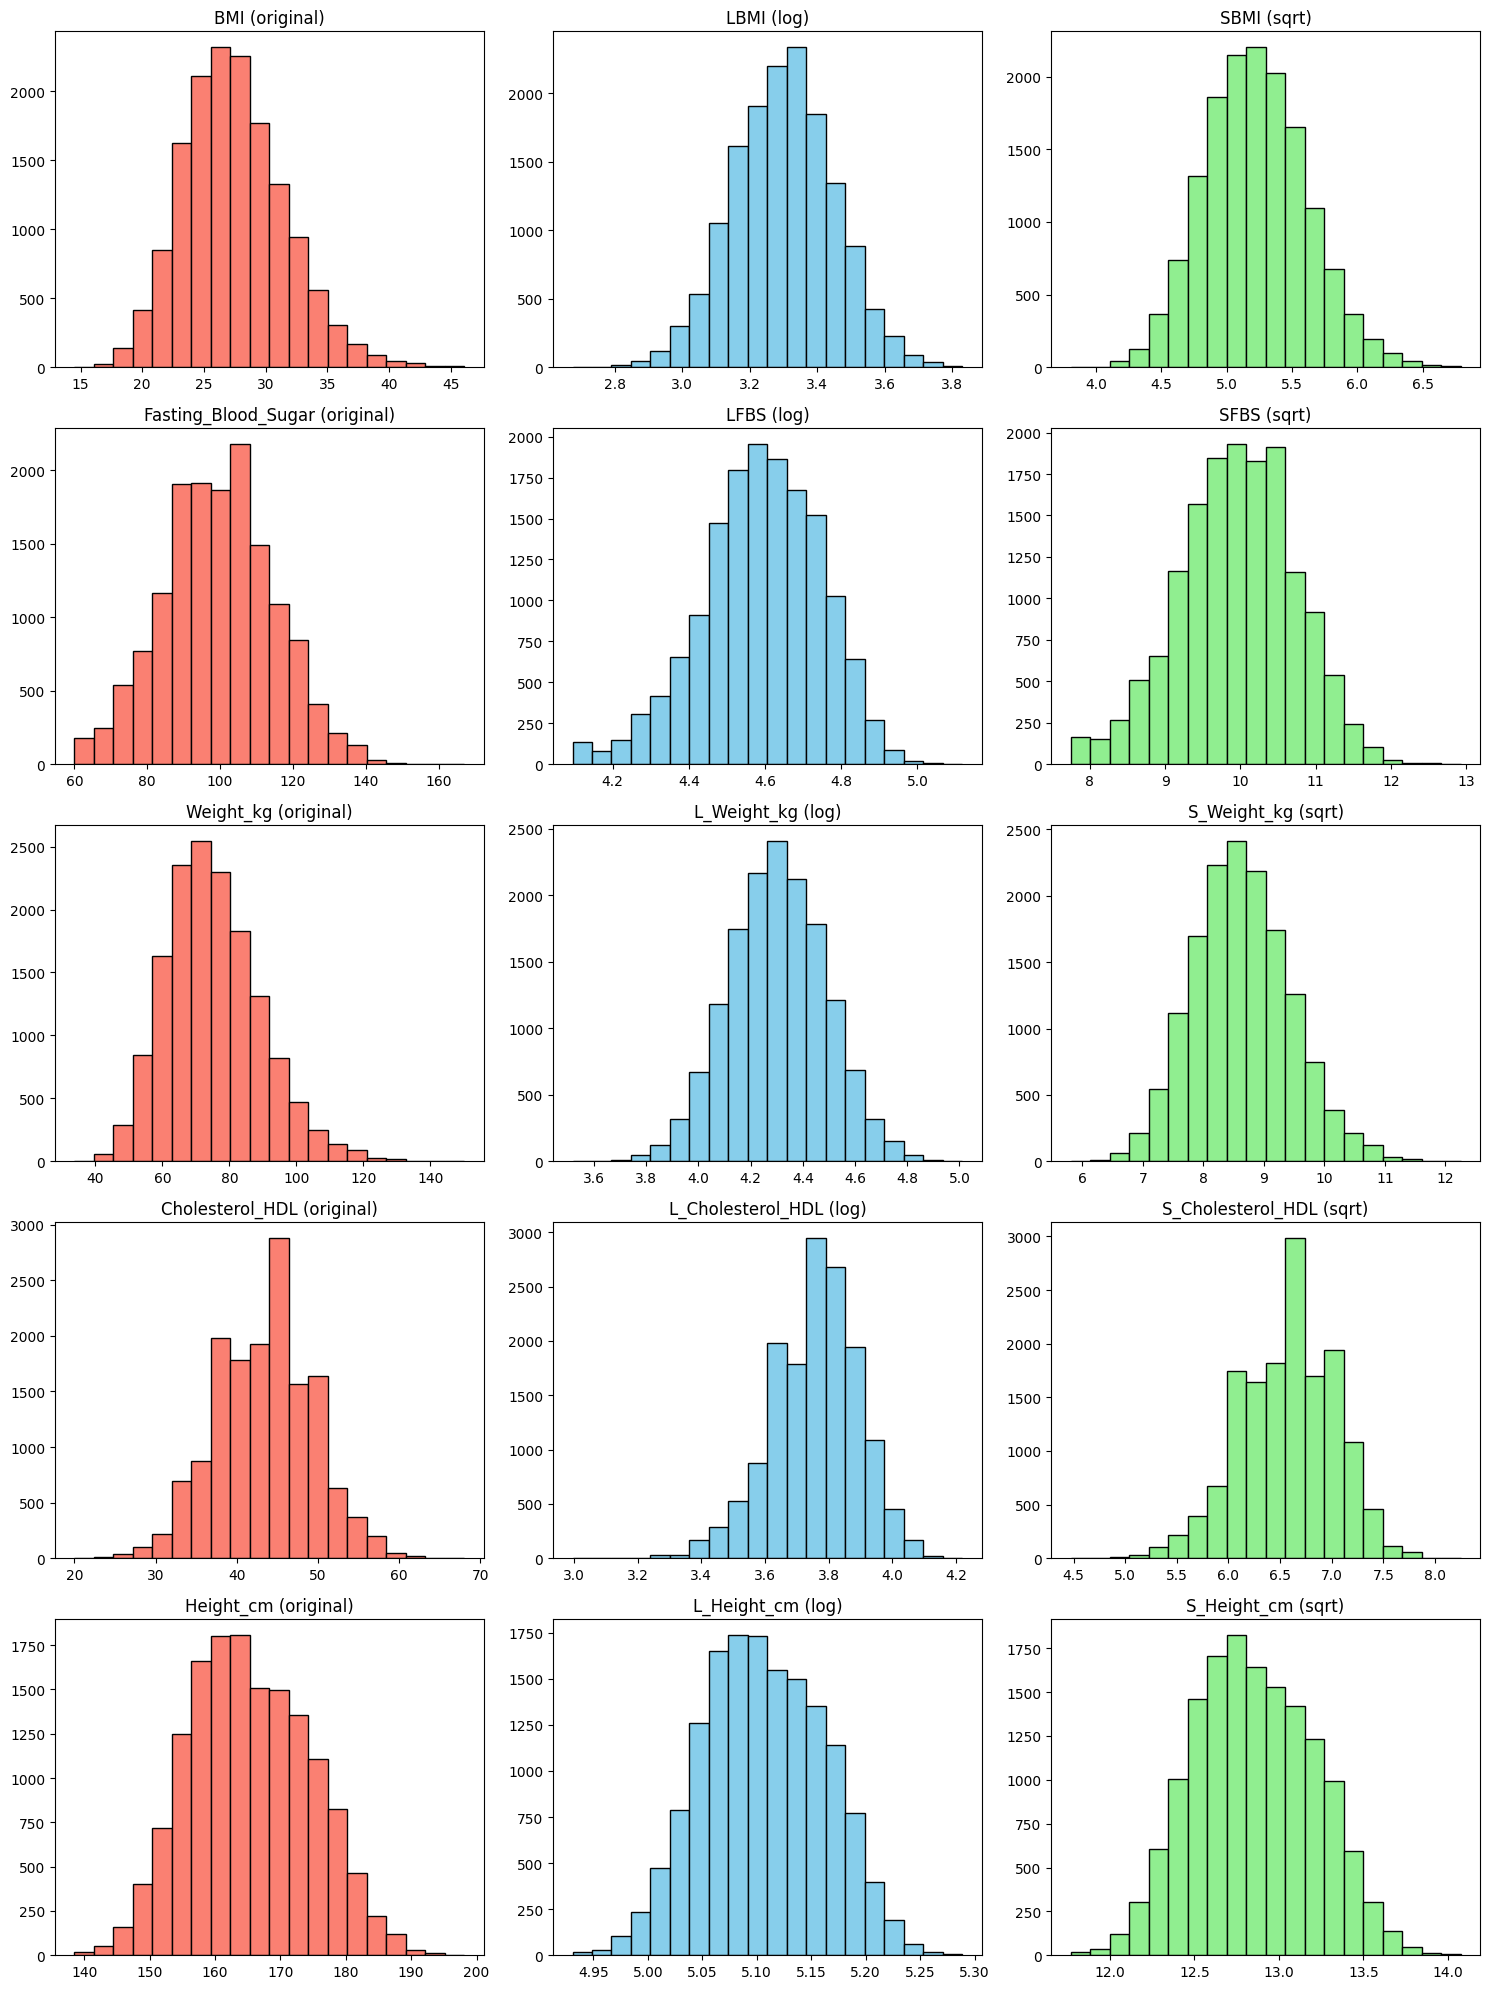

In [11]:
#comparison of original, log and sqrt histograms for selected variables
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))    
axes[0, 0].hist(hsd["BMI"], bins=20, color='salmon', edgecolor='black')
axes[0, 0].set_title("BMI (original)")
axes[0, 1].hist(hsd["LBMI"], bins=20, color='skyblue', edgecolor='black')
axes[0, 1].set_title("LBMI (log)")
axes[0, 2].hist(hsd["SBMI"], bins=20, color='lightgreen', edgecolor='black')
axes[0, 2].set_title("SBMI (sqrt)")

axes[1, 0].hist(hsd["Fasting_Blood_Sugar"], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title("Fasting_Blood_Sugar (original)")
axes[1, 1].hist(hsd["LFBS"], bins=20, color='skyblue', edgecolor='black')
axes[1, 1].set_title("LFBS (log)")
axes[1, 2].hist(hsd["SFBS"], bins=20, color='lightgreen', edgecolor='black')
axes[1, 2].set_title("SFBS (sqrt)")

axes[2, 0].hist(hsd["Weight_kg"], bins=20, color='salmon', edgecolor='black')
axes[2, 0].set_title("Weight_kg (original)")
axes[2, 1].hist(hsd["L_Weight_kg"], bins=20, color='skyblue', edgecolor='black')
axes[2, 1].set_title("L_Weight_kg (log)")
axes[2, 2].hist(hsd["S_Weight_kg"], bins=20, color='lightgreen', edgecolor='black')
axes[2, 2].set_title("S_Weight_kg (sqrt)")

axes[3, 0].hist(hsd["Cholesterol_HDL"], bins=20, color='salmon', edgecolor='black')
axes[3, 0].set_title("Cholesterol_HDL (original)")
axes[3, 1].hist(hsd["L_Cholesterol_HDL"], bins=20, color='skyblue', edgecolor='black')
axes[3, 1].set_title("L_Cholesterol_HDL (log)")
axes[3, 2].hist(hsd["S_Cholesterol_HDL"], bins=20, color='lightgreen', edgecolor='black')
axes[3, 2].set_title("S_Cholesterol_HDL (sqrt)")

axes[4,0].hist(hsd["Height_cm"], bins=20, color='salmon', edgecolor='black')
axes[4,0].set_title("Height_cm (original)")
axes[4,1].hist(hsd["L_Height_cm"], bins=20, color='skyblue', edgecolor='black')
axes[4,1].set_title("L_Height_cm (log)")
axes[4,2].hist(hsd["S_Height_cm"], bins=20, color='lightgreen', edgecolor='black')
axes[4,2].set_title("S_Height_cm (sqrt)")


plt.tight_layout()
plt.show()


We keep the log transformation for BMI, Fasting_Blood_Sugar, Weight_kg and Height_cm but not for Cholesterol_HDL since it doesn't seem to improve the distribution.

In [12]:
quantitative_var.extend(["LBMI", "LFBS", "L_Weight_kg", "L_Height_cm"])
quantitative_var.remove("BMI")
quantitative_var.remove("Fasting_Blood_Sugar")
quantitative_var.remove("Weight_kg")
quantitative_var.remove("Height_cm")

hsd.drop(columns=["SBMI", "SFBS", "S_Weight_kg", "S_Height_cm", "L_Cholesterol_HDL", "S_Cholesterol_HDL"], inplace=True)


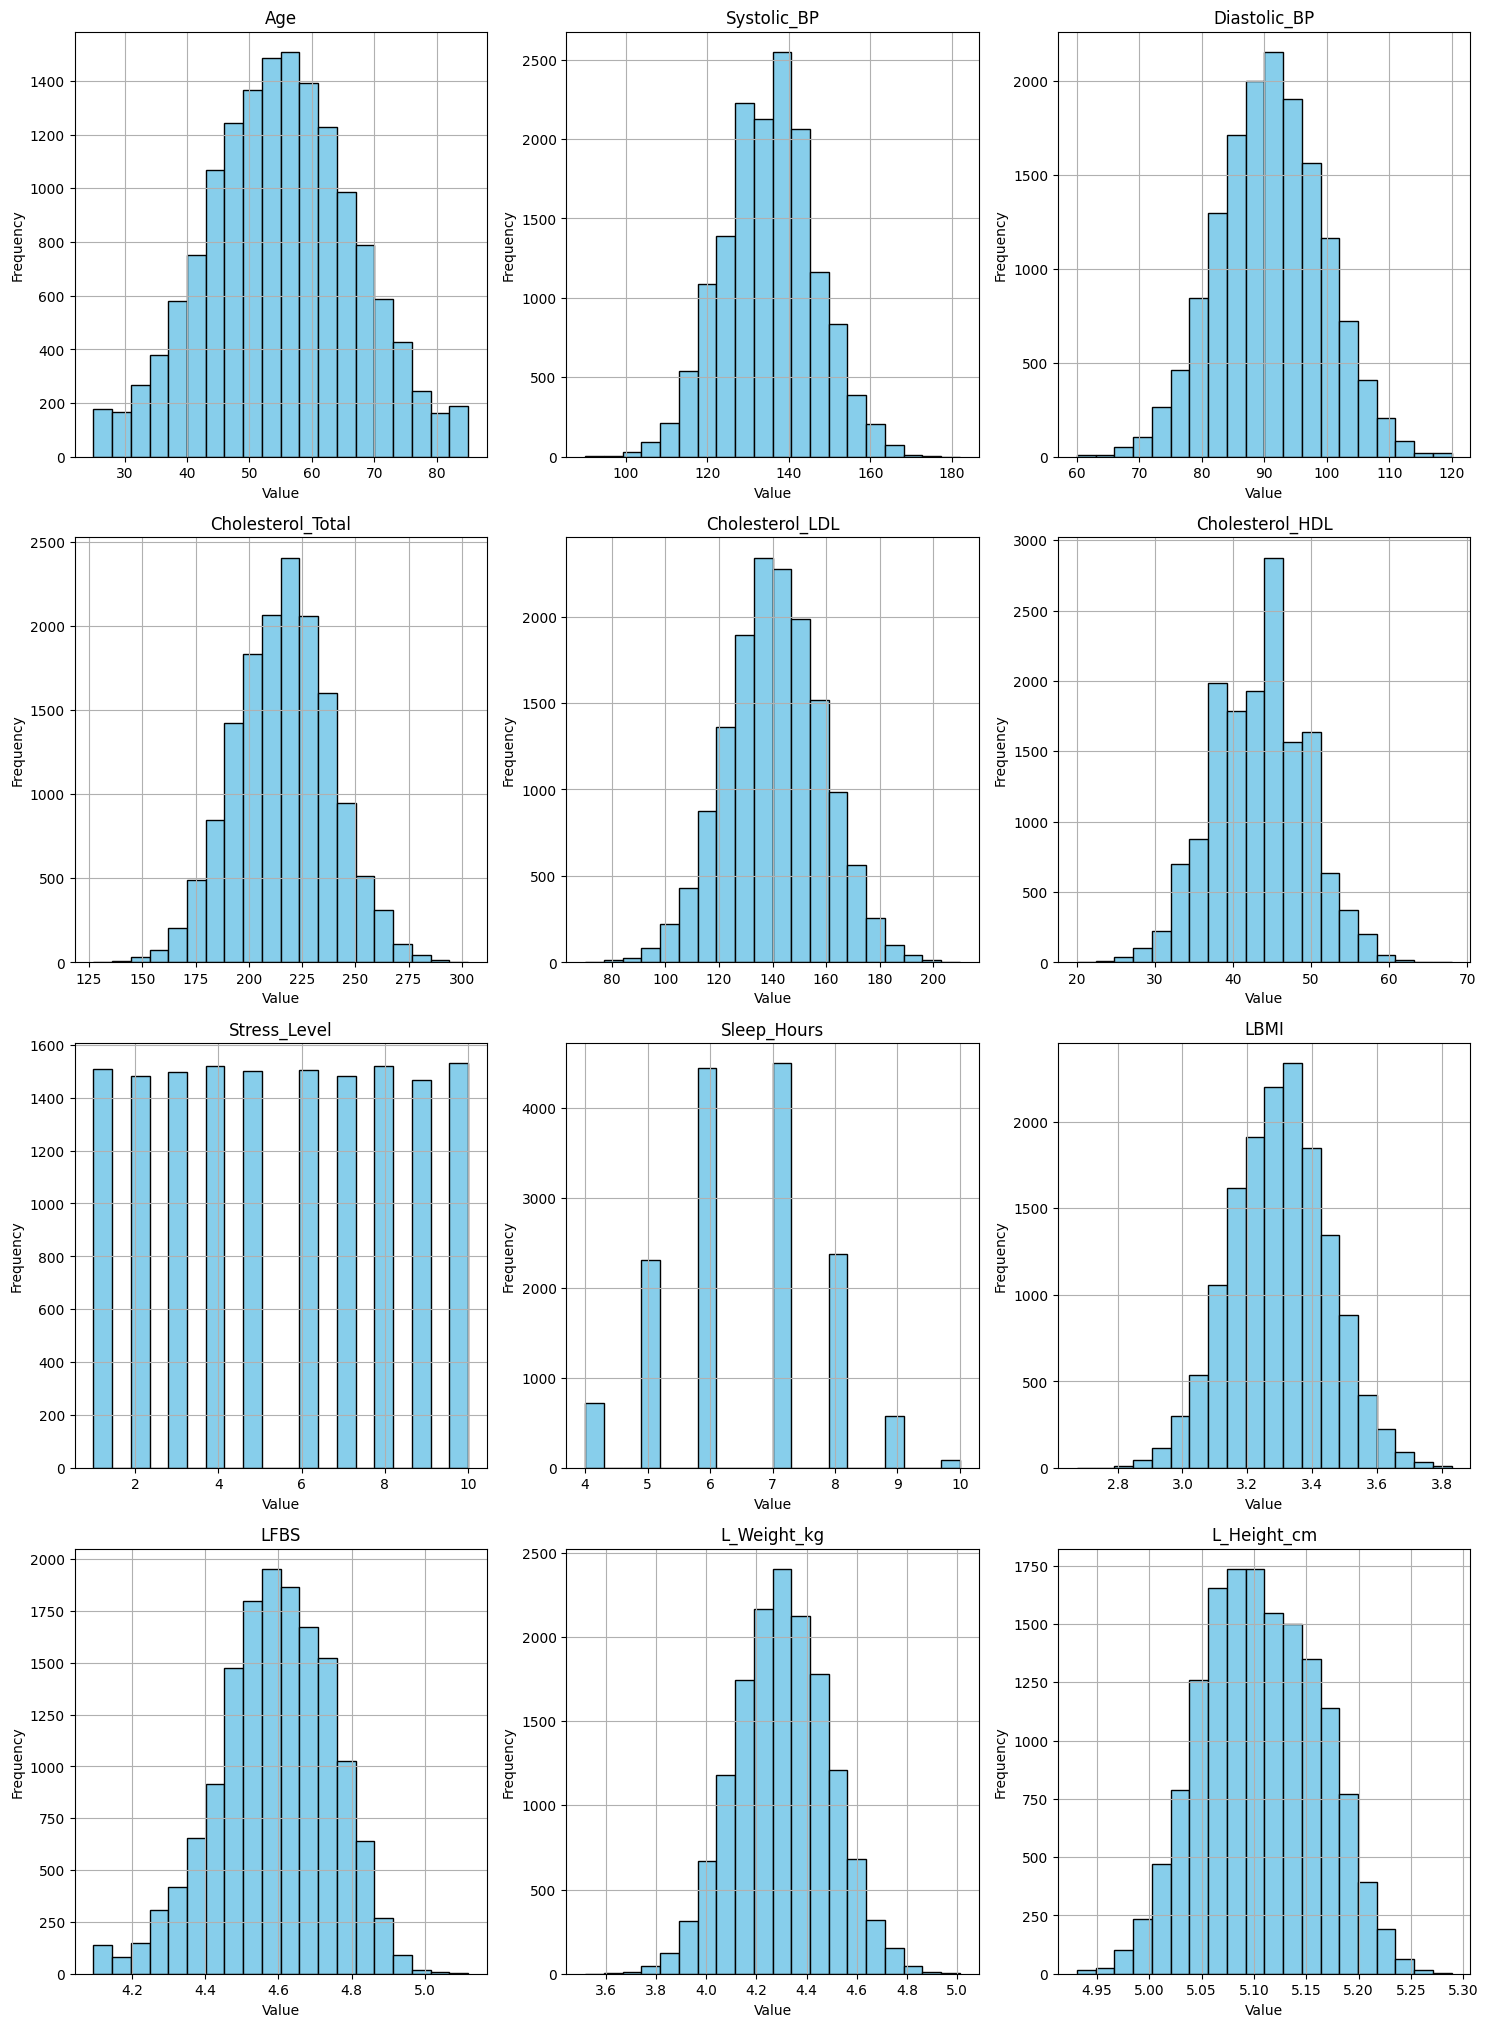

In [13]:
num_cols = 3  # Number of columns in the subplot grid
num_rows = 5  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, var in enumerate(quantitative_var):
    ax = axes[i]
    hsd[var].hist(ax=ax, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We have now better profiles for our quantitative variables.

## 3. Analyse multidimensionnelle

We are now interested by links between variables. If we find very clear linear link between 2 variables it will be interesting to check if one of variables can ben remove from a model.

['Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Stress_Level', 'Sleep_Hours', 'LBMI', 'LFBS', 'L_Weight_kg', 'L_Height_cm']


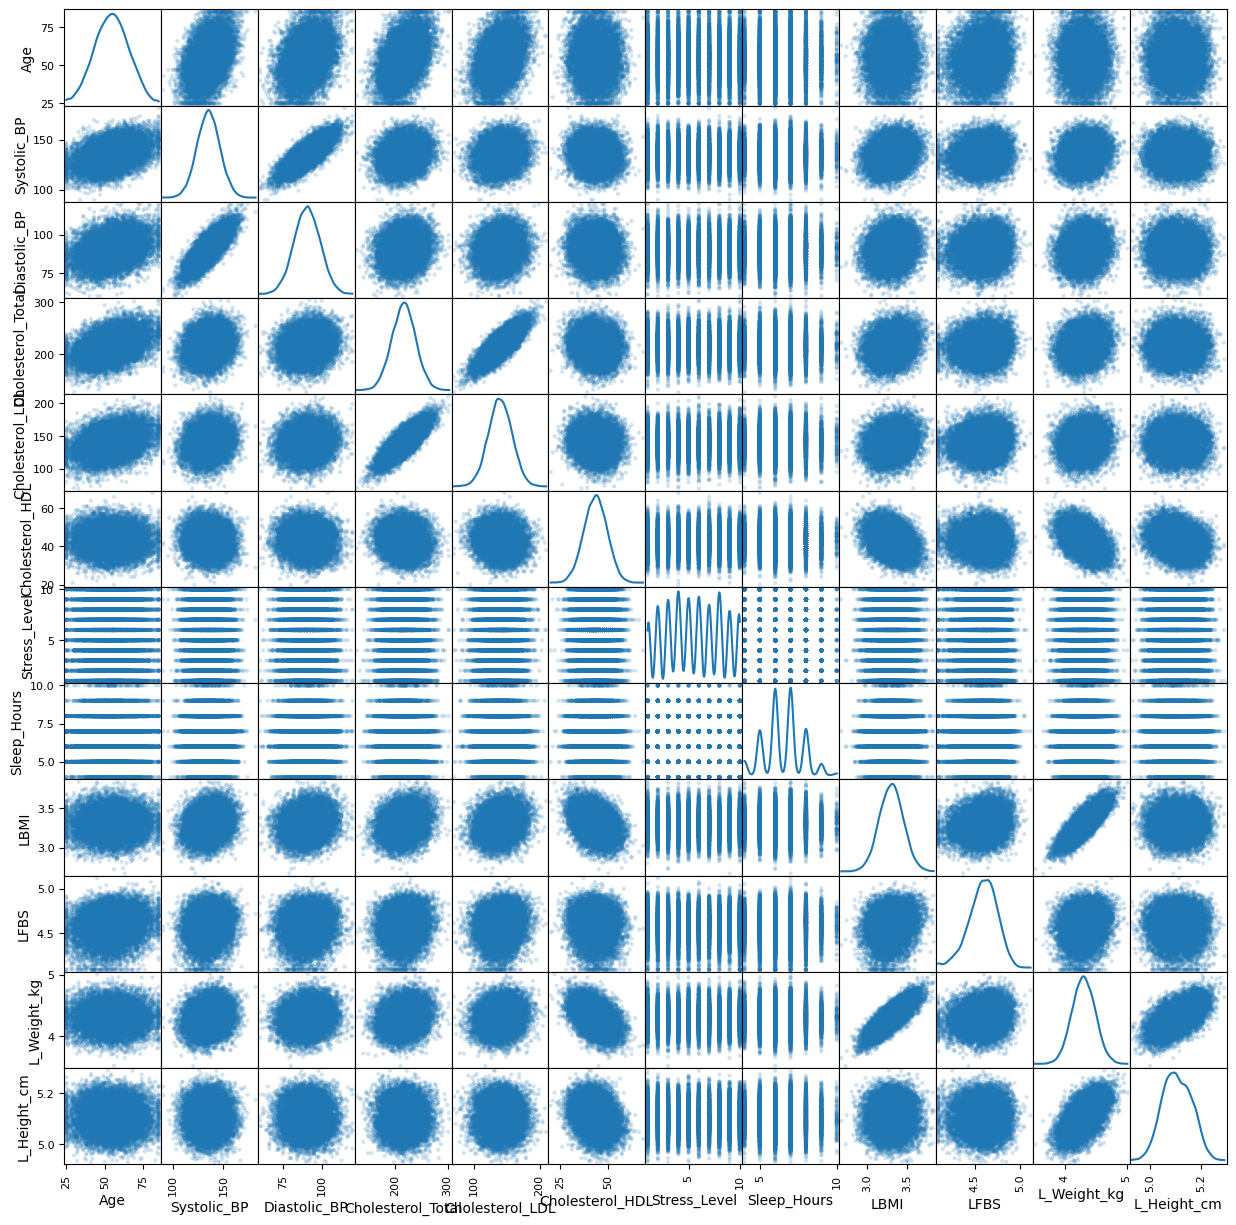

In [14]:

print(quantitative_var)
scatter_matrix(hsd[quantitative_var], alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

Point clouds give us an idea of correlations between some variables so we can compute the Correlation Matrix to have a clear vision of those linear links.

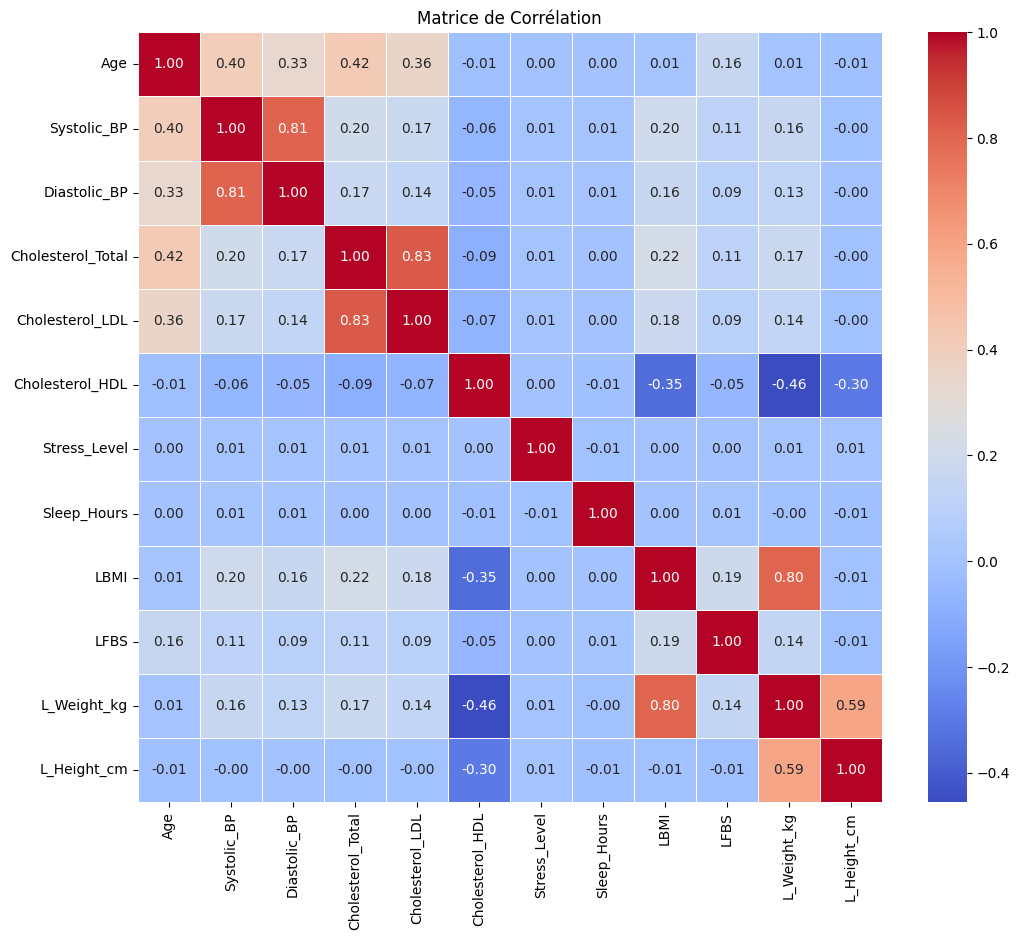

In [15]:
#matrice de correlation

corr_matrix = hsd[quantitative_var].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation")
plt.show()


We have some correlations to notice between the variables, for example:
- Cholesterol_HDL and L_Weight_kg (-0.46)
- Weight and Height at 0.59 (which seems normal)
- Cholesterol_Total and Cholesterol_LDL (0.83) so we can expect to see strong links between those variables, specially when we will try to estimate Cholesterol_HDL
- Systolic_BP and Diastolic_BP with 0.81, also we can expect a relation between those variables

We can keep those links in mind for reducing model afterwards. First, we will use ACP to try reduce the data and analyse how individuals are explained among each dimension.

### 1. ACP

ACP can only be used with quantitatives variables and we have a good proportion.

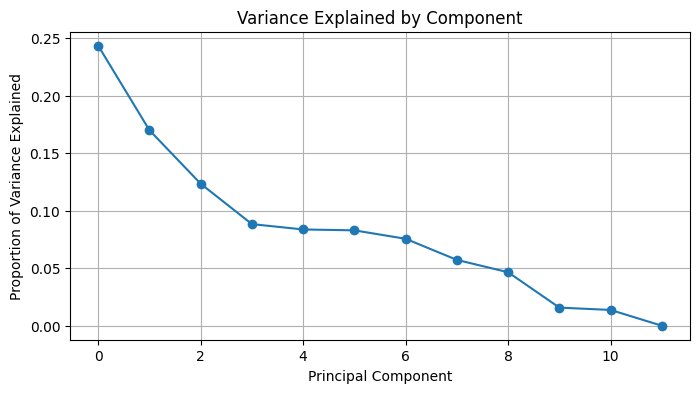

In [16]:
# Variable reduction
X=scale(hsd[quantitative_var])
pca = PCA()
## Estimation, calculation of principal components
C = pca.fit(X).transform(X)
# Decrease of explained variance
plt.figure(figsize=(8, 4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Variance Explained by Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid()

plt.show()

There is no clear number of components to explain well the data. We can see in a box plot for each components.

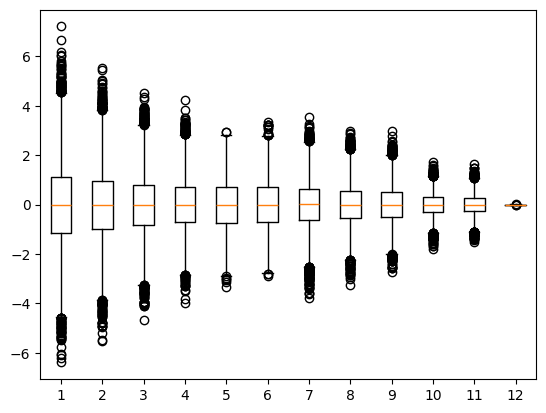

In [17]:
plt.boxplot(C[:,0:20])
plt.show()

We take the 3 first components to try to display the data in smaller dimension.

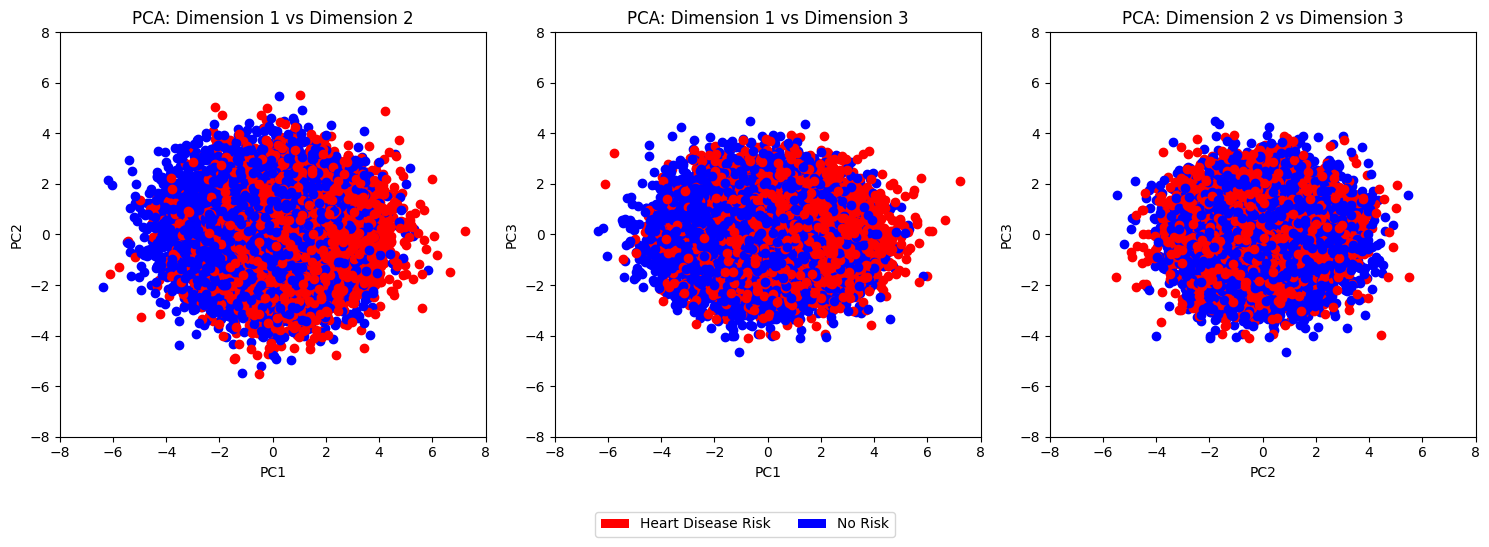

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# dimension 1 and 2
for i, j, nom in zip(C[:,0], C[:,1], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[0].plot(i, j, "o", color=color)
axes[0].axis((-8, 8, -8, 8))
axes[0].set_title("PCA: Dimension 1 vs Dimension 2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# dimension 1 and 3
for i, j, nom in zip(C[:,0], C[:,2], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[1].plot(i, j, "o", color=color)
axes[1].axis((-8, 8, -8, 8))
axes[1].set_title("PCA: Dimension 1 vs Dimension 3")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")

# dimension 2 and 3
for i, j, nom in zip(C[:,1], C[:,2], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[2].plot(i, j, "o", color=color)
axes[2].axis((-8, 8, -8, 8))
axes[2].set_title("PCA: Dimension 2 vs Dimension 3")
axes[2].set_xlabel("PC2")
axes[2].set_ylabel("PC3")

# Add global legend
legend_elements = [Patch(facecolor='red', label='Heart Disease Risk'),
                   Patch(facecolor='blue', label='No Risk')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)

plt.tight_layout()
plt.show()






In [19]:
#!! very long time running cellule !!
#dimension 1, 2 and 3
if False:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for i, j, k, nom in zip(C[:,0], C[:,1], C[:,2], hsd["Heart_Disease_Risk"]):
        color = "red" if nom  else "blue"
        ax.scatter(i, j, k, color=color)
    ax.set_xlabel('Composante 1')
    ax.set_ylabel('Composante 2')
    ax.set_zlabel('Composante 3')
    plt.title("Projection des données sur les 3 premières composantes principales")
    plt.show()

We have no clear separation between HDR individuals and no-HDR ones, for any components. However we can see that the HDR points are more concentrate in a place of the graph. The plot of components 1 and 3 give us the "best separation" so we can estimate that dimension 2 is less relevant for the separation. We now have a look to the variables and see how they participate for each components.

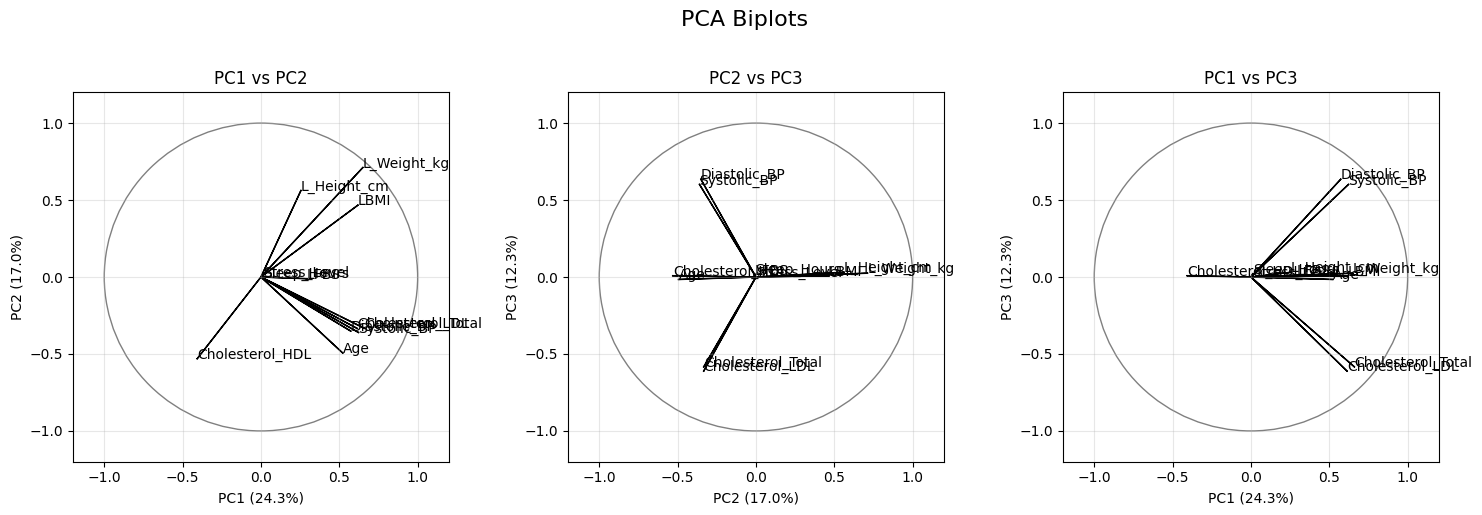

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PC1 vs PC2
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])
ax = axes[0]
for i, j, nom in zip(coord1, coord2, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC1 vs PC2")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.grid(True, alpha=0.3)
c1 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c1)

# PC2 vs PC3
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])
coord3 = pca.components_[2] * np.sqrt(pca.explained_variance_[2])
ax = axes[1]
for i, j, nom in zip(coord2, coord3, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC2 vs PC3")
ax.set_xlabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.grid(True, alpha=0.3)
c2 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c2)

# PC1 vs PC3
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord3 = pca.components_[2] * np.sqrt(pca.explained_variance_[2])
ax = axes[2]
for i, j, nom in zip(coord1, coord3, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC1 vs PC3")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.grid(True, alpha=0.3)
c3 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c3)

fig.suptitle("PCA Biplots", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


We can see that many variables are correlated together within these 3 dimensions. Futhermore, Dimension 2 and 3 have the same shape but inverted.

On dimensions 1 and 2, we have :
- L_weight_kg / LBMI / Height_cm wich are well represented and correlated together

On dimensions 2 and 3, variables are too badly represented.

On dimension 1 and 3, we have a good representation and a correlation with :
- Dialostic_BP and Systolic_BP
- Cholesterol_Total and Cholesterol_LDL

We find the same links than in the correlation matrix.

### Clustering with K-means

In [21]:
clust=KMeans(n_clusters=4)
clust.fit(X)
classe=clust.labels_
print(classe)
classe.shape

[2 0 0 ... 3 1 2]


(15000,)

[1 2 2 ... 0 3 1]


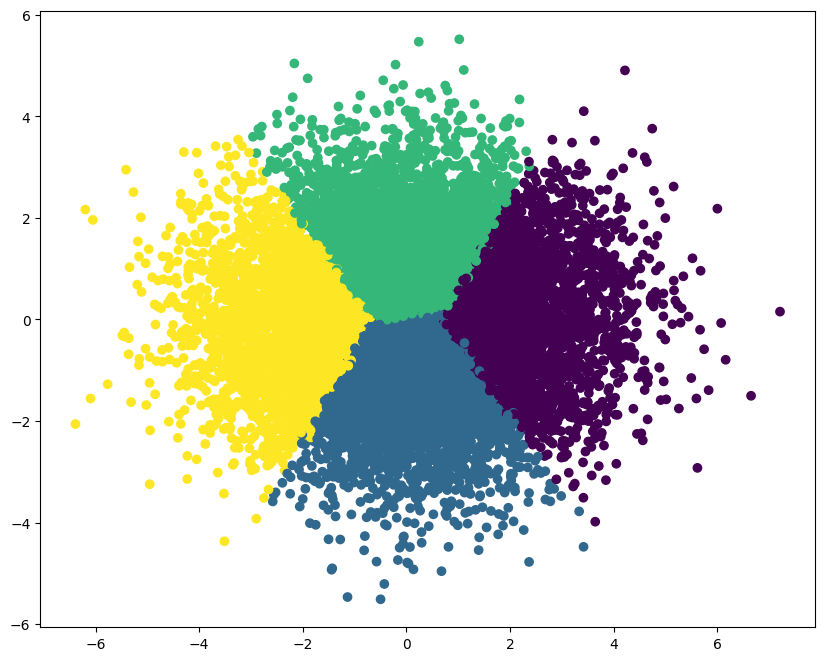

[0 1 1 ... 1 0 2]


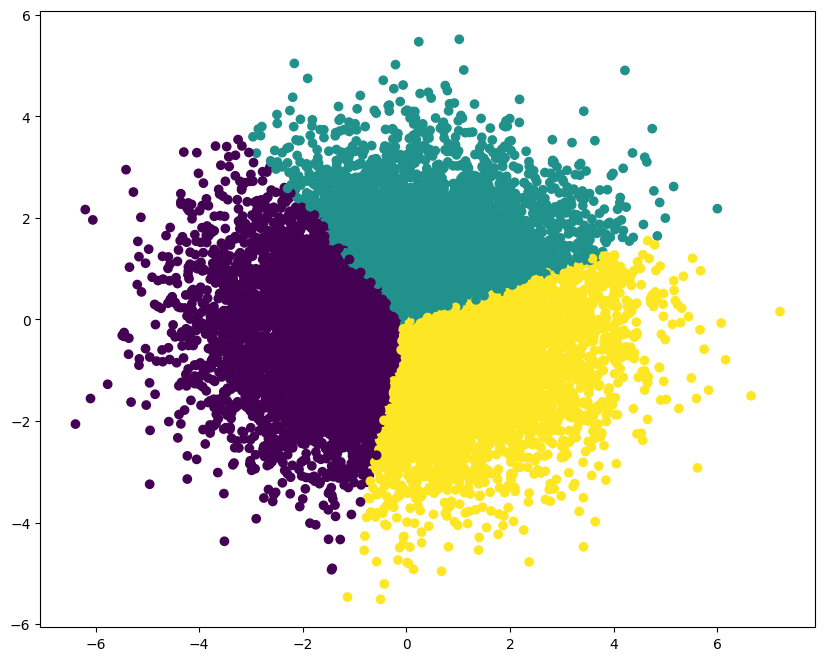

[1 1 0 ... 0 1 0]


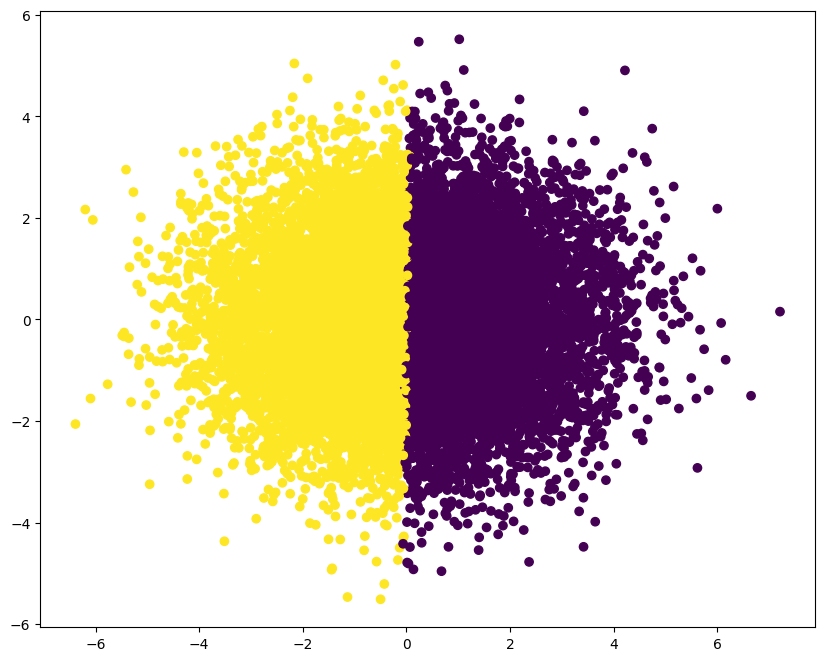

In [22]:
clust_4=KMeans(n_clusters=4)
clust_4.fit(X)
classe_4=clust_4.labels_
print(classe_4)
classe_4.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_4) 
plt.show()

clust_3=KMeans(n_clusters=3)
clust_3.fit(X)
classe_3=clust_3.labels_
print(classe_3)
classe_3.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_3) 
plt.show()

clust_2=KMeans(n_clusters=2)
clust_2.fit(X)
classe_2=clust_2.labels_
print(classe_2)
classe_2.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_2) 
plt.show()

Since k-means algorithms is not a supervised learning method, we cannot directly compare the clusters obtained with the actual labels of "Heart_Disease_Risk". However, we can analyze the distribution of the actual labels within each cluster to see if there is any meaningful separation.

In [23]:
hsd["Cluster_4"] = classe_4
hsd["Cluster_3"] = classe_3
hsd["Cluster_2"] = classe_2

# Analyze distribution of actual labels within each cluster for 4 clusters
print("Distribution of Heart Disease Risk within each Cluster (4 Clusters):")
for cluster in range(4):
    cluster_data = hsd[hsd["Cluster_4"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")

# Analyze distribution of actual labels within each cluster for 3 clusters
print("\nDistribution of Heart Disease Risk within each Cluster (3 Clusters):")
for cluster in range(3):
    cluster_data = hsd[hsd["Cluster_3"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")

# Analyze distribution of actual labels within each cluster for 2 clusters
print("\nDistribution of Heart Disease Risk within each Cluster (2 Clusters):")
for cluster in range(2):
    cluster_data = hsd[hsd["Cluster_2"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")



Distribution of Heart Disease Risk within each Cluster (4 Clusters):

Cluster 0:
Heart_Disease_Risk
1    58.5%
0    41.5%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    52.2%
1    47.8%
Name: proportion, dtype: str

Cluster 2:
Heart_Disease_Risk
0    60.9%
1    39.1%
Name: proportion, dtype: str

Cluster 3:
Heart_Disease_Risk
0    70.7%
1    29.3%
Name: proportion, dtype: str

Distribution of Heart Disease Risk within each Cluster (3 Clusters):

Cluster 0:
Heart_Disease_Risk
0    66.4%
1    33.6%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    56.9%
1    43.1%
Name: proportion, dtype: str

Cluster 2:
Heart_Disease_Risk
1    54.8%
0    45.2%
Name: proportion, dtype: str

Distribution of Heart Disease Risk within each Cluster (2 Clusters):

Cluster 0:
Heart_Disease_Risk
1    53.2%
0    46.8%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    65.9%
1    34.1%
Name: proportion, dtype: str


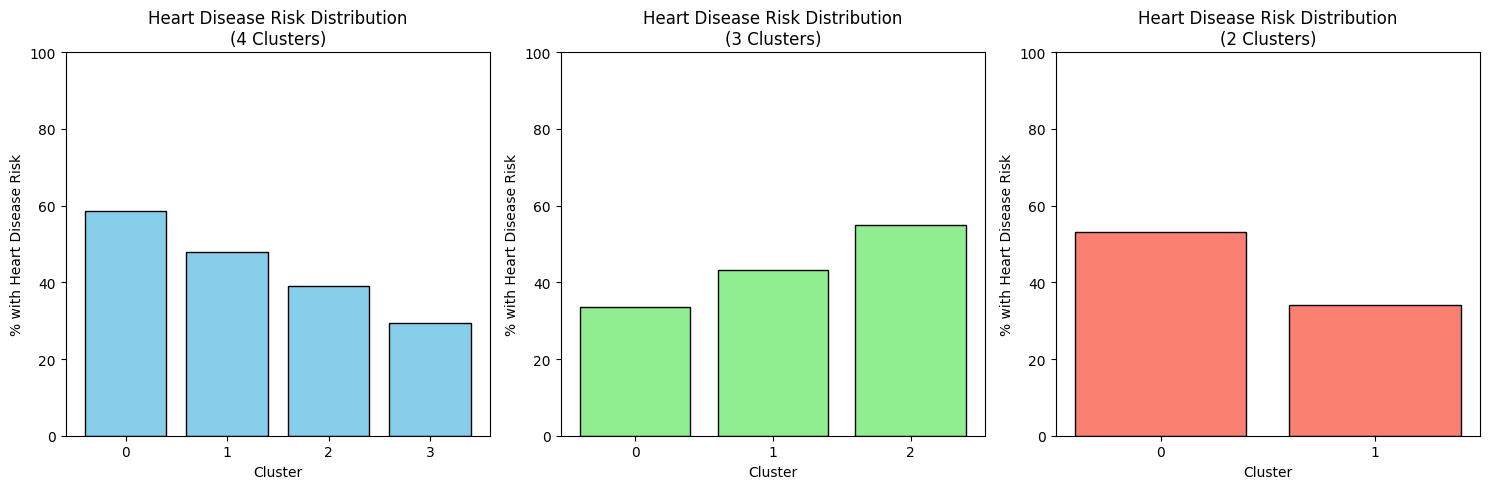

In [24]:
# Add cluster assignments if not already present
if "Cluster_4" not in hsd.columns:
    hsd["Cluster_4"] = classe_4
    hsd["Cluster_3"] = classe_3
    hsd["Cluster_2"] = classe_2

# Visualization of cluster distributions for Heart Disease Risk
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 4 Clusters
cluster_4_dist = []
for cluster in range(4):
    cluster_data = hsd[hsd["Cluster_4"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_4_dist.append(risk_pct.get(1, 0))

axes[0].bar(range(4), cluster_4_dist, color='skyblue', edgecolor='black')
axes[0].set_title("Heart Disease Risk Distribution\n(4 Clusters)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("% with Heart Disease Risk")
axes[0].set_xticks(range(4))
axes[0].set_ylim(0, 100)

# 3 Clusters
cluster_3_dist = []
for cluster in range(3):
    cluster_data = hsd[hsd["Cluster_3"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_3_dist.append(risk_pct.get(1, 0))

axes[1].bar(range(3), cluster_3_dist, color='lightgreen', edgecolor='black')
axes[1].set_title("Heart Disease Risk Distribution\n(3 Clusters)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("% with Heart Disease Risk")
axes[1].set_xticks(range(3))
axes[1].set_ylim(0, 100)

# 2 Clusters
cluster_2_dist = []
for cluster in range(2):
    cluster_data = hsd[hsd["Cluster_2"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_2_dist.append(risk_pct.get(1, 0))

axes[2].bar(range(2), cluster_2_dist, color='salmon', edgecolor='black')
axes[2].set_title("Heart Disease Risk Distribution\n(2 Clusters)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("% with Heart Disease Risk")
axes[2].set_xticks(range(2))
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


As we could expect with the distribution of points, we cannot compute a good separation in the data between the two classes with basic clustering (Heart Disease Risk and No Heart Disease Risk) using PCA and K-means. The clusters formed do not show a clear distinction between the two groups, indicating that the features used may not be sufficient to differentiate between patients with and without heart disease risk.

This suggests that either additional features are needed or that a different modeling approach may be necessary to effectively classify the patients based on their heart disease risk. That's why we will try different models seen in the Machine Learning course to see if we can get better results.

# Modelization

Our goal is to compare the performance of several modelization methods :
- Linear model (with/without : variable selection and penalization)
- SVR/SVM
- optimal tree
- random forest
- boosting
- neural networks

For each model we will identify the hyperparameters and adjust them with cross validation methods. 

##### Data set

In [25]:
hsd_clean = hsd.drop("Patient_ID",axis=1)

In [26]:
## Divide the dataset : train and test samples + SCALE

scaler = StandardScaler()

### DATA
hsd_clean_copy= hsd_clean.copy()
y_heart= hsd_clean_copy["Heart_Disease_Risk"]
X_heart = hsd_clean_copy.drop("Heart_Disease_Risk",axis=1)

hsd_clean_copy= hsd_clean.copy()
y_chol= hsd_clean_copy["Cholesterol_LDL"]
X_chol = hsd_clean_copy.drop(["Cholesterol_LDL", "Heart_Disease_Risk"], axis=1)


### SPLIT
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

X_chol_train, X_chol_test, y_chol_train, y_chol_test = train_test_split(
    X_chol, y_chol, test_size=0.2, random_state=42
)

### SCALE
X_heart_train = pd.DataFrame(
    scaler.fit_transform(X_heart_train),
    columns=X_heart.columns,
    index=X_heart_train.index
)

X_heart_test = pd.DataFrame(
    scaler.transform(X_heart_test),
    columns=X_heart.columns,
    index=X_heart_test.index
)

X_chol_train = pd.DataFrame(
    scaler.fit_transform(X_chol_train),
    columns=X_chol.columns,
    index=X_chol_train.index 
)

X_chol_test = pd.DataFrame(
    scaler.transform(X_chol_test),
    columns=X_chol.columns,
    index=X_chol_test.index
)


This step is necessary to be able to make a realistic evaluation of our model and to make sure we do not have an overfitted model.

##### Comparison table

Throughout the project, we will collect the results of each method in order to compare them at the end and determine which approaches are most suitable, and under which circumstances each should be used.

In [ ]:
idx = pd.IndexSlice


# Rows: Model → Subsection
rows = pd.MultiIndex.from_tuples([
    ("Linear Model", "Conventional"),
    ("Linear Model", "Variable Selection - AIC"),
    ("Linear Model", "Variable Selection - BIC"),
    ("Linear Model", "Variable Selection - p-value"),
    ("Linear Model", "Variable Selection - Lasso"),
    ("Linear Model", "Penalization - Lasso"),
    ("Linear Model", "Penalization - Ridge"),
    ("Linear Model", "Penalization - ElasticNet"),


    ("SVM", "Kernel - Linear"),
    ("SVM", "Kernel - RBF"),
    ("SVM", "Kernel - Polynomial"),
    ("SVM", "SVC - Threshold 0.4"),
    ("SVM", "SVC - SelectKBest"),
    ("SVM", "SVC - Balanced Classes"),

    ("CART", "Complete Tree"),
    ("CART", "Optimized Tree"),

    ("Random Forest", "Default RF"),
    ("Random Forest", "Optimized RF"),

    ("Boosting", "AdaBoost"),
    ("Boosting", "Gradient Boosting"),
    ("Boosting", "XGBoost"),
    ("Boosting", "HistGradientBoosting"),

    ("Neural Network", "Classification MLP"),
    ("Neural Network", "Regression MLP")
    
])

# Columns: Section → Metrics
columns = pd.MultiIndex.from_tuples([
    ("Classification", "Accuracy"),
    ("Classification", "Sensitivity"),
    ("Classification", "Specificity"),
    ("Classification", "AUC"),

    ("Regression", "MSE"),
    ("Regression", "RMSE"),
    ("Regression", "MAE"),
    ("Regression", "R²"),

    ("Complexity", "Nb variables"),
    ("Explicability", "Low/Medium/High")
])

# Empty table
results_table = pd.DataFrame(np.nan, index=rows, columns=columns)


results_table[("Explicability", "Low/Medium/High")] = (
    results_table[("Explicability", "Low/Medium/High")].astype("object")
)


idx = pd.IndexSlice

# this can be updated through the project
explicability_dic = {
    ("Linear Model", "Conventional"): "High",
    ("Linear Model", "Variable Selection - AIC"): "High",
    ("Linear Model", "Variable Selection - BIC"): "High",
    ("Linear Model", "Variable Selection - p-value"): "High",
    ("Linear Model", "Variable Selection - Lasso"): "High",
    ("Linear Model", "Penalization - Lasso"): "High",
    ("Linear Model", "Penalization - Ridge"): "Medium",
    ("Linear Model", "Penalization - ElasticNet"): "Medium",

    ("SVM", "Kernel - Linear"): "Medium",
    ("SVM", "Kernel - RBF"): "Low",
    ("SVM", "Kernel - Polynomial"): "Low",
    ("SVM", "SVC - Threshold 0.4"): "Low",
    ("SVM", "SVC - SelectKBest"): "Medium",
    ("SVM", "SVC - Balanced Classes"): "Low",

    ("CART", "Complete Tree"): "Medium",
    ("CART", "Optimized Tree"): "High",

    ("Random Forest", "Default RF"): "Low",
    ("Random Forest", "Optimized RF"): "Low",

    ("Boosting", "AdaBoost"): "Low",
    ("Boosting", "Gradient Boosting"): "Low",
    ("Boosting", "XGBoost"): "Low",
    ("Boosting", "HistGradientBoosting"): "Low",

    ("Neural Network", "Classification MLP"): "Low",
    ("Neural Network", "Regression MLP"): "Low",
}


def update_detailed_results_table(model, subsection, classification_metrics, regression_metrics, num_variables, explicability = None):
    if classification_metrics is not None:
        results_table.loc[(model, subsection), ("Classification", "Accuracy")] = classification_metrics.get("Accuracy", np.nan)
        results_table.loc[(model, subsection), ("Classification", "Sensitivity")] = classification_metrics.get("Sensitivity", np.nan)
        results_table.loc[(model, subsection), ("Classification", "Specificity")] = classification_metrics.get("Specificity", np.nan)
        results_table.loc[(model, subsection), ("Classification", "AUC")] = classification_metrics.get("AUC", np.nan)

    if regression_metrics is not None:
        results_table.loc[(model, subsection), ("Regression", "MSE")] = regression_metrics.get("MSE", np.nan)
        results_table.loc[(model, subsection), ("Regression", "RMSE")] = regression_metrics.get("RMSE", np.nan)
        results_table.loc[(model, subsection), ("Regression", "MAE")] = regression_metrics.get("MAE", np.nan)
        results_table.loc[(model, subsection), ("Regression", "R²")] = regression_metrics.get("R²", np.nan)

    results_table.loc[(model, subsection), ("Complexity", "Nb variables")] = num_variables
    if explicability is not None :
        results_table.loc[(model, subsection), ("Explicability", "Low/Medium/High")] = explicability
    else :
        results_table.loc[(model, subsection), ("Explicability", "Low/Medium/High")] = explicability_dic.get((model, subsection), np.nan)

def display_detailed_results_table():

    high_is_better = [
        ("Classification", "Accuracy"),
        ("Classification", "Sensitivity"),
        ("Classification", "Specificity"),
        ("Classification", "AUC"),
        ("Regression", "R²")
    ]

    low_is_better = [
        ("Regression", "MSE"),
        ("Regression", "RMSE"),
        ("Regression", "MAE")
    ]

    complexity = [
        ("Complexity", "Nb variables")
    ]


    exp_col = ("Explicability", "Low/Medium/High")
    explicability = [exp_col]


    styled_table = (
        results_table.style
        .format({
            ("Classification", "Accuracy"): "{:.3f}",
            ("Classification", "Sensitivity"): "{:.3f}",
            ("Classification", "Specificity"): "{:.3f}",
            ("Classification", "AUC"): "{:.3f}",

            ("Regression", "MSE"): "{:.3f}",
            ("Regression", "RMSE"): "{:.3f}",
            ("Regression", "MAE"): "{:.3f}",
            ("Regression", "R²"): "{:.3f}",

            ("Complexity", "Nb variables"): "{:.0f}",

            ("Explicability", "Low/Medium/High"): lambda x: x if pd.notna(x) else "–"
        }, na_rep="–")

        # Higher = better
        .background_gradient(
            cmap="Greens",
            subset=idx[:, high_is_better],
            axis=0
        )

        # Lower = better
        .background_gradient(
            cmap="Reds_r",
            subset=idx[:, low_is_better],
            axis=0
        )

        # Fewer variables = better
        .background_gradient(
            cmap="Blues_r",
            subset=idx[:, complexity],
            axis=0
        )

        .map(
            lambda x: {
                "Low": "background-color: #dc2626; color: white; font-weight: bold",
                "Medium": "background-color: #facc15; color: black; font-weight: bold",
                "High": "background-color: #16a34a; color: white; font-weight: bold"
            }.get(x, ""),
            subset=idx[:, explicability]
        )

        .set_caption("Model Performance Comparison")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "22px"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "14px"),
                    ("color", "#111827")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "13px"),
                    ("width", "100%"),
                    ("border", "1px solid #E5E7EB")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#111827"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px"),
                    ("border", "1px solid #374151")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "9px"),
                    ("border", "1px solid #E5E7EB")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F9FAFB")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#EEF2FF")
                ]
            }
        ])
    )

    display(styled_table)

display_detailed_results_table()

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin


### 1. Linear model



a) Model selection

b) Variable selection (AIC, BIC, pvalue)

c) Penalization (Lasso, Ridge, ElasticNet, None)

##### a) Model

Since the `Heart_Disease_Risk` is a qualitative variable (binary), we will use a logistic regression model. This variable measures the risk of having a heart disease, where over 0.5 we consider the patient to be at high risk and under 0.5 at low risk.

Since the `Cholesterol_LDL` is a quantitative variable, we will use a linear regression model. This variable measures the Low-Density Lipoprotein / "Bad" cholesterol in mg/dL.

##### Metrics

To quantify the performance of our models, we are going to be using the following metrics :
* Logistic Regression : accuracy, specificity, sensitivity, AUC, number of variables (complexity or our model)
* Linear Regression : MSE, RMSE, R2, MAE, number of variables (complexity or our model)

In [33]:
### HEART DISEASE RISK - logistic regression

# Fit the model + predict the classes

logi = LogisticRegression(max_iter=5000).fit(X_heart_train, y_heart_train)
y_pred_logi_class = logi.predict(X_heart_test)

print("---HEART DISEASE RISK---")
print(f"Logistic Regression Score : {logi.score(X_heart_test, y_heart_test)}")
print("Logistic Regression Accuracy:", accuracy_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression AUC:", roc_auc_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression Sensitivity:", confusion_matrix(y_heart_test, y_pred_logi_class)[1][1] / (confusion_matrix(y_heart_test, y_pred_logi_class)[1][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[1][1]))
print("Logistic Regression Specificity:", confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] / (confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[0][1]))
print("Logistic Regression Number of Variables:", len(X_heart.columns))

### CHOLESTEROL LEVEL - linear regression

# Fit the model + predict the values
linreg = LinearRegression().fit(X_chol_train, y_chol_train)
y_pred_linreg = linreg.predict(X_chol_test)

print("---CHOLESTEROL LEVEL---")
print(f"Linear Regression R^2 Score : {linreg.score(X_chol_test, y_chol_test)}")
print("Linear Regression MSE:", mean_squared_error(y_chol_test, y_pred_linreg))
print("Linear Regression RMSE:", sqrt(mean_squared_error(y_chol_test, y_pred_linreg)))
print("Linear Regression MAE:", mean_absolute_error(y_chol_test, y_pred_linreg))
print("Linear Regression Number of Variables:", len(X_chol.columns))


## ADD DATA IN THE TABLE
update_detailed_results_table(
    model="Linear Model",
    subsection="Conventional",
    classification_metrics={
        "Accuracy": accuracy_score(y_heart_test, y_pred_logi_class),
        "Sensitivity": confusion_matrix(y_heart_test, y_pred_logi_class)[1, 1] /
                       (confusion_matrix(y_heart_test, y_pred_logi_class)[1, 0] +
                        confusion_matrix(y_heart_test, y_pred_logi_class)[1, 1]),
        "Specificity": confusion_matrix(y_heart_test, y_pred_logi_class)[0, 0] /
                       (confusion_matrix(y_heart_test, y_pred_logi_class)[0, 0] +
                        confusion_matrix(y_heart_test, y_pred_logi_class)[0, 1]),
        "AUC": roc_auc_score(y_heart_test, y_pred_logi_class)
    },
    regression_metrics={
        "MSE": mean_squared_error(y_chol_test, y_pred_linreg),
        "RMSE": sqrt(mean_squared_error(y_chol_test, y_pred_linreg)),
        "MAE": mean_absolute_error(y_chol_test, y_pred_linreg),
        "R²": linreg.score(X_chol_test, y_chol_test)
    },
    num_variables=len(X_heart.columns)
)


---HEART DISEASE RISK---
Logistic Regression Score : 0.7396666666666667
Logistic Regression Accuracy: 0.7396666666666667
Logistic Regression AUC: 0.7281789976694611
Logistic Regression Sensitivity: 0.6393568147013783
Logistic Regression Specificity: 0.8170011806375442
Logistic Regression Number of Variables: 24
---CHOLESTEROL LEVEL---
Linear Regression R^2 Score : 0.7126299562570628
Linear Regression MSE: 90.03951968864935
Linear Regression RMSE: 9.488915622380112
Linear Regression MAE: 7.479392903248747
Linear Regression Number of Variables: 23


In [ ]:
display_detailed_results_table()

RISK OF HEART DISEASE : With logisitc regression, we seem to get an appropriate model overall, with an AUC of about 72%. This shows a good ability to distinguish our data points between the two classes and therefore predict if there is a risk of heart desease based on several patient features. We want to control the risk of not diagnosting a patient that has a risk of heart disease. With a sensitivity of 0.63, we know that 37% of patients with heart disease risk are not diagnosed, which is a pretty high amount of missed predictions. On the contrary, with a specificity of 0.82, we predict the absence of risk to 82% of the healthy patients.

CHOLESTEROL LEVEL : Our linear regression model has a mean squared error of arounf 95%, which is an indicator of a high ability to predict closely enough the cholesterol level. However, we have a R2 of around 0.7 which shows that there is a bit of overfitting which might compromise the truthfulness of our high MSE value.

To make the accuracy analysis more robust, we can also use k-fold cross-validation. Instead of evaluating the model on a single train-test split, cross-validation repeatedly divides the data into different training and validation subsets and averages the results. This gives a more reliable estimate of model performance and reduces the risk that the conclusion depends too strongly on one particular split of the dataset.

##### Balancing classes

In [34]:
pipeline = Pipeline([("model", LogisticRegression(max_iter=5000,class_weight='balanced'))])
scores = cross_val_score(pipeline, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
print("BALANCED : Mean CV AUC:", scores.mean())

pipeline = Pipeline([("model", LogisticRegression(max_iter=5000))])
scores = cross_val_score(pipeline, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
print("UNBALANCED : Mean CV AUC:", scores.mean())

BALANCED : Mean CV AUC: 0.806703156652793
UNBALANCED : Mean CV AUC: 0.8067236275999686


Adding ``class_weight="balanced"`` did not improve the cross-validated AUC. The unweighted logistic regression achieved a slightly higher mean CV AUC, although the difference is negligible. This suggests that class imbalance is not a major issue for this model, or that reweighting does not bring additional predictive benefit in terms of discrimination.

#### b) Variable Selection

In this section we are going to use variable selection to get a more simple and interpretable model, even if we are aware that it could also be more unstable and overfit.

Hence we are going to determine a subset of predictors by adding and removing variables based on several citeria:
- AIC
- BIC
- p-values
- Lasso


##### i) AIC

In [35]:
# AIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_aic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_aic = float("inf")
        # for every variable that has been excluded we find the one with the lowest AIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_aic < model_given(y, sm.add_constant(X[included])).fit(disp=0).aic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_aic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).aic
            # we remove the selected variable if the aic is lower when we remove it
            if new_aic < model.aic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included



In [36]:
# AIC Algorithm (Forward) - returns the selected variables
def stepwise_aic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_aic = float("inf")

        # for every variable that has been excluded we find the one with the lowest AIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature = new_col

        # we check if by adding the best selected variable we get a lower aic
        if best_aic < model_given(y, sm.add_constant(X[included])).fit(disp=0).aic:
            included.append(best_feature)
            changed = True
    
        if not changed:
            break
        
    return included



##### ii) BIC

In [37]:
# BIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_bic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_bic = float("inf")
        # for every variable that has been excluded we find the one with the lowest BIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.bic < best_bic:
                best_bic = model.bic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_bic < model_given(y, sm.add_constant(X[included])).fit(disp=0).bic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_bic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).bic
            # we remove the selected variable if the aic is lower when we remove it
            if new_bic < model.bic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included


In [38]:
# BIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_bic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_bic = float("inf")
        # for every variable that has been excluded we find the one with the lowest BIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.bic < best_bic:
                best_bic = model.bic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_bic < model_given(y, sm.add_constant(X[included])).fit(disp=0).bic:
            included.append(best_feature)
            changed = True
            
        if not changed:
            break
    return included


##### iii) p-value


In [39]:
# P-value Algorithm (Forward-Backward) - returns the selected variables

def stepwise_pval_FB(X, y, model_given, entry_p=0.05, stay_p=0.05):
    included = []
    while True:
        changed = False

        ### FORWARD step
        excluded = list(set(X.columns) - set(included))
        best_pval = 1.0
        for col in excluded:
            model = model_given(y, sm.add_constant(X[included + [col]])).fit(disp=0)
            pval = model.pvalues[col]
            # we look for the varible with the lowest p-value
            if pval < best_pval:
                best_pval = pval
                best_feature = col
        # we check if adding the best selected variable gives us a p-value lower than the entry threshold
        if best_pval < entry_p:
            included.append(best_feature)
            changed = True

        ### BACKWARD step
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst_pval = pvals.max()
            # we remove the variable with the highest p-value if it is higher than the stay threshold
            if worst_pval > stay_p:
                worst_feature = pvals.idxmax()
                included.remove(worst_feature)
                changed = True

        # we stop the algorithm if no variable is added or removed
        if not changed:
            break
        
    return included




In [40]:
# P-value Algorithm (Forward-Backward) - returns the selected variables

def stepwise_pval_FB(X, y, model_given, entry_p=0.05, stay_p=0.05):
    included = []
    while True:
        changed = False

        ### FORWARD step
        excluded = list(set(X.columns) - set(included))
        best_pval = 1.0
        for col in excluded:
            model = model_given(y, sm.add_constant(X[included + [col]])).fit(disp=0)
            pval = model.pvalues[col]
            # we look for the varible with the lowest p-value
            if pval < best_pval:
                best_pval = pval
                best_feature = col
        # we check if adding the best selected variable gives us a p-value lower than the entry threshold
        if best_pval < entry_p:
            included.append(best_feature)
            changed = True


        # we stop the algorithm if no variable is added or removed
        if not changed:
            break
        
    return included




##### iv) Lasso

Lasso can be used to select a smaller subset of predictors, as it includes variable selection by putting a few coefficients down to zero, while ridge keeps all predictors but shrinks them never reaching zero.

In [41]:
def lasso_var_sel(X_train, y_train, alpha=0.01, graphs=False):

    # Reset index
    X = X_train.reset_index(drop=True)
    y = pd.Series(y_train).reset_index(drop=True)

    # Fit LASSO
    model_lasso = linear_model.Lasso(alpha=alpha)
    model_lasso.fit(X, y)

    # Get coefficients
    coef = pd.Series(model_lasso.coef_, index=X.columns)

    #print(f"Lasso keeps {sum(coef != 0)} variables and removes {sum(coef == 0)}")

    # Plot (optional)
    if graphs:
        imp_coef = coef[coef != 0].sort_values()
        plt.figure(figsize=(8, 10))
        imp_coef.plot(kind="barh")
        plt.title("LASSO Coefficients (non-zero)")
        plt.show()

    # Return selected variables
    return coef.index[coef != 0]


Variable selection algorithm comparison : AIC, BIC, p-value, Lasso

In [42]:
def classification_metrics(y_test, y_proba, y_pred, nb_variables):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Sensitivity": recall_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "AUC": roc_auc_score(y_test, y_proba),
        "Nb variables": nb_variables
    }


def regression_metrics(y_test, y_pred, nb_variables):
    mse = mean_squared_error(y_test, y_pred)

    return {
        "MSE": mse,
        "RMSE": sqrt(mse),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
        "Nb variables": nb_variables
    }

def variable_selection(X_train, y_train, X_test, y_test, model, model_given, print_results=True):

    # Selected variables
    selected_variables_AIC = stepwise_aic_FB(X_train, y_train, model_given)
    selected_variables_BIC = stepwise_bic_FB(X_train, y_train, model_given)
    selected_variables_pval = stepwise_pval_FB(X_train, y_train, model_given)
    selected_variables_lasso = lasso_var_sel(X_train, y_train)

    # AIC Data set
    X_train_AIC = X_train[selected_variables_AIC]
    X_test_AIC = X_test[selected_variables_AIC] 
    X_train_BIC = X_train[selected_variables_BIC]
    X_test_BIC = X_test[selected_variables_BIC]
    X_train_pval = X_train[selected_variables_pval]
    X_test_pval = X_test[selected_variables_pval]
    X_train_lasso = X_train[selected_variables_lasso]
    X_test_lasso = X_test[selected_variables_lasso]


    # FIT

    pipeline_aic = Pipeline([
        ('logi', clone(model))
    ])

    pipeline_bic = Pipeline([
        ('logi', clone(model))
    ])

    pipeline_pval = Pipeline([
        ('logi', clone(model))
    ])

    pipeline_lasso = Pipeline([
        ('logi', clone(model))
    ])

    pipeline_aic.fit(X_train_AIC, y_train)
    pipeline_bic.fit(X_train_BIC, y_train)
    pipeline_pval.fit(X_train_pval, y_train)
    pipeline_lasso.fit(X_train_lasso, y_train)

    print(f"\n---{model}---")

    if model_given == sm.Logit:
        
        print(f"\nWITHOUT VARIABLE SELECTION : AUC (test set) : {roc_auc_score(y_test, model.fit(X_train, y_train).predict_proba(X_test)[:,1])}")

        # SCORE
        y_pred_proba = pipeline_aic.predict_proba(X_test_AIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AIC : {model} AUC (test set): {auc} | Number of variables: {X_test_AIC.shape[1]}")

        y_pred_proba = pipeline_bic.predict_proba(X_test_BIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"BIC : {model} AUC (test set): {auc} | Number of variables: {X_test_BIC.shape[1]}")

        y_pred_proba = pipeline_pval.predict_proba(X_test_pval)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"PVALUE : {model} AUC (test set): {auc} | Number of variables: {X_test_pval.shape[1]}")

        y_pred_proba = pipeline_lasso.predict_proba(X_test_lasso)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"Lasso : {model} AUC (test set): {auc} | Number of variables: {X_test_lasso.shape[1]}")
    

        ## SCORE TABLE
        table_scores = {}

        for name, pipeline, X_test_sel in [
            ("AIC", pipeline_aic, X_test_AIC),
            ("BIC", pipeline_bic, X_test_BIC),
            ("P-value", pipeline_pval, X_test_pval),
            ("Lasso", pipeline_lasso, X_test_lasso)
        ]:
            y_proba = pipeline.predict_proba(X_test_sel)[:, 1]
            y_pred = pipeline.predict(X_test_sel)

            table_scores[name] = classification_metrics(
                y_test,
                y_proba,
                y_pred,
                nb_variables=X_test_sel.shape[1]
            )
        

    else:

        print(f"\nWITHOUT VARIABLE SELECTION : MSE (test set) : {mean_squared_error(y_test, model.fit(X_train, y_train).predict(X_test))}")

        MSE_AIC = mean_squared_error(y_test, pipeline_aic.predict(X_test_AIC))
        print(f"AIC : {model} MSE (test set): {MSE_AIC} | Number of variables: {X_test_AIC.shape[1]}")

        MSE_BIC = mean_squared_error(y_test, pipeline_bic.predict(X_test_BIC))
        print(f"BIC : {model} MSE (test set): {MSE_BIC} | Number of variables: {X_test_BIC.shape[1]}")

        MSE_PVAL = mean_squared_error(y_test, pipeline_pval.predict(X_test_pval))
        print(f"PVALUE : {model} MSE (test set): {MSE_PVAL} | Number of variables: {X_test_pval.shape[1]}")

        MSE_LASSO = mean_squared_error(y_test, pipeline_lasso.predict(X_test_lasso))
        print(f"Lasso : {model} MSE (test set): {MSE_LASSO} | Number of variables: {X_test_lasso.shape[1]}")

        ## SCORE TABLE
        table_scores = {}

        for name, pipeline, X_test_sel in [
            ("AIC", pipeline_aic, X_test_AIC),
            ("BIC", pipeline_bic, X_test_BIC),
            ("P-value", pipeline_pval, X_test_pval),
            ("Lasso", pipeline_lasso, X_test_lasso)
        ]:
            y_pred = pipeline.predict(X_test_sel)

            table_scores[name] = regression_metrics(
                y_test,
                y_pred,
                nb_variables=X_test_sel.shape[1]
            )

    print("\nSelected variables:")
    print("Selected variables AIC:", selected_variables_AIC)
    print("Selected variables BIC:", selected_variables_BIC)
    print("Selected variables P-value:", selected_variables_pval)
    print("Selected variables Lasso:", selected_variables_lasso)



    return selected_variables_AIC, selected_variables_BIC, selected_variables_pval, selected_variables_lasso, table_scores

selected_variables_AIC_heart, selected_variables_BIC_heart, selected_variables_pval_heart, selected_variables_lasso_heart, table_scores_heart = variable_selection(X_heart_train, y_heart_train, X_heart_test, y_heart_test, LogisticRegression(max_iter=5000), sm.Logit)
selected_variables_AIC_chol, selected_variables_BIC_chol, selected_variables_pval_chol, selected_variables_lasso_chol, table_scores_chol = variable_selection(X_chol_train, y_chol_train, X_chol_test, y_chol_test, LinearRegression(), sm.OLS)

# sm:Logit and sm.OLS are the model_given for logistic regression and linear regression respectively from the statsmodels library

## UPDATE THE TABLE
methods = ["AIC", "BIC", "p-value", "Lasso"]


for method in methods:

    # Careful: table_scores uses "P-value", but table row uses "p-value"
    score_key = "P-value" if method == "p-value" else method

    update_detailed_results_table(
        model="Linear Model",
        subsection=f"Variable Selection - {method}",
        classification_metrics={
            "Accuracy": table_scores_heart[score_key]["Accuracy"],
            "Sensitivity": table_scores_heart[score_key]["Sensitivity"],
            "Specificity": table_scores_heart[score_key]["Specificity"],
            "AUC": table_scores_heart[score_key]["AUC"]
        },
        regression_metrics={
            "MSE": table_scores_chol[score_key]["MSE"],
            "RMSE": table_scores_chol[score_key]["RMSE"],
            "MAE": table_scores_chol[score_key]["MAE"],
            "R²": table_scores_chol[score_key]["R²"]
        },
        num_variables=table_scores_heart[score_key]["Nb variables"]
    )


---LogisticRegression(max_iter=5000)---

WITHOUT VARIABLE SELECTION : AUC (test set) : 0.806811175737808
AIC : LogisticRegression(max_iter=5000) AUC (test set): 0.8071185392638824 | Number of variables: 13
BIC : LogisticRegression(max_iter=5000) AUC (test set): 0.8063306942257242 | Number of variables: 11
PVALUE : LogisticRegression(max_iter=5000) AUC (test set): 0.8063306942257242 | Number of variables: 11
Lasso : LogisticRegression(max_iter=5000) AUC (test set): 0.8062466212612391 | Number of variables: 12

Selected variables:
Selected variables AIC: ['Smoking_Status', 'Family_History', 'Cluster_4', 'Physical_Activity_Level', 'Fasting_Blood_Sugar', 'Stress_Level', 'Systolic_BP', 'Cholesterol_LDL', 'BMI', 'Age', 'Sleep_Hours', 'Cholesterol_HDL', 'Cluster_3']
Selected variables BIC: ['Smoking_Status', 'Family_History', 'Cluster_4', 'Physical_Activity_Level', 'Fasting_Blood_Sugar', 'Stress_Level', 'Systolic_BP', 'Cholesterol_LDL', 'BMI', 'Age', 'Sleep_Hours']
Selected variables P-value

In [43]:
display_detailed_results_table()

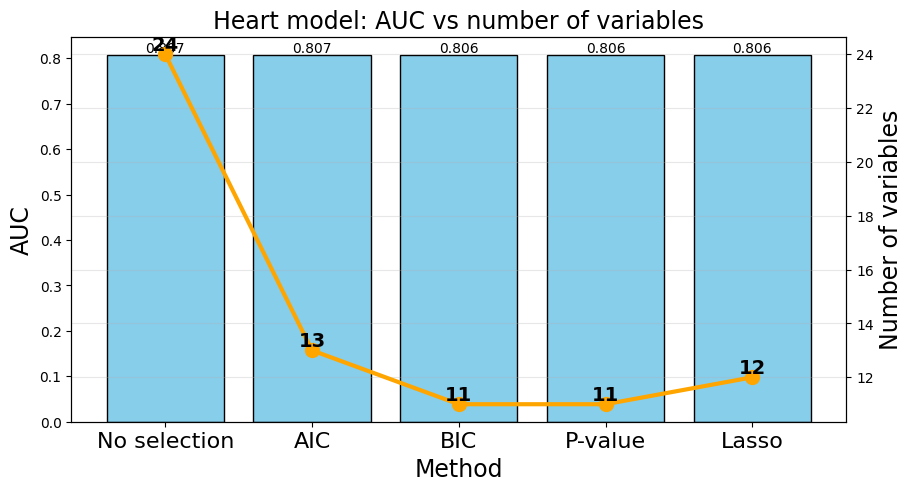

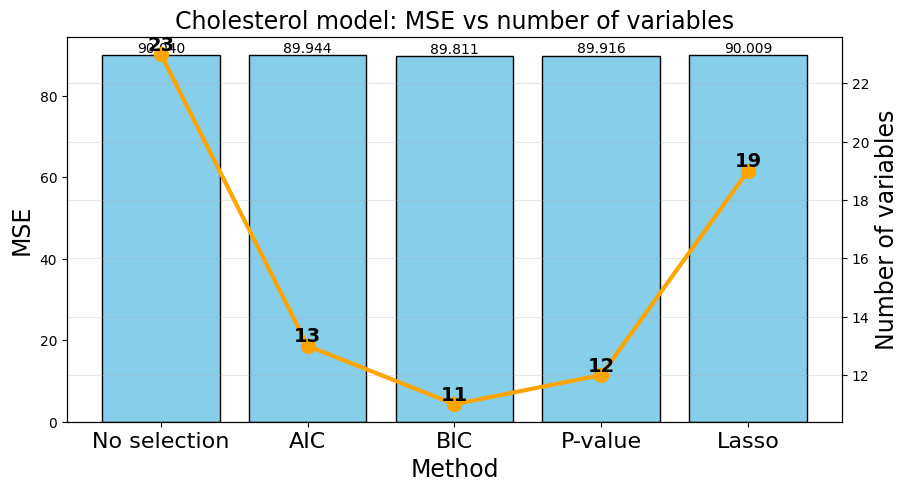

In [44]:
def variable_selection_visual_combined(
    X_train, y_train, X_test, y_test,
    model, model_given,
    title="Variable selection comparison"
):

    # Selected variables
    selected_variables_AIC = stepwise_aic_FB(X_train, y_train, model_given)
    selected_variables_BIC = stepwise_bic_FB(X_train, y_train, model_given)
    selected_variables_pval = stepwise_pval_FB(X_train, y_train, model_given)
    selected_variables_lasso = lasso_var_sel(X_train, y_train)

    selected_sets = {
        "No selection": list(X_train.columns),
        "AIC": selected_variables_AIC,
        "BIC": selected_variables_BIC,
        "P-value": selected_variables_pval,
        "Lasso": selected_variables_lasso
    }

    methods = []
    scores = []
    n_vars = []

    for method, variables in selected_sets.items():

        X_train_sel = X_train[variables]
        X_test_sel = X_test[variables]

        pipeline = Pipeline([
            ("model", clone(model))
        ])

        pipeline.fit(X_train_sel, y_train)

        if model_given == sm.Logit:
            y_pred = pipeline.predict_proba(X_test_sel)[:, 1]
            score = roc_auc_score(y_test, y_pred)
            metric = "AUC"
        else:
            y_pred = pipeline.predict(X_test_sel)
            score = mean_squared_error(y_test, y_pred)
            metric = "MSE"

        methods.append(method)
        scores.append(score)
        n_vars.append(len(variables))

    # PLOT
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Bars → performance
    ax1.bar(methods, scores, color='skyblue', edgecolor='black')
    ax1.set_ylabel(metric, fontsize=17)
    ax1.set_xlabel("Method", fontsize=17)
    ax1.set_title(title, fontsize=17)
    plt.xticks(fontsize=16)
    

    for i, v in enumerate(scores):
        ax1.text(i, v, f"{v:.3f}", ha='center', va='bottom')

    # Line → number of variables
    ax2 = ax1.twinx()
    ax2.plot(methods, n_vars, marker='o', color='orange',markersize=10,linewidth=3)
    ax2.set_ylabel("Number of variables", fontsize=17)

    for i, v in enumerate(n_vars):
        ax2.text(
            i, v, str(v),
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'     
        )

    plt.grid(axis="y", alpha=0.3)
    plt.show()

variable_selection_visual_combined(
    X_heart_train, y_heart_train,
    X_heart_test, y_heart_test,
    LogisticRegression(max_iter=5000),
    sm.Logit,
    title="Heart model: AUC vs number of variables"
)

variable_selection_visual_combined(
    X_chol_train, y_chol_train,
    X_chol_test, y_chol_test,
    LinearRegression(),
    sm.OLS,
    title="Cholesterol model: MSE vs number of variables"
)


##### Best variable selection method?
HEART DISEASE RISK :
We get very similar AUC scores for the four methods. BIC offers a lower AUC score (0.01 below) and the selected model only has 7 variables (AIC : 10 | p-value : 11 | Lasso : 16), which is very convenient for complexity matters. Therefore, BIC may be preferred for interpretability and model simplicity.

CHOLESTEROL LEVEL :
We get very similar MSE scores for the four methods. Even though BIC's method has an MSE of 93 compared to 92 for the rest of the methods, it has a significant lower amount of selected variables. Therefore, the BIC method may be preferred for interpretability and model simplicity again.

With or without variable selection ?

When we only consider a selected amount of our initial variables, we find ourselves with less complex models. In our case, our results suggest that we should use the BIC variable selection for predicting Heart Disease Risk, with 7 variables left and an AUC of 0.80, and the the BIC method for Cholesterol Level as well with 5 variables and an MSE of 92.9.

#### c) Penalization

We are going to test how our model behaves when we add penalizations to it.

We will use Lasso (L1), Ridge (L2) and ElasticNet penalizations, two regularization techniques used to prevent overfitting by penalizing large coefficients. Lasso adds the absolute value of coefficients as a penalty, setting some to exactly zero for feature selection. Ridge adds the squared magnitude, shrinking coefficients toward zero but not removing variables. ElasticNet is a combination of Lasso and Ridge.


##### Method comparison

In [45]:
# No Penalty 
logi_none = LogisticRegression(max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_none = LinearRegression().fit(X_chol_train, y_chol_train)
# Lasso (L1 only)
logi_l1 = LogisticRegression(penalty='l1', l1_ratio=1.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l1 = Lasso(alpha=1.0).fit(X_chol_train, y_chol_train)
# Ridge (L2 only)
logi_l2 = LogisticRegression(penalty='l2', l1_ratio=0.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l2 = Ridge(alpha=1.0).fit(X_chol_train, y_chol_train)
# ElasticNet (balanced L1 + L2)
logi_elastic = LogisticRegression(l1_ratio=0.5, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_elastic = ElasticNet(alpha=1.0).fit(X_chol_train, y_chol_train)

#--> we add the saga solver as lbfgs does not support elasticnet and lasso penalties
#--> we leave C=1 as default but it can be tuned to find the best value for each penalty

print("---HEART DISEASE---")
print(f"Logistic Regression Score (No Penalty) : {logi_none.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Lasso) : {logi_l1.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Ridge) : {logi_l2.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (ElasticNet) : {logi_elastic.score(X_heart_test, y_heart_test)}")
print("\n---CHOLESTEROL LEVEL---")
print(f"Linear Regression MSE Score (No Penalty) : {mean_squared_error(y_chol_test, linreg_none.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Lasso) : {mean_squared_error(y_chol_test, linreg_l1.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Ridge) : {mean_squared_error(y_chol_test, linreg_l2.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (ElasticNet) : {mean_squared_error(y_chol_test, linreg_elastic.predict(X_chol_test))}")



c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


---HEART DISEASE---
Logistic Regression Score (No Penalty) : 0.7403333333333333
Logistic Regression Score (Lasso) : 0.7406666666666667
Logistic Regression Score (Ridge) : 0.7403333333333333
Logistic Regression Score (ElasticNet) : 0.7403333333333333

---CHOLESTEROL LEVEL---
Linear Regression MSE Score (No Penalty) : 90.03951968864935
Linear Regression MSE Score (Lasso) : 94.98757027613917
Linear Regression MSE Score (Ridge) : 90.02943071165087
Linear Regression MSE Score (ElasticNet) : 113.84296704464045


We get nearly equivalent scores, with Lasso being the most performant penalization with C=1 set by default. However, we want to check if when choosing the optimal C for each method, we get the same results. Therefore, we are going to test our model on several values of C, the inverse of the regularization strength. 

Regularization penalizes large coefficients to avoid overfitting.
* If C is small, the model is more constrained, coefficients stay smaller, and the model is simpler.
* If C is large, the penalty is weaker, so the model can fit the training data more closely.

##### Parametric study (C)

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

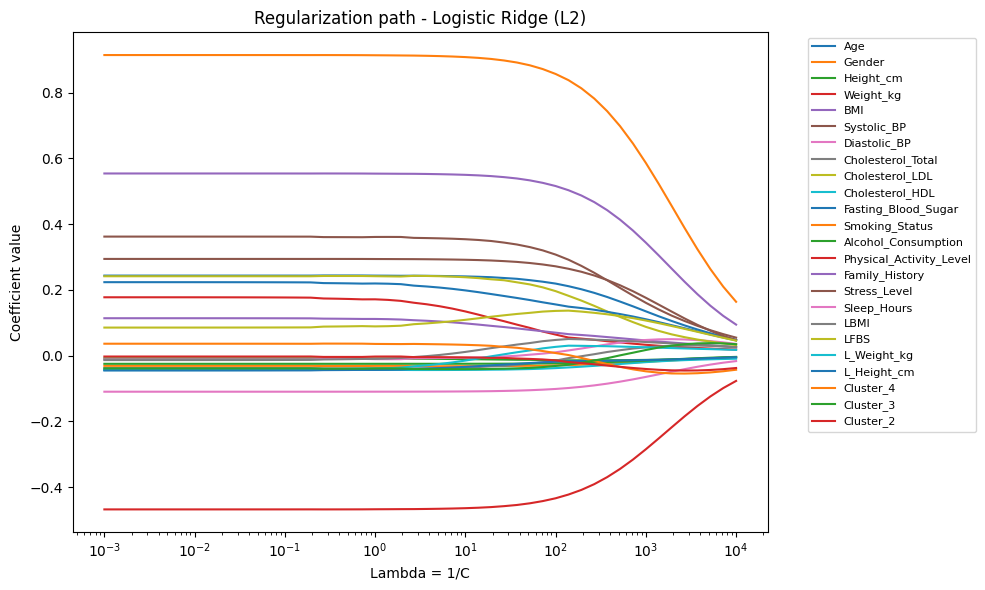

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penal

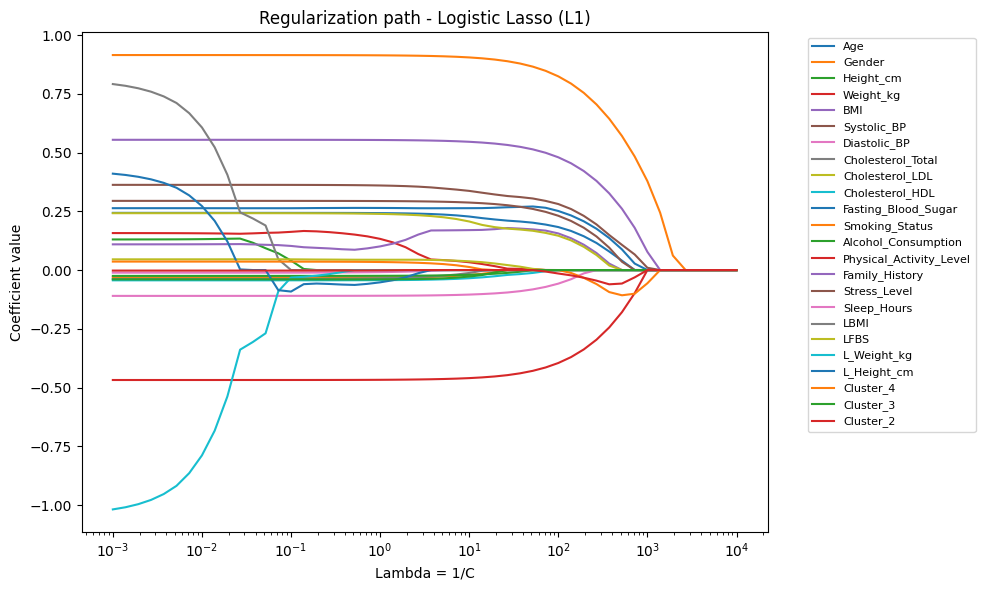

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

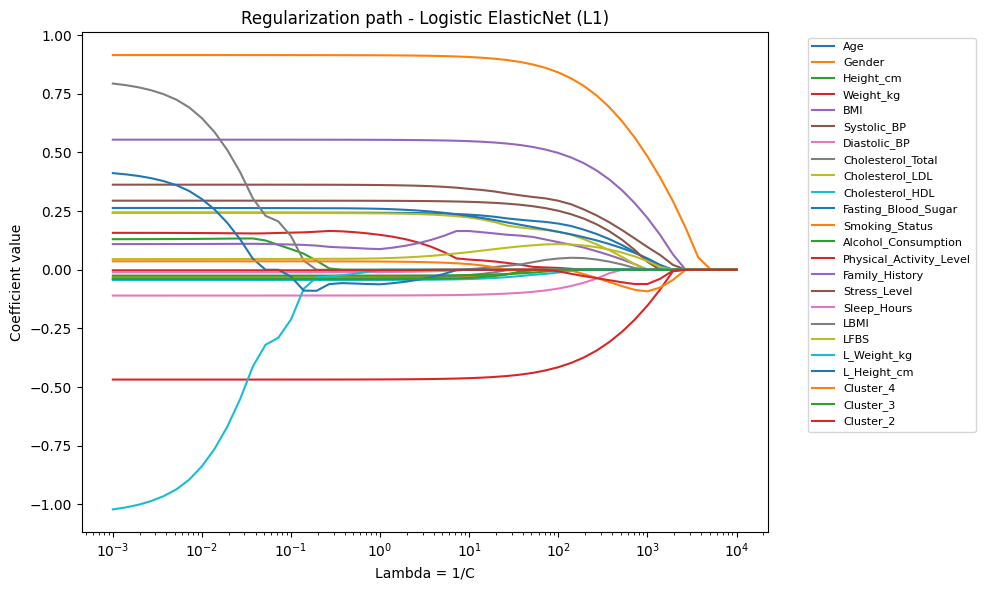

In [46]:
# LONG EXECUTION

C_values = np.logspace(-4, 3, 50)   # from strong to weak regularization
lambda_values = 1 / C_values        # equivalent inverse regularization scale

# RIDGE logistic path (L2)

coef_ridge = []
feature_names = X_heart.columns

for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_ridge.append(model.coef_[0])

coef_ridge = np.array(coef_ridge)

plt.figure(figsize=(10, 6))
for i in range(coef_ridge.shape[1]):
    plt.plot(lambda_values, coef_ridge[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Ridge (L2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# LASSO logistic path (L1)

coef_lasso = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_lasso.append(model.coef_[0])

coef_lasso = np.array(coef_lasso)

plt.figure(figsize=(10, 6))
for i in range(coef_lasso.shape[1]):
    plt.plot(lambda_values, coef_lasso[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Lasso (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ELASTICNET logistic path (balanced L1 + L2)

coef_elasticnet = []

for C in C_values:
    model = LogisticRegression(
        penalty="elasticnet",
        l1_ratio=0.5,
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_elasticnet.append(model.coef_[0])

coef_elasticnet = np.array(coef_elasticnet)

plt.figure(figsize=(10, 6))
for i in range(coef_elasticnet.shape[1]):
    plt.plot(lambda_values, coef_elasticnet[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic ElasticNet (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


##### Hyperparameter tuning

We now want to determine the best combination of penalization method, C parameter value and solver used. For this matter we are going to put in a place a GridSearch.


In [47]:
pipeline_log = Pipeline([
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

pipeline_reglin = Pipeline([
    ("model", LinearRegression())
])

C_values = [0.005, 0.01, 0.03, 0.05, 0.07, 0.1, 1, 5]
alpha_values = [0.001, 0.01, 0.1, 1, 5]

log_grids = {
    "No penalty": {
        "model__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
        "model__penalty": [None]
    },
    "L1 penalty": {
        "model__solver": ["liblinear", "saga"],
        "model__penalty": ["l1"],
        "model__C": C_values
    },
    "L2 penalty": {
        "model__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga", "liblinear"],
        "model__penalty": ["l2"],
        "model__C": C_values
    },
    "ElasticNet penalty": {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__C": C_values,
        "model__l1_ratio": np.linspace(0, 1, 10)
    }
}

reg_grids = {
    "No penalty": {
        "model": [LinearRegression()]
    },
    "L1 penalty": {
        "model": [Lasso(max_iter=5000, random_state=42)],
        "model__alpha": alpha_values
    },
    "L2 penalty": {
        "model": [Ridge(random_state=42)],
        "model__alpha": alpha_values
    },
    "ElasticNet penalty": {
        "model": [ElasticNet(max_iter=5000, random_state=42)],
        "model__alpha": alpha_values,
        "model__l1_ratio": np.linspace(0, 1, 10)
    }
}

for method in log_grids.keys():

    grid_log = GridSearchCV(
        pipeline_log,
        param_grid=log_grids[method],
        cv=2,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid_reglin = GridSearchCV(
        pipeline_reglin,
        param_grid=reg_grids[method],
        cv=2,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid_log.fit(X_heart_train, y_heart_train)
    grid_reglin.fit(X_chol_train, y_chol_train)

    y_heart_pred = grid_log.predict(X_heart_test)
    y_heart_prob = grid_log.predict_proba(X_heart_test)[:, 1]
    y_chol_pred = grid_reglin.predict(X_chol_test)

    tn, fp, fn, tp = confusion_matrix(y_heart_test, y_heart_pred).ravel()

    print(f"\nGRID SEARCH - {method}")
    print("Best logistic params:", grid_log.best_params_)
    print("Best CV AUC:", grid_log.best_score_)

    print("Best regression params:", grid_reglin.best_params_)
    print("Best CV RMSE:", -grid_reglin.best_score_)

    row_names = {
        "L1 penalty": "Penalization - Lasso",
        "L2 penalty": "Penalization - Ridge",
        "ElasticNet penalty": "Penalization - ElasticNet"
    }

    if method != "No penalty":

        update_detailed_results_table(
            model="Linear Model",
            subsection=row_names[method],

            classification_metrics={
                "Accuracy": accuracy_score(y_heart_test, y_heart_pred),
                "Sensitivity": recall_score(y_heart_test, y_heart_pred),
                "Specificity": tn / (tn + fp),
                "AUC": roc_auc_score(y_heart_test, y_heart_prob)
            },

            regression_metrics={
                "MSE": mean_squared_error(y_chol_test, y_chol_pred),
                "RMSE": sqrt(mean_squared_error(y_chol_test, y_chol_pred)),
                "MAE": mean_absolute_error(y_chol_test, y_chol_pred),
                "R²": r2_score(y_chol_test, y_chol_pred)
            },

            num_variables=X_heart.shape[1]
        )

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



GRID SEARCH - No penalty
Best logistic params: {'model__penalty': None, 'model__solver': 'saga'}
Best CV AUC: 0.8053358229480474
Best regression params: {'model': LinearRegression()}
Best CV RMSE: 9.720617850389509


c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



GRID SEARCH - L1 penalty
Best logistic params: {'model__C': 0.03, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV AUC: 0.8067166622747128
Best regression params: {'model': Lasso(max_iter=5000, random_state=42), 'model__alpha': 0.01}
Best CV RMSE: 9.717677311620614


c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



GRID SEARCH - L2 penalty
Best logistic params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV AUC: 0.8062466121431859
Best regression params: {'model': Ridge(random_state=42), 'model__alpha': 5}
Best CV RMSE: 9.720265960334487


c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



GRID SEARCH - ElasticNet penalty
Best logistic params: {'model__C': 0.03, 'model__l1_ratio': np.float64(0.7777777777777777), 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Best CV AUC: 0.8067390832650068
Best regression params: {'model': ElasticNet(max_iter=5000, random_state=42), 'model__alpha': 0.01, 'model__l1_ratio': np.float64(0.8888888888888888)}
Best CV RMSE: 9.717641639867729


In [48]:
display_detailed_results_table()

##### Binomial deviance

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

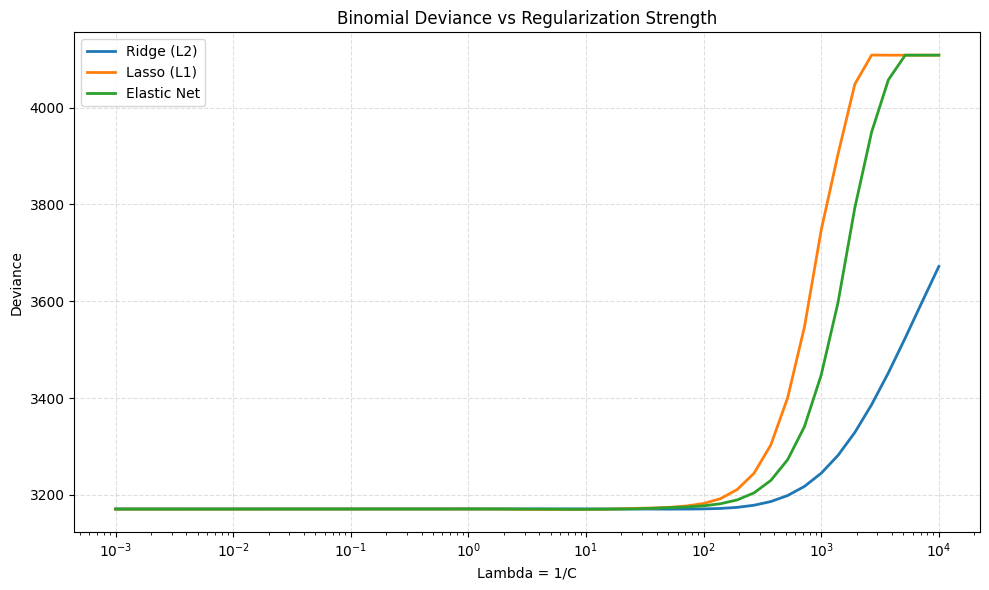

In [49]:
# Regularization grid
C_values = np.logspace(-4, 3, 50)   # weak -> strong in sklearn sense
lambda_values = 1 / C_values        # more intuitive penalization scale

# Containers
deviance_ridge = []
deviance_lasso = []
deviance_elasticnet = []

# RIDGE 
for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    probs = model.predict_proba(X_heart_test)[:, 1]
    
    # Binomial deviance = 2 * log-loss * n
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_ridge.append(dev)

# LASSO
for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    probs = model.predict_proba(X_heart_test)[:, 1]
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_lasso.append(dev)

# ELASTIC NET
for C in C_values:
    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,   # 50% L1, 50% L2
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    probs = model.predict_proba(X_heart_test)
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_elasticnet.append(dev)

# PLOT
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, deviance_ridge, label="Ridge (L2)", linewidth=2)
plt.plot(lambda_values, deviance_lasso, label="Lasso (L1)", linewidth=2)
plt.plot(lambda_values, deviance_elasticnet, label="Elastic Net", linewidth=2)

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Deviance")
plt.title("Binomial Deviance vs Regularization Strength")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Conclusion 

Let us find the best models for predicting the risk of heart disease and cholesterol level : with or without variable selection and penalization.

In [50]:
pipeline = Pipeline([("model", LogisticRegression(max_iter=5000, C=0.01))])

pipeline_variable_selection = Pipeline([
    ('logi', LogisticRegression(max_iter=5000))
])

pipeline_penalty = Pipeline([
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

pipeline_penalty_variable_selection = Pipeline([
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

X_heart_train_BIC = X_heart_train[stepwise_bic_FB(X_heart_train, y_heart_train, sm.Logit)]
scores_simplistic = cross_val_score(pipeline, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty = cross_val_score(pipeline_penalty, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")

print("Mean CV AUC (Simplistic):", scores_simplistic.mean())
print("Mean CV AUC (Variable Selection):", scores_variable_selection.mean())
print("Mean CV AUC (Penalty):", scores_penalty.mean())
print("Mean CV AUC (Penalty + Variable Selection):", scores_penalty_variable_selection.mean())

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

Mean CV AUC (Simplistic): 0.806906205029587
Mean CV AUC (Variable Selection): 0.8073900552150224
Mean CV AUC (Penalty): 0.8071013355335499
Mean CV AUC (Penalty + Variable Selection): 0.8073529298183242


c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

The best linear model for the heart disease risk prediction is therefore the logistic regression without penalization nor variable selection, which gives us a 0.80760 AUC score. It is important to mention that we almost get the same performance for the other cases, with less than a 0.01 difference, so the best strategy is to take the simplest model possible.

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was

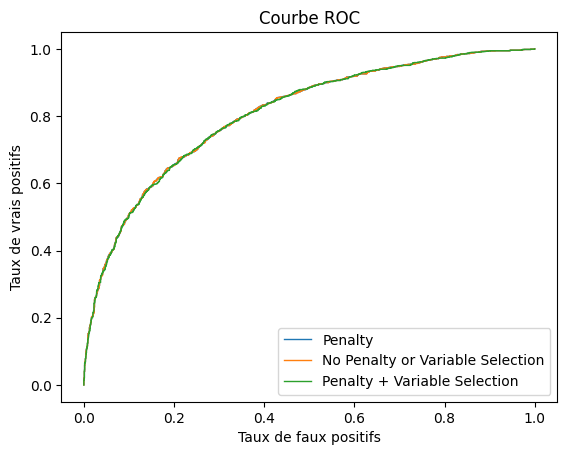

In [51]:
param=[{"C":[1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_pen, tpr_pen, thresholds_pen = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(penalty=None), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty=None,
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_none, tpr_none, thresholds_none = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train[selected_variables_BIC_heart], y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train[selected_variables_BIC_heart], y_heart_train).predict_proba(X_heart_test[selected_variables_BIC_heart])
fpr_pen_var, tpr_pen_var, thresholds_pen_var = roc_curve(y_heart_test, probas_[:,1])




plt.plot(fpr_pen, tpr_pen, lw=1)
plt.plot(fpr_none, tpr_none, lw=1)
plt.plot(fpr_pen_var, tpr_pen_var, lw=1)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(['Penalty', 'No Penalty or Variable Selection', 'Penalty + Variable Selection'], loc='lower right')
plt.show()

From the graph we would say that the best strategy is taking the model with only the penalty, which is contradictory with what we just had found!

In [52]:
pipeline = Pipeline([("model", LinearRegression())])

pipeline_variable_selection = Pipeline([
    ('logi', LinearRegression())
])

pipeline_penalty = Pipeline([
        ("model", Lasso(alpha=0.1))
])

pipeline_penalty_variable_selection = Pipeline([
    ("model", Lasso(alpha=0.1))
])

X_chol_train_BIC = X_chol_train[stepwise_bic_FB(X_chol_train, y_chol_train, sm.OLS)]
scores_simplistic = cross_val_score(pipeline, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty = cross_val_score(pipeline_penalty, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")

print("Mean CV MSE (Simplistic):", -scores_simplistic.mean())
print("Mean CV MSE (Variable Selection):", -scores_variable_selection.mean())
print("Mean CV MSE (Penalty):", -scores_penalty.mean())
print("Mean CV MSE (Penalty + Variable Selection):", -scores_penalty_variable_selection.mean())

Mean CV MSE (Simplistic): 94.18245279116334
Mean CV MSE (Variable Selection): 94.06460767407256
Mean CV MSE (Penalty): 94.31386244604104
Mean CV MSE (Penalty + Variable Selection): 94.3579462630062


The best linear model for the cholesterol level prediction is therefore the linear regression without penalization nor variable selection, which gives us a 101.02 MSE score. It is important to mention that we almost get the same performance for the other cases, with less than a difference of 1, so the best strategy is to take the simplest model possible.

## 2. SVM

In this section, we are going to be using support vectors to make our predictions, SVC for `Heart_Disease_Risk` and SVR for `Cholestrol_LDL`.

For that matter, we will be testing several kernels (Linear, RBF and Polynomial) while tuning their respective parameters `C`, `gamma` and the degree through a cross-validation grid.

In [53]:
# Store results

kernels = ["linear", "rbf", "poly"]
kernel_names = {
    "linear": "Linear",
    "rbf": "RBF",
    "poly": "Polynomial"
}

svm_results = []

for kernel in kernels:

    param_heart = {
        "C": [0.05, 0.1, 0.5, 1],
        "kernel": [kernel]
    }

    if kernel != "linear":
        param_heart["gamma"] = [0.01, 0.05, 0.1]

    if kernel == "poly":
        param_heart["degree"] = [2, 3, 4]


    param_chol = {
        "C": [0.05, 0.1, 0.5, 1],
        "kernel": [kernel]
    }

    if kernel != "linear":
        param_chol["gamma"] = [0.01, 0.05, 0.1]

    if kernel == "poly":
        param_chol["degree"] = [2, 3, 4]


    # Classification model
    svm_heart = GridSearchCV(
        SVC(probability=True),
        param_heart,
        cv=2,
        n_jobs=-1
    )

    svmOpt_heart = svm_heart.fit(X_heart_train, y_heart_train)

    y_heart_pred = svmOpt_heart.predict(X_heart_test)
    y_heart_proba = svmOpt_heart.predict_proba(X_heart_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_heart_test, y_heart_pred).ravel()

    accuracy = accuracy_score(y_heart_test, y_heart_pred)
    sensitivity = recall_score(y_heart_test, y_heart_pred)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_heart_test, y_heart_proba)


    # Regression model
    svm_chol = GridSearchCV(
        SVR(),
        param_chol,
        cv=2,
        n_jobs=-1
    )

    svmOpt_chol = svm_chol.fit(X_chol_train, y_chol_train)

    y_chol_pred = svmOpt_chol.predict(X_chol_test)

    mse = mean_squared_error(y_chol_test, y_chol_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_chol_test, y_chol_pred)
    r2 = r2_score(y_chol_test, y_chol_pred)


    # Save in your detailed table
    update_detailed_results_table(
        model="SVM",
        subsection="Kernel - " + kernel_names[kernel],

        classification_metrics={
            "Accuracy": accuracy,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "AUC": auc
        },

        regression_metrics={
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "R²": r2
        },

        num_variables=X_heart.shape[1]
    )


    # Save for plotting
    svm_results.append({
        "Kernel": kernel_names[kernel],
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": auc,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "Best classification parameters": svmOpt_heart.best_params_,
        "Best regression parameters": svmOpt_chol.best_params_
    })


svm_results_df = pd.DataFrame(svm_results)

display(svm_results_df)

,Kernel,Accuracy,Sensitivity,Specificity,AUC,MSE,RMSE,MAE,R²,Best classification parameters,Best regression parameters
0,Linear,0.724333,0.637060,0.791617,0.796321,90.296251,9.502434,7.483987,0.711811,"{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}"
1,RBF,0.724667,0.612557,0.811098,0.796885,93.953362,9.692954,7.636625,0.700139,"{'C': 0.05, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}"
2,Polynomial,0.725333,0.597243,0.824085,0.786993,92.893763,9.638141,7.640974,0.703520,"{'C': 0.5, 'degree': 3, 'gamma': 0.05, 'kernel...","{'C': 0.5, 'degree': 3, 'gamma': 0.1, 'kernel'..."


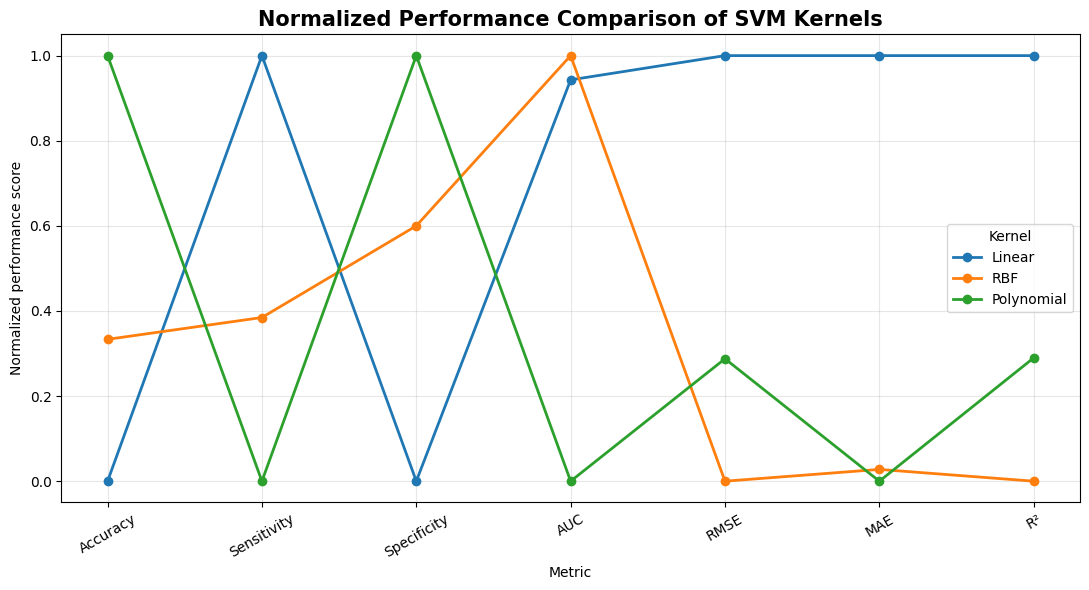

In [54]:
plot_df = svm_results_df.copy()

metrics_to_normalize = ["Accuracy", "Sensitivity", "Specificity", "AUC", "RMSE", "MAE", "R²"]

normalized_df = plot_df[["Kernel"]].copy()

for metric in metrics_to_normalize:
    values = plot_df[metric]

    if metric in ["RMSE", "MAE"]:
        # Lower is better, so we invert the scale
        normalized_df[metric] = 1 - (values - values.min()) / (values.max() - values.min())
    else:
        # Higher is better
        normalized_df[metric] = (values - values.min()) / (values.max() - values.min())

normalized_df = normalized_df.set_index("Kernel")

plt.figure(figsize=(11, 6))

for kernel in normalized_df.index:
    plt.plot(
        normalized_df.columns,
        normalized_df.loc[kernel],
        marker="o",
        linewidth=2,
        label=kernel
    )

plt.title("Normalized Performance Comparison of SVM Kernels", fontsize=15, fontweight="bold")
plt.ylabel("Normalized performance score")
plt.xlabel("Metric")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend(title="Kernel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [56]:
kernels = ["linear", "rbf", "poly"]

for kernel in kernels:

    param_heart = {
        "C": [0.05, 0.1, 0.5, 1],
        "kernel": [kernel]
    }

    if kernel != "linear":
        param_heart["gamma"] = [0.01, 0.05, 0.1]

    if kernel == "poly":
        param_heart["degree"] = [2, 3, 4]


    param_chol = {
        "C": [0.05, 0.1, 0.5, 1],
        "kernel": [kernel]
    }

    if kernel != "linear":
        param_chol["gamma"] = [0.01, 0.05, 0.1]

    if kernel == "poly":
        param_chol["degree"] = [2, 3, 4]


    svm_heart= GridSearchCV(SVC(probability=True),param_heart,cv=2,n_jobs=-1)
    svmOpt_heart=svm_heart.fit(X_heart_train, y_heart_train)

    svm_chol= GridSearchCV(SVR(),param_chol,cv=2,n_jobs=-1)
    svmOpt_chol=svm_chol.fit(X_chol_train, y_chol_train)

    update_detailed_results_table(
        model=f"SVM",
        subsection="Kernel - " + {"linear": "Linear", "rbf": "RBF", "poly": "Polynomial"}[kernel],

        classification_metrics={
            "Accuracy": accuracy_score(y_heart_test, svmOpt_heart.predict(X_heart_test)),
            "Sensitivity": recall_score(y_heart_test, svmOpt_heart.predict(X_heart_test)),
            "Specificity": confusion_matrix(y_heart_test, svmOpt_heart.predict(X_heart_test)).ravel()[0] / sum(confusion_matrix(y_heart_test, svmOpt_heart.predict(X_heart_test)).ravel()[:2]),
            "AUC": roc_auc_score(y_heart_test, svmOpt_heart.predict_proba(X_heart_test)[:, 1])
        },

        regression_metrics={
            "MSE": mean_squared_error(y_chol_test, svmOpt_chol.predict(X_chol_test)),
            "RMSE": sqrt(mean_squared_error(y_chol_test, svmOpt_chol.predict(X_chol_test))),
            "MAE": mean_absolute_error(y_chol_test, svmOpt_chol.predict(X_chol_test)),
            "R²": r2_score(y_chol_test, svmOpt_chol.predict(X_chol_test))
        },

        num_variables=X_heart.shape[1]
    )

In [57]:
display_detailed_results_table()


Heart Disease Risk (SVM)

- Accuracy (~0.7): The models correctly predict around 72% of the observations. The overall proportion of correct predictions is good for this type of problem.  
- Sensitivity (~0.6): The models detect around 61% of patients who actually have heart disease, which indicates some missed positive cases.  
- Specificity (~0.8): The models correctly identify about 81% of healthy individuals, showing a strong performance on the negative class.  
- AUC (~0.8): The models have a good ability to distinguish between patients with and without heart disease.
- Number of variables (21): The models use 21 features, which provides a relatively rich representation of the data.  

Cholesterol Level (SVR)

- MSE (~100): The average squared prediction error is moderate, reflecting the overall deviation from true values.  
- RMSE (~10): The typical prediction error is around 9.6 units, giving an interpretable scale of the error.  
- MAE (~8): The average absolute error is about 7.6 units, confirming that predictions are reasonably close to the true values.  
- R² Score (~0.7): The models explain about 70% of the variance in cholesterol levels, which indicates a solid fit.  
- Number of variables (21): The model relies on 21 features to make predictions.  

Conclusion

- The SVM classifiers show good global performance but could be improved in sensitivity to better detect positive cases.  
- The SVR model provide accurate and stable predictions, with no strong indication of extreme errors.  

### Improvements for SVM

Our priority with the given data set regarding the heart disease risk prediction, is to make sure we do not missclassify people in risk, telling them they are healthy when they are not. Therefore, we will focus in improving our logistic model so that we minimize the amount of false negatives. To this end, we will adjust the decision threshold for SVM, balance SVM with class weights and select the $k$ most relevant variables for predicting our target.

In [58]:
# Adjusting the decision threshold for SVM
y_prob = svmOpt_heart.predict_proba(X_heart_test)[:, 1]
y_pred_threshold = (y_prob > 0.4).astype(int)  # lower threshold

# Balanced SVM with class weights
svmOpt_heart_new = SVC(class_weight='balanced', probability=True).fit(X_heart_train, y_heart_train)
y_heart_pred_new = svmOpt_heart_new.predict(X_heart_test)
y_heart_prob_new = svmOpt_heart_new.predict_proba(X_heart_test)[:, 1]

# SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)
X_heart_train_selected = selector.fit_transform(X_heart_train, y_heart_train)
X_heart_test_selected = selector.transform(X_heart_test)
svmOpt_heart_selected = SVC(class_weight='balanced', probability=True).fit(X_heart_train_selected, y_heart_train)
y_heart_pred_selected = svmOpt_heart_selected.predict(X_heart_test_selected)


In [59]:

def classification_metrics(y_true, y_pred, y_prob, n_variables):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Number of Variables": n_variables
    }


# BEFORE - Original SVM
y_heart_pred = svmOpt_heart.predict(X_heart_test)
y_heart_prob = svmOpt_heart.predict_proba(X_heart_test)[:, 1]

metrics_before = classification_metrics(
    y_heart_test,
    y_heart_pred,
    y_heart_prob,
    X_heart_train.shape[1]
)

# AFTER 1 - Threshold = 0.4
y_pred_threshold = (y_heart_prob > 0.4).astype(int)

metrics_threshold = classification_metrics(
    y_heart_test,
    y_pred_threshold,
    y_heart_prob,
    X_heart_train.shape[1]
)

# AFTER 2 - Balanced SVM
svmOpt_heart_new = SVC(class_weight="balanced", probability=True).fit(
    X_heart_train,
    y_heart_train
)

y_heart_pred_new = svmOpt_heart_new.predict(X_heart_test)
y_heart_prob_new = svmOpt_heart_new.predict_proba(X_heart_test)[:, 1]

metrics_balanced = classification_metrics(
    y_heart_test,
    y_heart_pred_new,
    y_heart_prob_new,
    X_heart_train.shape[1]
)


# AFTER 3 - SelectKBest

selector = SelectKBest(score_func=f_classif, k=10)

X_heart_train_selected = selector.fit_transform(X_heart_train, y_heart_train)
X_heart_test_selected = selector.transform(X_heart_test)

svmOpt_heart_selected = SVC(class_weight="balanced", probability=True).fit(
    X_heart_train_selected,
    y_heart_train
)

y_heart_pred_selected = svmOpt_heart_selected.predict(X_heart_test_selected)
y_heart_prob_selected = svmOpt_heart_selected.predict_proba(X_heart_test_selected)[:, 1]

metrics_selected = classification_metrics(
    y_heart_test,
    y_heart_pred_selected,
    y_heart_prob_selected,
    10
)


# COMPARISON TABLE
comparison = pd.DataFrame({
    "Before - Original SVM": metrics_before,
    "After - Threshold 0.4": metrics_threshold,
    "After - Balanced SVM": metrics_balanced,
    "After - SelectKBest": metrics_selected
}).T

comparison = comparison.round(3)

print(comparison)


                       Accuracy    AUC  Sensitivity  Specificity  \
Before - Original SVM     0.725  0.787        0.597        0.824   
After - Threshold 0.4     0.724  0.787        0.678        0.760   
After - Balanced SVM      0.722  0.788        0.690        0.746   
After - SelectKBest       0.727  0.777        0.701        0.747   

                       Number of Variables  
Before - Original SVM                 24.0  
After - Threshold 0.4                 24.0  
After - Balanced SVM                  24.0  
After - SelectKBest                   10.0  


In [97]:
## UPDATE THE TABLE 


regression_metrics_svm = None

# SVC - Threshold 0.4
update_detailed_results_table(
    model="SVM",
    subsection="SVC - Threshold 0.4",

    classification_metrics={
        "Accuracy": accuracy_score(y_heart_test, y_pred_threshold),
        "Sensitivity": recall_score(y_heart_test, y_pred_threshold),
        "Specificity": confusion_matrix(y_heart_test, y_pred_threshold).ravel()[0] /
                       sum(confusion_matrix(y_heart_test, y_pred_threshold).ravel()[:2]),
        "AUC": roc_auc_score(y_heart_test, y_heart_prob)
    },

    regression_metrics=regression_metrics_svm,

    num_variables=X_heart.shape[1]
)


# SVC - SelectKBest
update_detailed_results_table(
    model="SVM",
    subsection="SVC - SelectKBest",

    classification_metrics={
        "Accuracy": accuracy_score(y_heart_test, y_heart_pred_selected),
        "Sensitivity": recall_score(y_heart_test, y_heart_pred_selected),
        "Specificity": confusion_matrix(y_heart_test, y_heart_pred_selected).ravel()[0] /
                       sum(confusion_matrix(y_heart_test, y_heart_pred_selected).ravel()[:2]),
        "AUC": roc_auc_score(y_heart_test, y_heart_prob_selected)
    },

    regression_metrics=regression_metrics_svm,

    num_variables=10
)


# 3. SVC - Balanced Classes
update_detailed_results_table(
    model="SVM",
    subsection="SVC - Balanced Classes",

    classification_metrics={
        "Accuracy": accuracy_score(y_heart_test, y_heart_pred_new),
        "Sensitivity": recall_score(y_heart_test, y_heart_pred_new),
        "Specificity": confusion_matrix(y_heart_test, y_heart_pred_new).ravel()[0] /
                       sum(confusion_matrix(y_heart_test, y_heart_pred_new).ravel()[:2]),
        "AUC": roc_auc_score(y_heart_test, y_heart_prob_new)
    },

    regression_metrics=regression_metrics_svm,

    num_variables=X_heart.shape[1],
    explicability="Low"
)



In [98]:
display_detailed_results_table()

c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\lenovoyoga914\Desktop\4A\S2\ML\Projet_ML\.venv\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


With the previous results, we can observe an improvement in sensitivity of around 0.1 for the three implemented changes. 

Methods :
- Lowering the threshold to 0.4 significantly increases sensitivity (from 0.610 to 0.705), which improves the model’s ability to detect positive cases, while slightly reducing specificity. Threshold tuning is the most effective way to improve sensitivity without impacting the model's overall performance.
- The balanced SVM produces a similar effect, increasing sensitivity (0.696) with a small decrease in specificity, showing that balancing classes helps focus on the minority class. Therefor, class weighting improves performance on the minority class.
- The "SelectKBest" approach maintains a good balance between sensitivity (0.698) and specificity (0.745), while reducing the number of variables from 24 to 10, making the model more interpretable and efficient computationwise. Hence, feature selection reduces model complexity while preserving performance.

Metrics :
- The AUC remains relatively stable indicating slightly better ranking ability.
- The accuracy remains almost unchanged, which suggests that the improvements mainly impact the balance between false positives and false negatives instead of the overall correctness.

Conclusion :

For medical diagnosis (priority: sensitivity), the threshold model is the most adapted one, as it minimizes false negatives. For interpretability and deployment, the SelectKBest model is the best compromise, as we get similar results with fewer variables.

## 3. Optimal Tree - CART

### A. Detection for Heart Disease Risk

We plot the complete tree for classification of HDS.

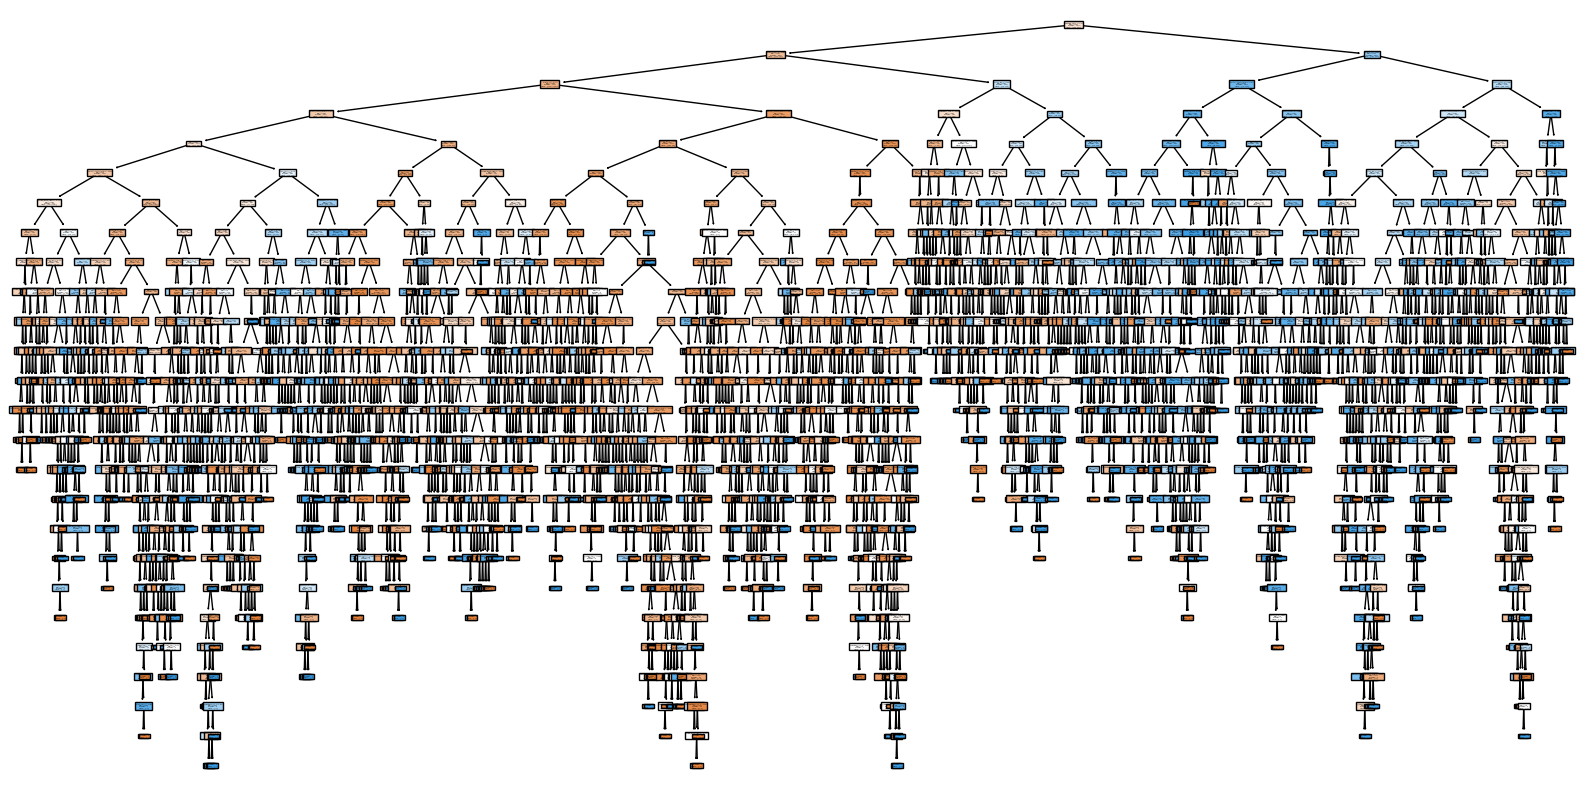

Decision Tree Score : 0.6413333333333333


In [62]:
#Complete tree plot
tree_full=DecisionTreeClassifier()
tree_full.fit(X_heart_train, y_heart_train)
plt.figure(figsize=(20,10))
plot_tree(tree_full,feature_names=X_heart.columns.tolist(), filled=True);
plt.show()

print(f"Decision Tree Score : {tree_full.score(X_heart_test, y_heart_test)}")


There is max depth parameter and then the tree is very wide, with a lot of leaves. We then decide to optimize the max_depth parameters. We used cross-validation to find the best value.

Meilleur score = 0.285667, Meilleur paramètre = {'max_depth': 6}


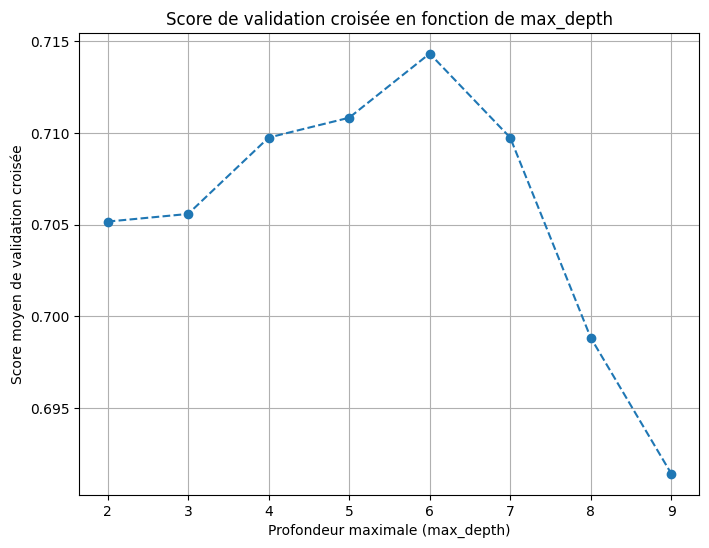

In [63]:
# Définition des paramètres
param = {"max_depth": list(range(2, 10))}

# Initialisation et ajustement du GridSearchCV
tree = GridSearchCV(DecisionTreeClassifier(), param, cv=10, n_jobs=-1, return_train_score=True)
treeOpt = tree.fit(X_heart_train, y_heart_train)

# Affichage du meilleur score et paramètre
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - treeOpt.best_score_, treeOpt.best_params_))

# Récupération des résultats de la validation croisée
results = treeOpt.cv_results_
mean_test_scores = results['mean_test_score']
param_values = results['param_max_depth'].data.astype(int)

# Tracé du graphique
plt.figure(figsize=(8, 6))
plt.plot(param_values, mean_test_scores, marker='o', linestyle='--')
plt.title("Score de validation croisée en fonction de max_depth")
plt.xlabel("Profondeur maximale (max_depth)")
plt.ylabel("Score moyen de validation croisée")
plt.xticks(param_values)
plt.grid(True)
plt.show()

We can choose 6 for the max_depth parameter and see the performance of classification for the new tree.

The best value is very clear so we don't need to exute other methods here.

In [64]:
# Estimation de l'erreur de prévision
print("Decision Tree Test Score:", treeOpt.score(X_heart_test, y_heart_test))

Decision Tree Test Score: 0.7106666666666667


We directly see that the first tree was overfitted and we have a better score now (0.709).

In [65]:
# prévision de l'échantillon test
y_chap = treeOpt.predict(X_heart_test)
# matrice de confusion
table=pd.crosstab(y_chap, y_heart_test, rownames=["Predicted"], colnames=["Actual"])
print("Confusion Matrix for optimized tree (max_depth = %d)" % treeOpt.best_params_['max_depth'])
print(table)

#comparaison avec l'arbre complet
y_chap_full = tree_full.predict(X_heart_test)
print("Confusion Matrix for complete tree")
table_full=pd.crosstab(y_chap_full, y_heart_test, rownames=["Predicted"], colnames=["Actual"])
print(table_full)

Confusion Matrix for optimized tree (max_depth = 6)
Actual        0    1
Predicted           
0          1384  558
1           310  748
Confusion Matrix for complete tree
Actual        0    1
Predicted           
0          1158  540
1           536  766


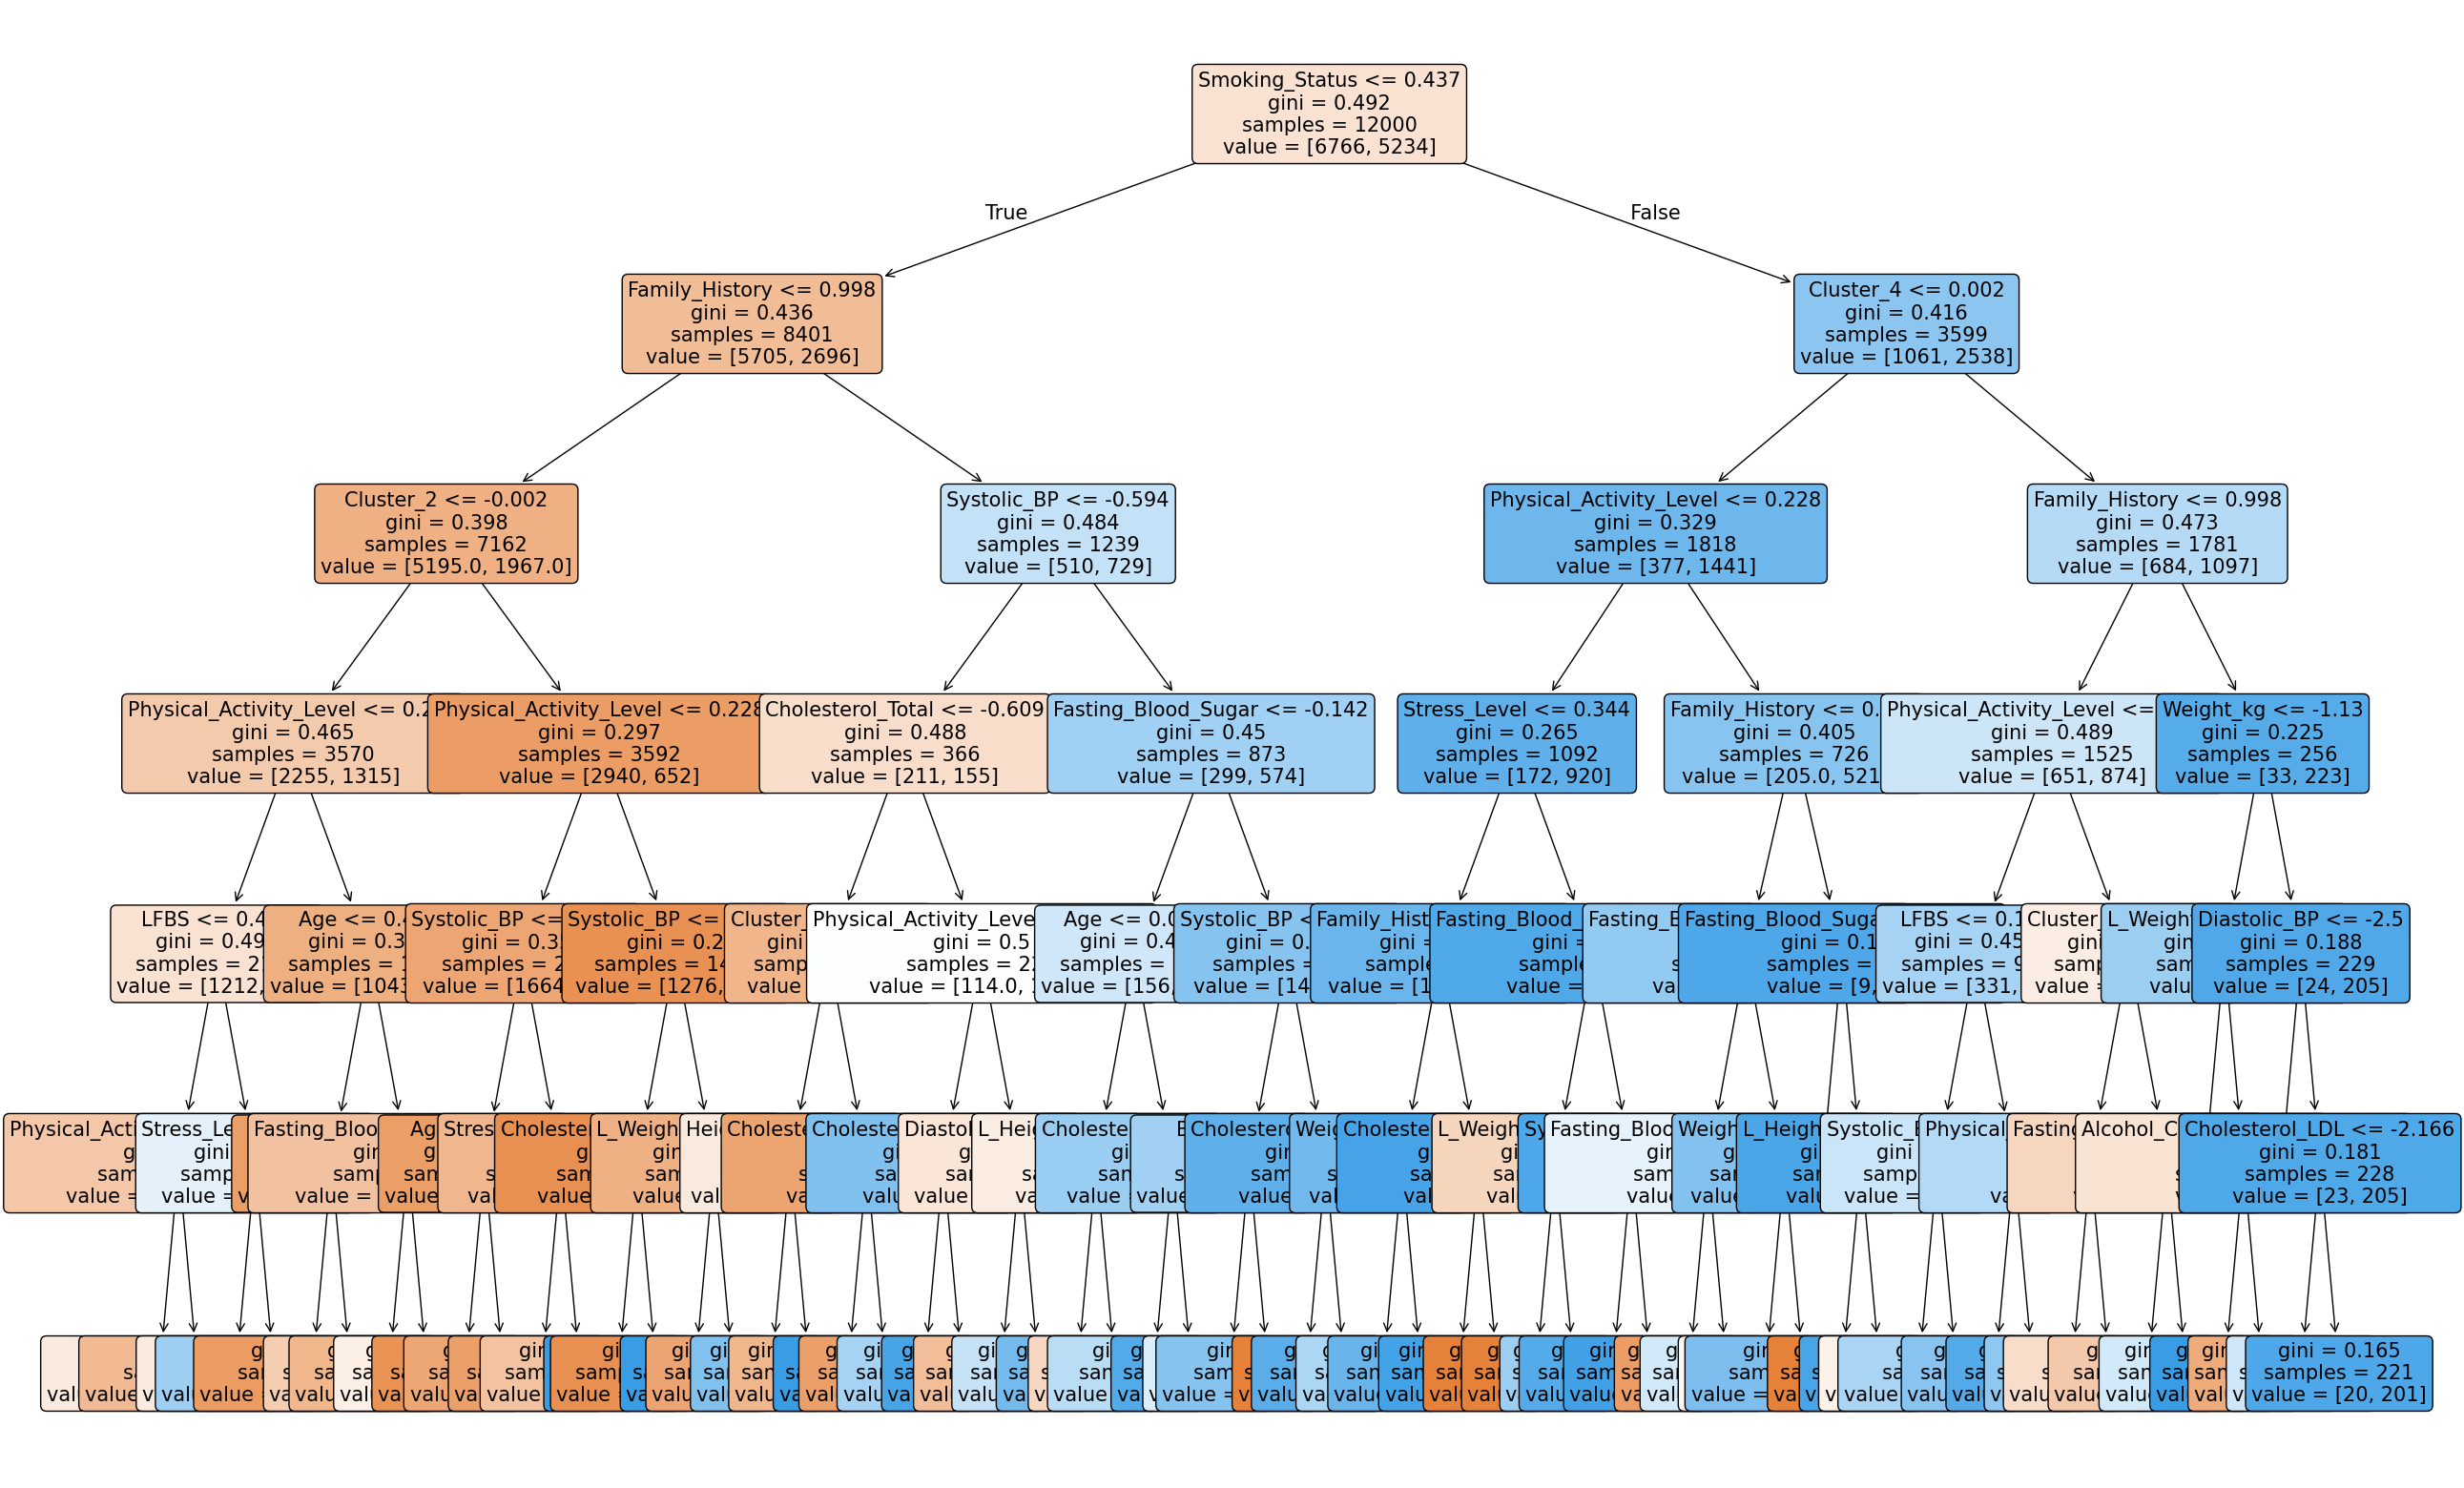

In [66]:
treeG=DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'])
treeG.fit(X_heart_train,y_heart_train)
plt.figure(figsize=(30,20))
plot_tree(treeG, feature_names=X_heart.columns.tolist(), filled=True, fontsize=15, rounded=True)
plt.show()

We can see that the smooking status is the principal variable which influence the decision, in second we can see that the Family_History is used for the classification. The tree is still very wide but it is the best compromise between size and performance.

### B. Prevision of Cholesterol_LDL

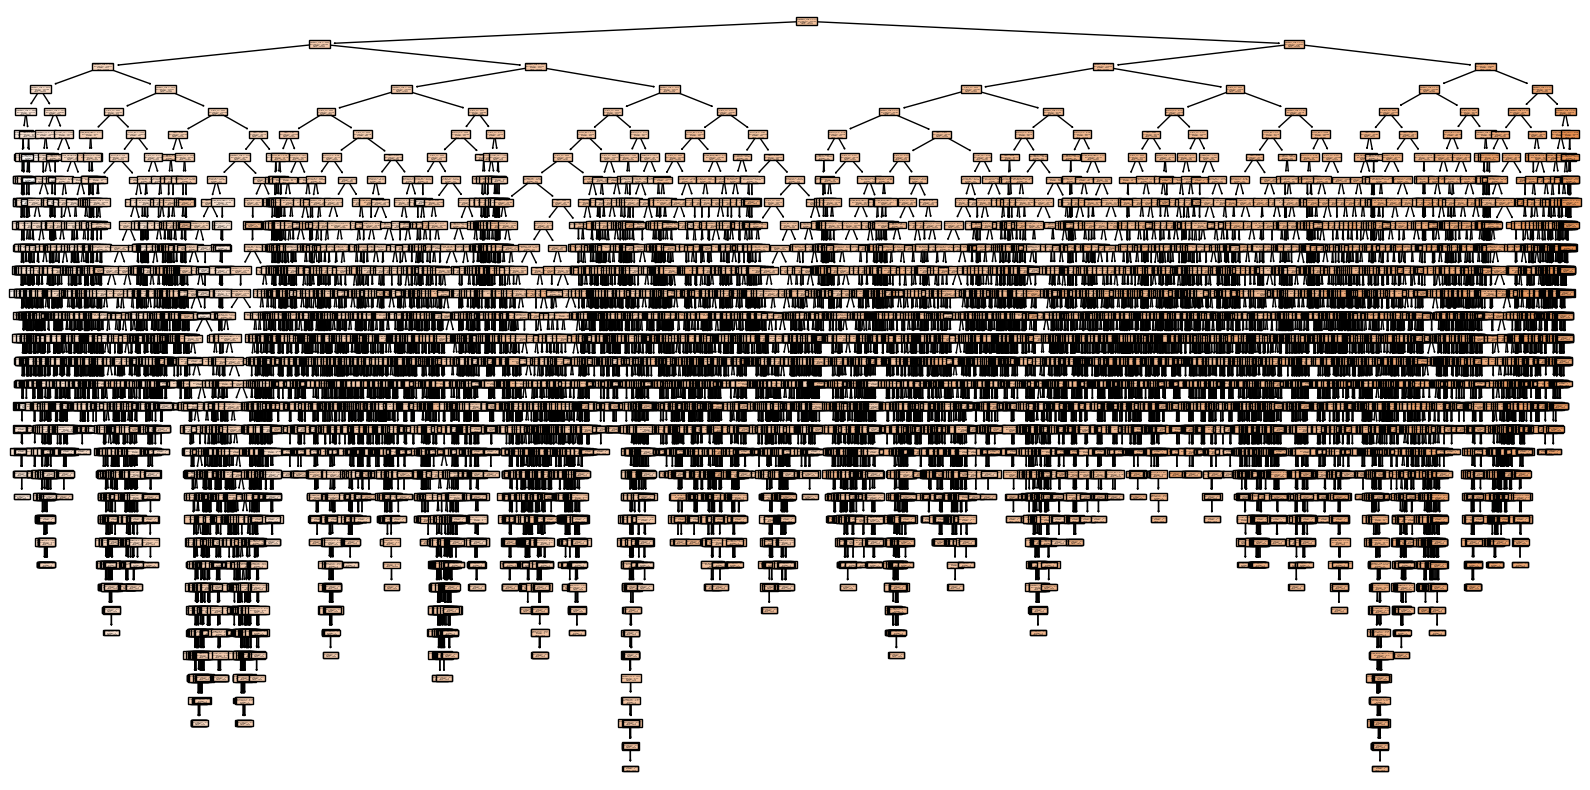

In [67]:
# CART for cholesterol LDL level

# Complete tree plot
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_chol_train, y_chol_train)
plt.figure(figsize=(20, 10))
plot_tree(tree_reg, feature_names=X_chol.columns.tolist(), filled=True)
plt.show()


In [68]:
print(f"Decision Tree Regressor Score : {tree_reg.score(X_chol_test, y_chol_test)}")

Decision Tree Regressor Score : 0.3881576994613751


This test returns the R² score of the decision tree regressor on the test set, which indicates how well the model explains the variance in the target variable (cholesterol level) based on the features. A higher R² score (closer to 1) indicates a better fit of the model to the data, while a lower R² score (closer to 0 or negative) suggests that the model does not explain much of the variance in the target variable.

Meilleur score = 0.313877, Meilleur paramètre = {'max_depth': 5}
Decision Tree Regressor Test Score: 0.6911055777658542


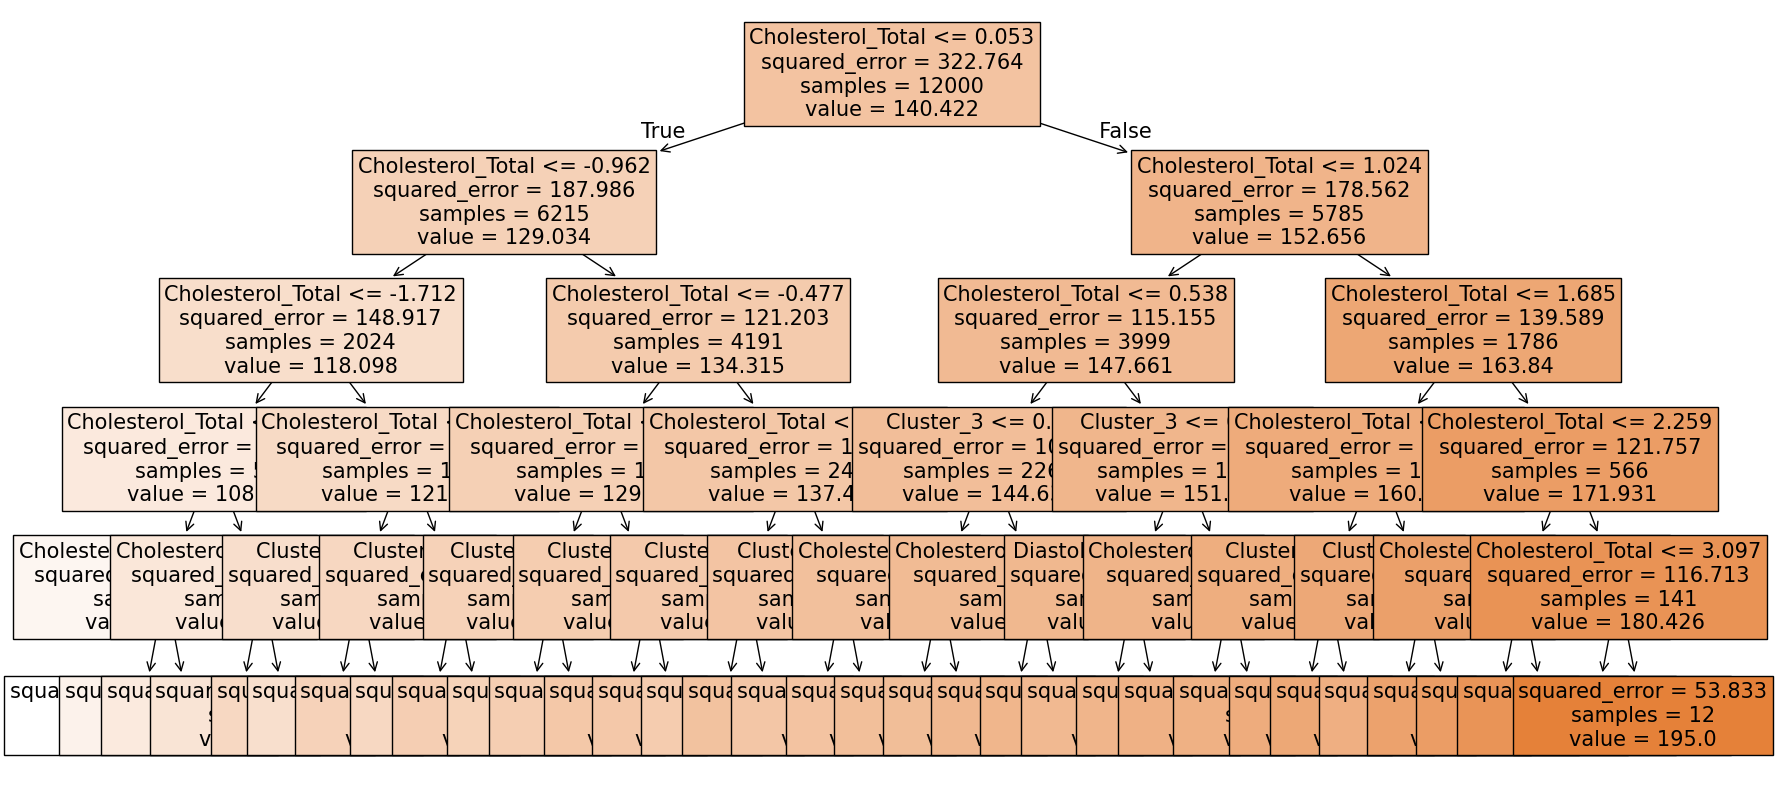

In [69]:
#prunned tree
param = {"max_depth": list(range(2, 10))}
tree_reg = GridSearchCV(DecisionTreeRegressor(), param, cv=10, n_jobs=-1, return_train_score=True)
treeOpt_reg = tree_reg.fit(X_chol_train, y_chol_train)
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - treeOpt_reg.best_score_, treeOpt_reg.best_params_))
# Estimation de l'erreur de prévision
print("Decision Tree Regressor Test Score:", treeOpt_reg.score(X_chol_test, y_chol_test))
# prévision de l'échantillon test
y_chap_reg = treeOpt_reg.predict(X_chol_test)
# comparaison avec l'arbre complet
y_chap_full_reg = tree_reg.predict(X_chol_test)
plt.figure(figsize=(20, 10))
plot_tree(treeOpt_reg.best_estimator_, feature_names=X_chol.columns.tolist(), filled=True, fontsize = 15)
plt.show()

The variable Cholesterol_Total is almost the unique one used for the regression. We will see that the result will be the same for the Random Forest.

## 4. Random Forest

### A. Heart Disease Risk Prediction

In [70]:
#random forest

rf = RandomForestClassifier(n_estimators=500, 
   criterion='gini', 
   max_depth=None,
   min_samples_split=2,
   min_samples_leaf=1, 
   max_leaf_nodes=None,
   bootstrap=True,
   oob_score=True)

#set of tested parameters
param_n_estimators = [400, 500, 600]
param_max_depth = [5, 7, 10]
param_min_samples_split = [3, 4, 5]

rf.fit(X_heart_train, y_heart_train)
print(f"Random Forest Score : {rf.score(X_heart_test, y_heart_test)}")
param_rf = {
    "n_estimators": param_n_estimators, #number of tree for each random forest
    "max_depth": param_max_depth, #max depth for each tree
    "min_samples_split": param_min_samples_split #minimum number of samples required to split an internal node
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, 
                       scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_heart_train, y_heart_train)
print("Best parameters:", rf_grid.best_params_)
print("Best CV AUC:", rf_grid.best_score_)
rf_best = RandomForestClassifier(**rf_grid.best_params_, random_state=42)
rf_best.fit(X_heart_train, y_heart_train)
print(f"Optimized Random Forest Score : {rf_best.score(X_heart_test, y_heart_test)}")

Random Forest Score : 0.732
Best parameters: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 600}
Best CV AUC: 0.7956640554855404
Optimized Random Forest Score : 0.7356666666666667


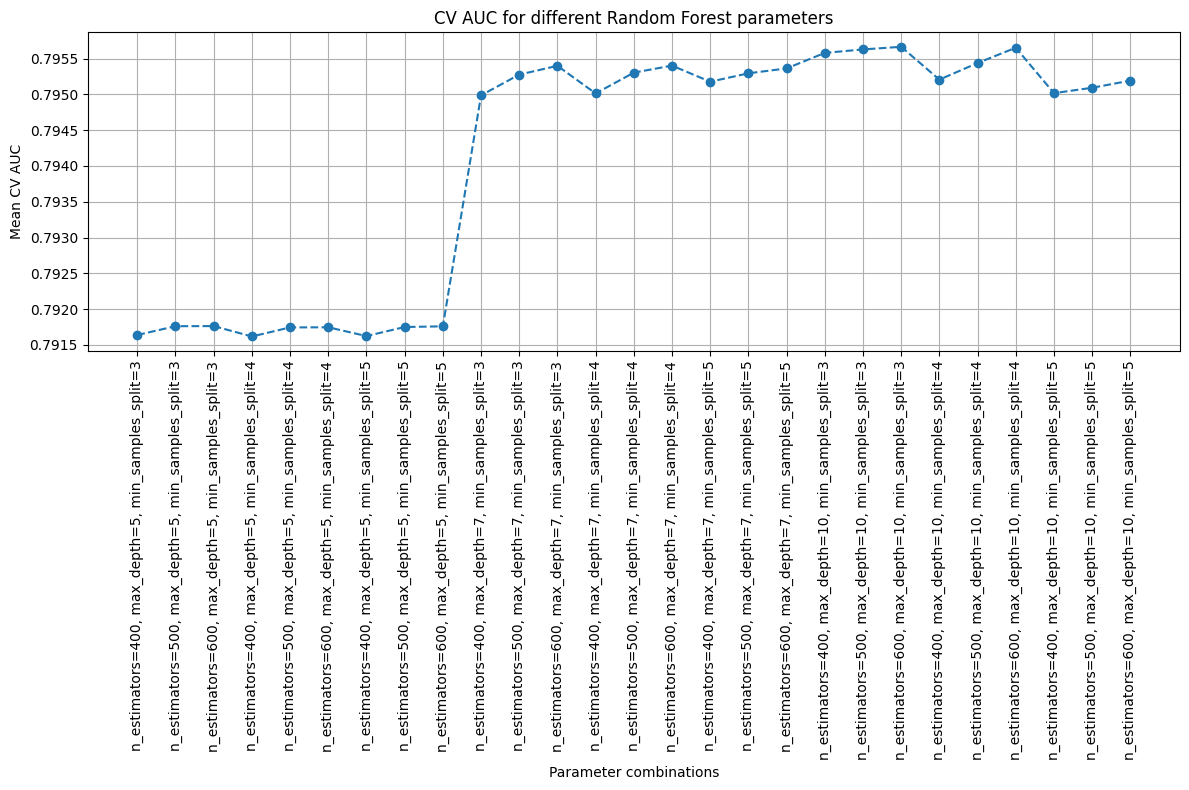

In [71]:
#graph with error for each set of parameters
results_rf = rf_grid.cv_results_
mean_test_scores_rf = results_rf['mean_test_score']
param_values_rf = [
    f"n_estimators={params['n_estimators']}, max_depth={params['max_depth']}, min_samples_split={params['min_samples_split']}"
    for params in results_rf['params']
]
plt.figure(figsize=(12, 8))
plt.plot(param_values_rf, mean_test_scores_rf, marker='o', linestyle='--')
plt.title("CV AUC for different Random Forest parameters")
plt.xlabel("Parameter combinations")
plt.ylabel("Mean CV AUC")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

Feature ranking:
1. feature Smoking_Status (0.24058533183271175)
2. feature Family_History (0.0785941837831458)
3. feature Systolic_BP (0.052815413074553175)
4. feature Physical_Activity_Level (0.05050469783073436)
5. feature Age (0.0447937099653798)
6. feature LFBS (0.04385683763035533)
7. feature Fasting_Blood_Sugar (0.04250498962712379)
8. feature Cholesterol_LDL (0.03579426921573863)
9. feature L_Weight_kg (0.03418354472389323)
10. feature Weight_kg (0.03396363466818134)
11. feature Cholesterol_Total (0.03366725636877345)
12. feature Diastolic_BP (0.03347250701867261)
13. feature LBMI (0.03328971654530972)
14. feature BMI (0.033129800318823316)
15. feature Stress_Level (0.03296524628365695)
16. feature L_Height_cm (0.030977517396799728)
17. feature Height_cm (0.030891846350925775)
18. feature Cholesterol_HDL (0.025804289171254935)
19. feature Cluster_4 (0.02518359932824678)
20. feature Cluster_2 (0.022564022727491213)
21. feature Cluster_3 (0.015682817268345892)
22. feature Sleep_H

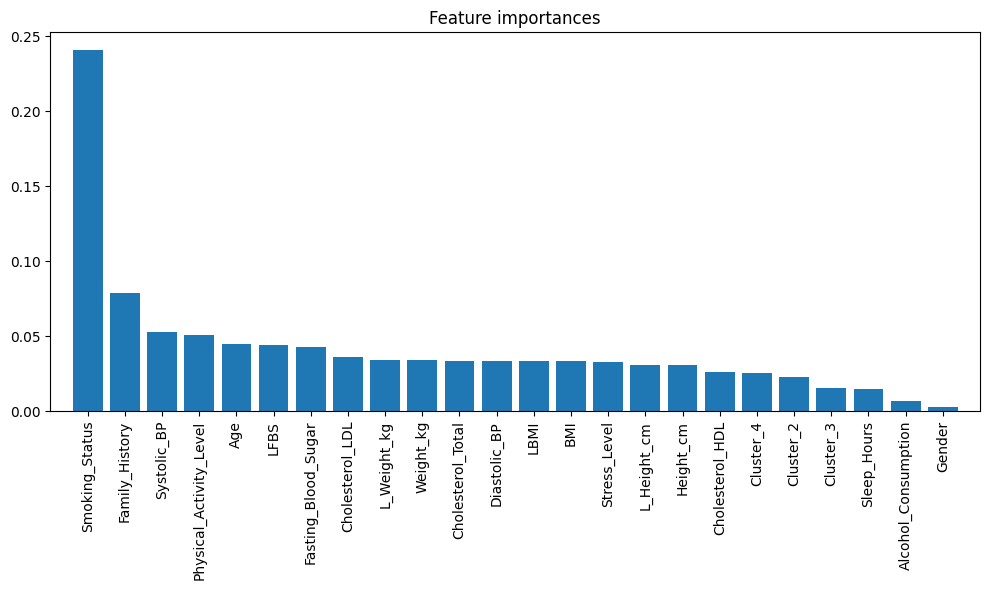

In [72]:
#random forest variables importance matrix
importances = rf_best.feature_importances_
feature_names = X_heart.columns
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_heart.shape[1]):
    print(f"{f + 1}. feature {feature_names[indices[f]]} ({importances[indices[f]]})")
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X_heart.shape[1]), importances[indices], align="center")
plt.xticks(range(X_heart.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X_heart.shape[1]])
plt.tight_layout()
plt.show()


### B. Estimation of Cholesterol LDL

In [73]:
#random forest for cholesterol LDL level

rf_reg = RandomForestRegressor(n_estimators=500, 
   criterion='squared_error', 
   max_depth=None,
   min_samples_split=2,
   min_samples_leaf=1, 
   max_leaf_nodes=None,
   bootstrap=True,
   oob_score=True)
rf_reg.fit(X_chol_train, y_chol_train)
print(f"Random Forest Regressor Score : {rf_reg.score(X_chol_test, y_chol_test)}")
param_rf_reg = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}
rf_grid_reg = GridSearchCV(RandomForestRegressor(random_state=42), param_rf_reg, cv=5, n_jobs=-1)
rf_grid_reg.fit(X_chol_train, y_chol_train)
print("Best parameters:", rf_grid_reg.best_params_)
print("Best CV MSE:", rf_grid_reg.best_score_)
rf_best_reg = RandomForestRegressor(**rf_grid_reg.best_params_, random_state=42, criterion='squared_error')
rf_best_reg.fit(X_chol_train, y_chol_train)
print(f"Optimized Random Forest Regressor Score : {rf_best_reg.score(X_chol_test, y_chol_test)}")


Random Forest Regressor Score : 0.707230756490888
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV MSE: 0.7031895140982792
Optimized Random Forest Regressor Score : 0.7086699873718039


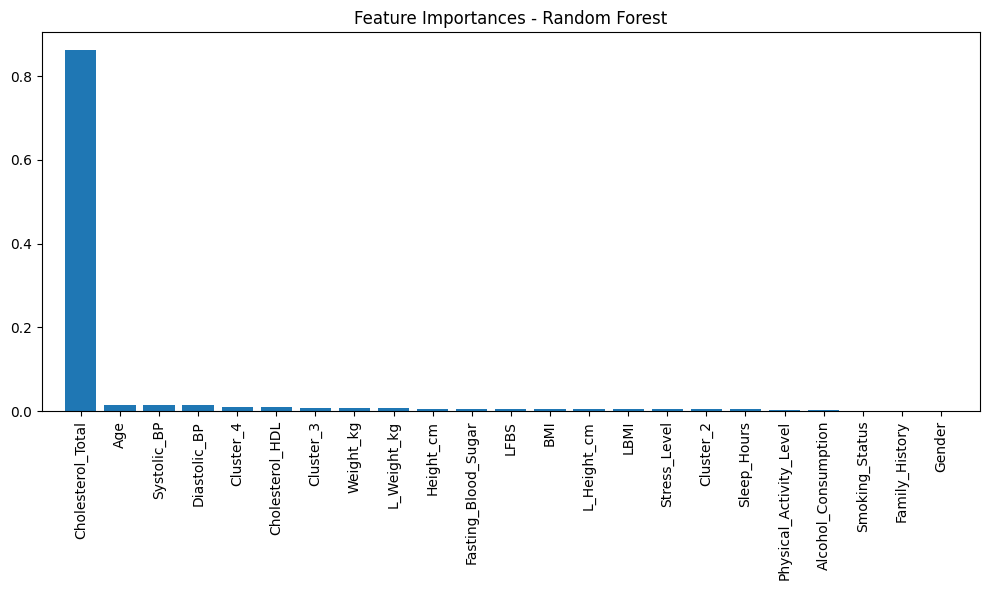

Feature ranking:
1. feature Cholesterol_Total (0.8615847488567133)
2. feature Age (0.015275474196939993)
3. feature Systolic_BP (0.014794143387116106)
4. feature Diastolic_BP (0.013863472987688051)
5. feature Cluster_4 (0.009549266017398729)
6. feature Cholesterol_HDL (0.00891952715422641)
7. feature Cluster_3 (0.006546572190489332)
8. feature Weight_kg (0.0064477754735661995)
9. feature L_Weight_kg (0.006323326533410399)
10. feature Height_cm (0.005970705661911604)
11. feature Fasting_Blood_Sugar (0.0059590330256489915)
12. feature LFBS (0.005957765971610629)
13. feature BMI (0.005908802886174833)
14. feature L_Height_cm (0.005884111467385301)
15. feature LBMI (0.005837569694781607)
16. feature Stress_Level (0.005787935583527567)
17. feature Cluster_2 (0.004395711771384764)
18. feature Sleep_Hours (0.00416847353217939)
19. feature Physical_Activity_Level (0.0026979308118572558)
20. feature Alcohol_Consumption (0.0017347049654581426)
21. feature Smoking_Status (0.0010305085079100934)
2

In [74]:
#random forest vairables importance matrix
importances = rf_best_reg.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X_chol.shape[1]), importances[indices], align="center")
plt.xticks(range(X_chol.shape[1]), X_chol.columns[indices], rotation=90)
plt.xlim([-1, X_chol.shape[1]])
plt.tight_layout()
plt.show()

#plot the value for each variable
importances = rf_best_reg.feature_importances_
print("Feature ranking:")
for f in range(X_chol.shape[1]):
    print(f"{f + 1}. feature {X_chol.columns[indices[f]]} ({importances[indices[f]]})")


We can see the same result than previously with almost only Cholesterol_Total which is used to predict the Cholesterol_LDL rate. This is consistent with the high proportionnal rate (0.83) in the confusion matrix in the variable exploration part.

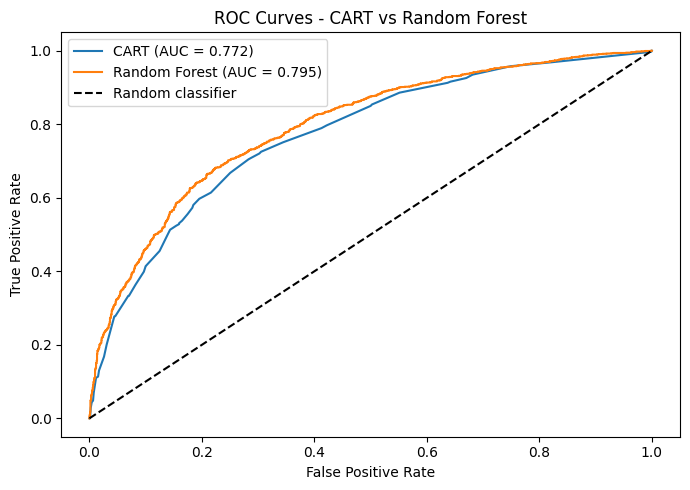

In [75]:

# get predicted probabilities for each model
# treeOpt and rf_best were fitted earlier on X_heart_train
proba_cart = treeOpt.predict_proba(X_heart_test)[:, 1]
proba_rf   = rf_best.predict_proba(X_heart_test)[:, 1]

fpr_cart, tpr_cart, _ = roc_curve(y_heart_test, proba_cart)
fpr_rf,   tpr_rf,   _ = roc_curve(y_heart_test, proba_rf)

auc_cart = roc_auc_score(y_heart_test, proba_cart)
auc_rf   = roc_auc_score(y_heart_test, proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_cart, tpr_cart, label=f"CART (AUC = {auc_cart:.3f})")
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - CART vs Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

Both models perform significantly better than a random classifier, confirming that the available features carry meaningful predictive signal for heart disease risk. The Random Forest achieves an AUC of 0.797, outperforming the CART model at 0.758. This gap is expected: by aggregating multiple trees, the Random Forest reduces variance and generalizes more reliably to unseen data. The smoother shape of its ROC curve also reflects this greater stability compared to the more erratic CART curve.

An AUC of around 0.80 means that in roughly 80% of cases, the model correctly ranks a patient with heart disease as higher risk than a healthy one. That said, the relatively small gap between CART and Random Forest (~0.04) suggests we may be approaching a performance ceiling tied to the features available in the dataset — it will be interesting to see whether boosting methods can push this further.

## 5. Boosting

We test three boosting methods for classification (Heart Disease Risk) and two for regression (Cholesterol LDL).

- **Classification**: AdaBoost, Gradient Boosting, HistGradientBoosting (sklearn equivalent of XGBoost)
- **Regression**: Gradient Boosting, HistGradientBoosting

We use cross-validation to tune the boosting's parameters for each method.

### A. Classification - Heart Disease Risk

#### Methods

We first compute the methods.

In [76]:
# AdaBoost - 5min
# n_estimators = number of weak learners, learning_rate controls the contribution of each one
param_ada = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.5]
}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), param_ada, cv=5, scoring="roc_auc", n_jobs=-1)
ada_grid.fit(X_heart_train, y_heart_train)
print("AdaBoost - Best params:", ada_grid.best_params_)
print("AdaBoost - Best CV AUC:", round(ada_grid.best_score_, 4))

AdaBoost - Best params: {'learning_rate': 0.5, 'n_estimators': 300}
AdaBoost - Best CV AUC: 0.8022


In [77]:
# Gradient Boosting - +10min
# max_depth controls tree complexity, subsample adds stochasticity (like a bagging effect)
param_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [3, 5]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb, cv=5, scoring="roc_auc", n_jobs=-1)
gb_grid.fit(X_heart_train, y_heart_train)
print("Gradient Boosting - Best params:", gb_grid.best_params_)
print("Gradient Boosting - Best CV AUC:", round(gb_grid.best_score_, 4))

Gradient Boosting - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting - Best CV AUC: 0.8009


In [78]:

# use_label_encoder=False and eval_metric to avoid deprecation warnings
# faster than GradientBoosting on large datasets, uses histogram-based splits

param_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [3, 5]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_xgb, cv=5, scoring="roc_auc", n_jobs=-1
)
xgb_grid.fit(X_heart_train, y_heart_train)
print("XGBoost - Best params:", xgb_grid.best_params_)
print("XGBoost - Best CV AUC:", round(xgb_grid.best_score_, 4))

XGBoost - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGBoost - Best CV AUC: 0.8007


#### Comparaison

In [79]:
# test set scores for each boosting method

print("Test AUC scores on held-out test set:")
for name, model in [("AdaBoost", ada_grid), ("Gradient Boosting", gb_grid), ("XGBoost", xgb_grid)]:
    proba = model.predict_proba(X_heart_test)[:, 1]
    test_auc = roc_auc_score(y_heart_test, proba)
    print(f"{name:20s}: {test_auc:.4f}")

Test AUC scores on held-out test set:
AdaBoost            : 0.8027
Gradient Boosting   : 0.8014
XGBoost             : 0.8005


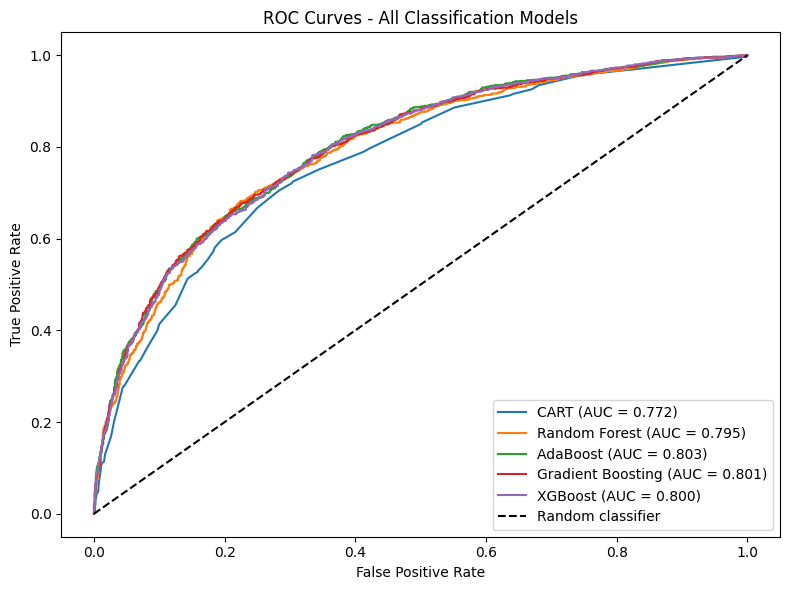

In [80]:
# ROC curves for all classification models on the same plot
# we include CART and Random Forest from earlier for easy comparison

models_classif = {
    "CART":                 treeOpt,
    "Random Forest":        rf_best,
    "AdaBoost":             ada_grid,
    "Gradient Boosting":    gb_grid,
    "XGBoost":              xgb_grid
}

plt.figure(figsize=(8, 6))
for name, model in models_classif.items():
    proba = model.predict_proba(X_heart_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_heart_test, proba)
    score = roc_auc_score(y_heart_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Classification Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The ROC curve confirms the numerical results: CART is clearly the weakest model (AUC = 0.758), sitting visibly below all other methods across the entire curve. Random Forest and all three boosting models, on the other hand, are tightly clustered together, with AUC scores between 0.797 and 0.802. This visual overlap makes it clear that once we move beyond a single decision tree, the choice of ensemble method has little impact on overall classification performance.

One interesting observation is how closely the boosting curves follow Random Forest, despite being fundamentally different approaches — bagging versus sequential boosting. All four ensemble methods converge to nearly the same curve shape, which strongly suggests that the dataset itself is the limiting factor. In a real-world medical context, this level of performance (AUC ≈ 0.80) across such different models would generally be interpreted as a reliable and robust result, rather than an artifact of any particular algorithm.

### B. Regression - Cholesterol LDL

#### Methods

AdaBoost is not appropriate for regression.

In [81]:
# Gradient Boosting Regressor
param_gb_reg = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [3, 5]
}
gb_reg_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_gb_reg, cv=5,
                           scoring="neg_mean_squared_error", n_jobs=-1)
gb_reg_grid.fit(X_chol_train, y_chol_train)
print("Gradient Boosting Regressor - Best params:", gb_reg_grid.best_params_)
print("Gradient Boosting Regressor - Best CV MSE:", round(-gb_reg_grid.best_score_, 4))

Gradient Boosting Regressor - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Gradient Boosting Regressor - Best CV MSE: 90.3969


In [82]:
# HistGradientBoosting Regressor 
param_hgb_reg = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [3, 5]
}
hgb_reg_grid = GridSearchCV(HistGradientBoostingRegressor(random_state=42), param_hgb_reg, cv=5,
                            scoring="neg_mean_squared_error", n_jobs=-1)
hgb_reg_grid.fit(X_chol_train, y_chol_train)
print("HistGradientBoosting Regressor - Best params:", hgb_reg_grid.best_params_)
print("HistGradientBoosting Regressor - Best CV MSE:", round(-hgb_reg_grid.best_score_, 4))

HistGradientBoosting Regressor - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 300}
HistGradientBoosting Regressor - Best CV MSE: 90.263


#### Comparaison

In [83]:
# test set scores for regression

print("Test MSE on held-out test set:")
for name, model in [("Gradient Boosting", gb_reg_grid), ("HistGradientBoosting", hgb_reg_grid)]:
    y_pred = model.predict(X_chol_test)
    mse = mean_squared_error(y_chol_test, y_pred)
    print(f"  {name}: MSE = {round(mse, 4)}")

Test MSE on held-out test set:
  Gradient Boosting: MSE = 85.6711
  HistGradientBoosting: MSE = 86.6187


Both boosting regressors perform very similarly, with Gradient Boosting achieving a test MSE of 96.97 and HistGradientBoosting slightly ahead at 96.64. The hyperparameters selected by cross-validation are identical for both models (learning_rate = 0.1, max_depth = 3, n_estimators/max_iter = 100), which suggests that the two methods converge to the same solution on this dataset. It is also worth noting that the test MSE is slightly lower than the cross-validation MSE for both models (~102 vs ~97), which is a good sign — the models generalize well and are not overfitting.

Compared to CART and Random Forest, it would be interesting to see whether boosting brings a meaningful improvement in MSE. Given what we observed in classification, where all ensemble methods converged to similar performance, a similar pattern would not be surprising here. An MSE of around 97 means the model's predictions deviate from the true Cholesterol LDL value by roughly 10 units on average (√97 ≈ 9.8), which is a useful metric to keep in mind when interpreting the practical significance of these results.

## 6. Neural Networks

### A. Classification

We test with only one hidden layer with few neurons (between 3 and 6) as we had seen in the TP with Ozone Data, it will be enough. We increased the maximum number of iterations.       

In [84]:
# we try different numbers of neurons in the hidden layer
param_grid_nnet = {"hidden_layer_sizes": [(3,),(4,),(5,), (6,)]}

nnet_classif = GridSearchCV(MLPClassifier(max_iter=500, random_state=42),
                            param_grid_nnet, cv=10, scoring="roc_auc", n_jobs=-1)
nnet_classif.fit(X_heart_train, y_heart_train)

print("Meilleur score CV AUC = %.4f, Meilleur paramètre = %s" % (nnet_classif.best_score_, nnet_classif.best_params_))

Meilleur score CV AUC = 0.8047, Meilleur paramètre = {'hidden_layer_sizes': (4,)}


In [85]:
# score on the test set
proba_nnet = nnet_classif.predict_proba(X_heart_test)[:, 1]
print("Neural Network - Test AUC:", round(roc_auc_score(y_heart_test, proba_nnet), 4))

Neural Network - Test AUC: 0.8044


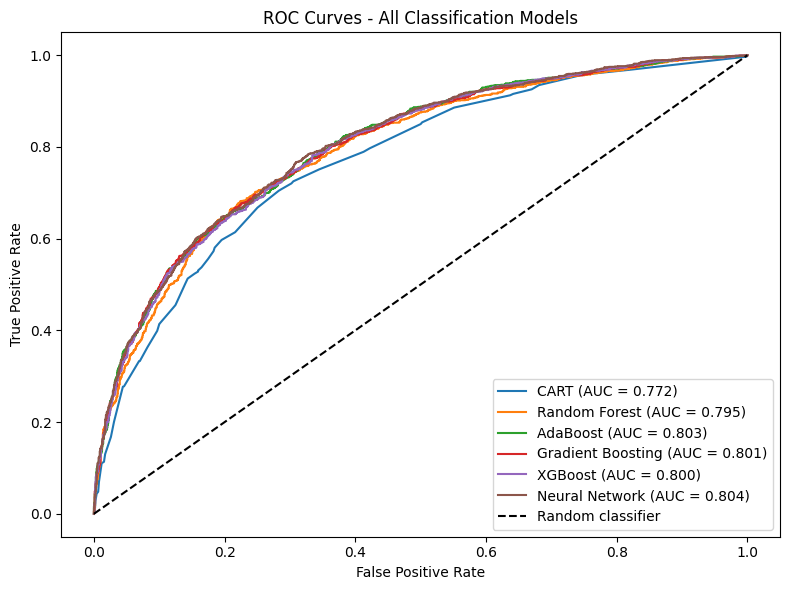

In [86]:
# ROC curve with all classification models including the neural network
models_classif = {
    "CART":                 treeOpt,
    "Random Forest":        rf_best,
    "AdaBoost":             ada_grid,
    "Gradient Boosting":    gb_grid,
    "XGBoost":              xgb_grid,
    "Neural Network":       nnet_classif
}

plt.figure(figsize=(8, 6))
for name, model in models_classif.items():
    proba = model.predict_proba(X_heart_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_heart_test, proba)
    score = roc_auc_score(y_heart_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Classification Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The neural network achieves a test AUC of 0.804, which is the best result among all classification models tested so far, albeit by a very small margin over AdaBoost (0.802) and the other boosting methods (~0.799). The optimal architecture found by cross-validation is surprisingly small — a single hidden layer with just 3 neurons — which confirms that we are dealing with a relatively simple classification problem that does not require a complex model to capture the underlying patterns.

The fact that such a minimal network outperforms larger architectures (4, 5, 6 neurons) suggests that adding capacity does not help here, and may even introduce noise. This is consistent with the overall picture across all models: CART aside, every ensemble and neural network method converges to an AUC between 0.797 and 0.804, reinforcing the idea that the dataset's features are the main limiting factor rather than the choice of algorithm.

### B. Regression

In [87]:

param_grid_nnet_reg = {"hidden_layer_sizes": [(3,),(4,),(5,),(6,)]}

nnet_reg = GridSearchCV(MLPRegressor(max_iter=800, random_state=42),
                        param_grid_nnet_reg, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
nnet_reg.fit(X_chol_train, y_chol_train)

print("Meilleur score CV MSE = %.4f, Meilleur paramètre = %s" % (-nnet_reg.best_score_, nnet_reg.best_params_))

Meilleur score CV MSE = 87.2732, Meilleur paramètre = {'hidden_layer_sizes': (6,)}


In [88]:
# score on the test set
y_pred_nnet = nnet_reg.predict(X_chol_test)
mse_nnet = mean_squared_error(y_chol_test, y_pred_nnet)
print(f"Neural Network - Test MSE: {round(mse_nnet, 4)}")

Neural Network - Test MSE: 83.393


With only a 92.80 MSE score on the test set, the neural network performs worse than the others methods.
It's maybe overfitting to fastly the training data set and not generalizing well to the test set. Because it's an expensive method with low explicability, it may not be a good choice for this problem.

### Conclusion

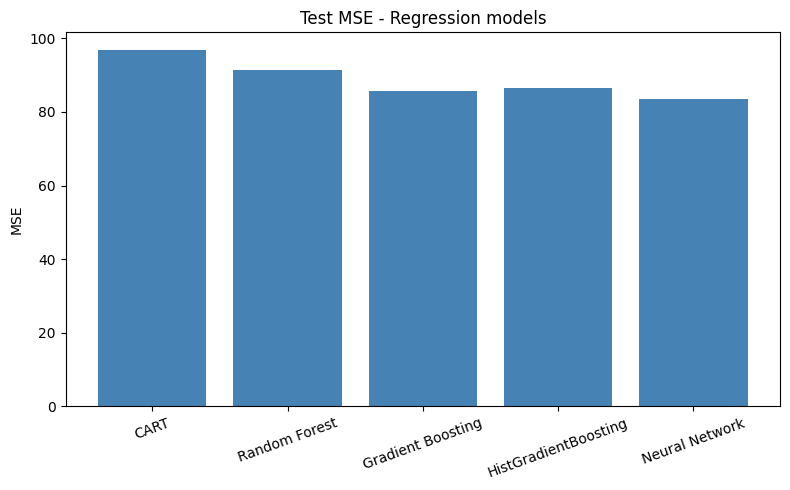

In [89]:
# bar chart MSE for all regression 
models_reg = {
    "CART":                 treeOpt_reg,
    "Random Forest":        rf_best_reg,
    "Gradient Boosting":    gb_reg_grid,
    "HistGradientBoosting": hgb_reg_grid,
    "Neural Network":       nnet_reg
}

mse_scores = {}
for name, model in models_reg.items():
    y_pred = model.predict(X_chol_test)
    mse_scores[name] = mean_squared_error(y_chol_test, y_pred)

plt.figure(figsize=(8, 5))
plt.bar(mse_scores.keys(), mse_scores.values(), color='steelblue')
plt.title("Test MSE - Regression models")
plt.ylabel("MSE")
plt.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [90]:
# regression - MSE on the test set for all regression models in a table
results_reg = {}
for name, model in models_reg.items():
    y_pred = model.predict(X_chol_test)
    results_reg[name] = round(mean_squared_error(y_chol_test, y_pred), 4)

df_reg = pd.DataFrame(results_reg.items(), columns=["Model", "Test MSE"])
df_reg = df_reg.sort_values("Test MSE", ascending=True).reset_index(drop=True)
print("Regression - Cholesterol LDL")
print(df_reg.to_string(index=False))

Regression - Cholesterol LDL
               Model  Test MSE
      Neural Network   83.3930
   Gradient Boosting   85.6711
HistGradientBoosting   86.6187
       Random Forest   91.2803
                CART   96.7836


In [99]:
def _clf(y_test, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        "Accuracy":    accuracy_score(y_test, y_pred),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "AUC":         roc_auc_score(y_test, y_proba)
    }

def _reg(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    return {
        "MSE":  mse,
        "RMSE": sqrt(mse),
        "MAE":  mean_absolute_error(y_test, y_pred),
        "R²":   r2_score(y_test, y_pred)
    }

# CART — Complete Tree
y_pred_cart_full = tree_full.predict(X_heart_test)
y_proba_cart_full = tree_full.predict_proba(X_heart_test)[:, 1]
y_pred_cart_full_reg = tree_reg.predict(X_chol_test)

update_detailed_results_table(
    model="CART", subsection="Complete Tree",
    classification_metrics=_clf(y_heart_test, y_pred_cart_full, y_proba_cart_full),
    regression_metrics=_reg(y_chol_test, y_pred_cart_full_reg),
    num_variables=X_heart.shape[1],
    explicability="Medium"
)

# CART — Optimized Tree
y_pred_cart_opt = treeOpt.predict(X_heart_test)
y_proba_cart_opt = treeOpt.predict_proba(X_heart_test)[:, 1]
y_pred_cart_opt_reg = treeOpt_reg.predict(X_chol_test)

update_detailed_results_table(
    model="CART", subsection="Optimized Tree",
    classification_metrics=_clf(y_heart_test, y_pred_cart_opt, y_proba_cart_opt),
    regression_metrics=_reg(y_chol_test, y_pred_cart_opt_reg),
    num_variables=X_heart.shape[1],
    explicability="High"
)

# Random Forest — Default RF
y_pred_rf_default = rf.predict(X_heart_test)
y_proba_rf_default = rf.predict_proba(X_heart_test)[:, 1]
y_pred_rf_default_reg = rf_reg.predict(X_chol_test)

update_detailed_results_table(
    model="Random Forest", subsection="Default RF",
    classification_metrics=_clf(y_heart_test, y_pred_rf_default, y_proba_rf_default),
    regression_metrics=_reg(y_chol_test, y_pred_rf_default_reg),
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Random Forest — Optimized RF
y_pred_rf_best = rf_best.predict(X_heart_test)
y_proba_rf_best = rf_best.predict_proba(X_heart_test)[:, 1]
y_pred_rf_best_reg = rf_best_reg.predict(X_chol_test)

update_detailed_results_table(
    model="Random Forest", subsection="Optimized RF",
    classification_metrics=_clf(y_heart_test, y_pred_rf_best, y_proba_rf_best),
    regression_metrics=_reg(y_chol_test, y_pred_rf_best_reg),
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Boosting — AdaBoost (classification only)
y_pred_ada = ada_grid.predict(X_heart_test)
y_proba_ada = ada_grid.predict_proba(X_heart_test)[:, 1]

update_detailed_results_table(
    model="Boosting", subsection="AdaBoost",
    classification_metrics=_clf(y_heart_test, y_pred_ada, y_proba_ada),
    regression_metrics=None,
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Boosting — Gradient Boosting (classification + regression)
y_pred_gb = gb_grid.predict(X_heart_test)
y_proba_gb = gb_grid.predict_proba(X_heart_test)[:, 1]
y_pred_gb_reg = gb_reg_grid.predict(X_chol_test)

update_detailed_results_table(
    model="Boosting", subsection="Gradient Boosting",
    classification_metrics=_clf(y_heart_test, y_pred_gb, y_proba_gb),
    regression_metrics=_reg(y_chol_test, y_pred_gb_reg),
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Boosting — XGBoost (classification only)
y_pred_xgb = xgb_grid.predict(X_heart_test)
y_proba_xgb = xgb_grid.predict_proba(X_heart_test)[:, 1]

update_detailed_results_table(
    model="Boosting", subsection="XGBoost",
    classification_metrics=_clf(y_heart_test, y_pred_xgb, y_proba_xgb),
    regression_metrics=None,
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Boosting — HistGradientBoosting (regression only)
y_pred_hgb_reg = hgb_reg_grid.predict(X_chol_test)

update_detailed_results_table(
    model="Boosting", subsection="HistGradientBoosting",
    classification_metrics=None,
    regression_metrics=_reg(y_chol_test, y_pred_hgb_reg),
    num_variables=X_chol.shape[1],
    explicability="Low"
)

# Neural Network — Classification MLP
y_pred_nnet = nnet_classif.predict(X_heart_test)
y_proba_nnet = nnet_classif.predict_proba(X_heart_test)[:, 1]

update_detailed_results_table(
    model="Neural Network", subsection="Classification MLP",
    classification_metrics=_clf(y_heart_test, y_pred_nnet, y_proba_nnet),
    regression_metrics=None,
    num_variables=X_heart.shape[1],
    explicability="Low"
)

# Neural Network — Regression MLP
y_pred_nnet_reg = nnet_reg.predict(X_chol_test)

update_detailed_results_table(
    model="Neural Network", subsection="Regression MLP",
    classification_metrics=None,
    regression_metrics=_reg(y_chol_test, y_pred_nnet_reg),
    num_variables=X_chol.shape[1],
    explicability="Low"
)

display_detailed_results_table()

# CONCLUSION

Through this project, we have tested more than 23 different predictive models to forecast the risk of heart disease and cholesterol level. We have optimzed each of this methods using hyperparameter tuning and then compared them with a wide range of metrics. Each method has its own specificities, qualities and drawbacks, more adapted to a certian type of real world application.

**HEART DISEASE RISK**

Heart disease risk forecasting was a classification problem, as we had to predict if the patient was in risk or not. To measure the effectiveness of our binary classification methods, we started by using the accuracy, which corresponds to the proportion of correct classifications. We observe that all the methods we tested are overal right 72% of the times, with a very similar accuracy for all of them, except for the Complete Tree that is around 64%. 

Eventhough our models obtain a high accuracy, the missclassifications might not be homogeneously split between False Positive and False Negatives. It is very important to study the sensitivity and specificity of our models. In the context of our study, we want to avoid at all costs telling a sick patient he is healthy, as it might compromise their life. Therefore we will give a significant importance to having a high sensitivity. The highest value of this metric is found for the Kbest method, an improvement of the regular SVC, with 0.7. However in some situations, it is also important to consider the specificity, notably when the treatment is very costly and a hopsital only wants to determine a low amoung of patients in risk, therefore minimizing the amount of False positives, 

However, this does not take into account the quantity of healthy and sick patients we have in our dataset. If we have more healthy patients, this might biais our model to predict wrongly more patients not in risk. To fight against this imbalance, we introduce the AUC metric that measures how well the model separates risk/no-risk patients across all thresholds, by calculating the surface under the ROC curve. We find a maximal AUC for




**CHOLESTEROL LEVEL**


